<a href="https://colab.research.google.com/github/mindioanni/LandLevelTools/blob/main/Adjust_Tide_Gauge_Datum_Network_V1_20260315.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tide Gauge Datum Network Adjustment & Visualization (Colab)

## A) Credits

### 1. Conceptualization / Author / Developer (User)
**Ioannis Mintourakis**

Postdoctoral Researcher in Sea Level / Geodesy  
Hellenic National Tsunami Warning Centre (HL-NTWC)  
Institute of Geodynamics, National Observatory of Athens, Greece

### 2. Author / Developer (Assistant)
**R**

OpenAI assistant used as technical co-developer for notebook design, code drafting, debugging, and documentation support.

## B) Purpose

This notebook performs the preparation, quality control, adjustment, and visualization of a local tide-gauge datum network. It is designed to support:

- ingestion of leveling observations from Excel field files,
- normalization and checking of raw observations,
- computation of height differences from slope distance, zenith angle, instrument height, and target height,
- internal quality control of directed edges and reciprocal height loops,
- weighted least-squares adjustment of the vertical network,
- optional introduction of external absolute-height and extra ΔH constraints,
- optional construction of an RLR-style diagram referenced to MSL,
- optional 2D horizontal network adjustment,
- optional georeferencing of the adjusted 2D network,
- optional plotting of selected georeferenced points on high-resolution satellite imagery.

## C) Quick start

Run the cells sequentially from top to bottom.

### Main vertical workflow
1. Install the required packages.
2. Search and load the input Excel workbook from Google Drive.
3. Normalize the raw observation table.
4. Compute vertical component and height differences.
5. Review network coverage.
6. Perform internal QC on directed edges and reciprocal pairs.
7. Run the weighted height adjustment.
8. Enter any external anchors and extra ΔH constraints, if available.
9. Produce the RLR-style diagram, if needed.

### Optional 2D workflow
After the vertical solution is complete, continue with the optional 2D cells to:
- derive horizontal observables,
- define the stochastic model,
- compute approximate coordinates,
- adjust the 2D network,
- estimate point precision and error ellipses,
- georeference the local network,
- plot selected points on satellite imagery.

## D) Main inputs

Typical inputs used by this notebook are:
- one Excel workbook with leveling / total-station observations,
- user-defined instrument accuracy parameters for the 2D stochastic model,
- optional absolute-height anchors and additional ΔH constraints,
- optional MSL-related information for the RLR-style diagram,
- optional Google Map Tiles API key for the final satellite-background map.

## E) Main outputs

The notebook produces, depending on the executed cells:
- standardized observation tables,
- QC tables and flagged-observation summaries,
- adjusted benchmark heights,
- optional externally constrained solutions,
- optional RLR-style diagram,
- optional adjusted 2D coordinates,
- optional point-precision and error-ellipse products,
- optional georeferenced point tables and satellite-background maps.


## Notebook setup — package installation (Basemap)

This cell contains the package installation command for **Basemap** and its high-resolution data package.

**Main role**
- installs `basemap`,
- installs `basemap-data-hires`.

**Use**
Run this cell only if Basemap-based plotting is required in the notebook environment.

In [ ]:
# %pip install basemap basemap-data-hires

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.5/30.5 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.8 MB/s eta 0:00:00
  Attempting uninstall: pyshp
    Found existing installation: pyshp 3.0.3
    Uninstalling pyshp-3.0.3:
      Successfully uninstalled pyshp-3.0.3
  Attempting uninstall: packaging
    Found existing installation: packaging 26.0
    Uninstalling packaging-26.0:
      Successfully uninstalled packaging-26.0


## Notebook setup — Basemap import check

This cell is a placeholder for the Basemap import statement.

**Main role**
- documents the intended Basemap import,
- can be activated if Basemap functionality is needed later.

In [ ]:
# from mpl_toolkits.basemap import Basemap

## Notebook setup — package installation (contextily)

This cell installs the `contextily` package used for web-tile background maps.

**Main role**
- enables use of XYZ tile providers,
- supports the final georeferenced point plotting on satellite imagery.

In [ ]:
!pip install contextily

## CELL 1 — Search Drive tree and configure workbook input

This cell mounts Google Drive, searches recursively for Excel workbooks, and lets the user select the input file and configuration fields.

**Main role**
- mount Google Drive,
- search for `.xlsx` files under a selected root folder,
- optionally filter matches by keyword,
- choose the workbook and relevant worksheet/column configuration,
- prepare the raw input table for the next processing steps.

In [ ]:
# === Search Drive Tree for XLSX & Configure Input ===
# Name: search_xlsx_and_configure
# Description:
# - Mount Google Drive
# - Recursively search for .xlsx under a root folder (whole tree)
# - Display matches as relative paths (distinguish duplicate filenames)
# - Optional keyword filter (e.g., ASTY)
# - Select file -> load sheet -> choose HI column -> record observation date knowledge

from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd

def _normalize_colname(c: str) -> str:
    return " ".join(str(c).strip().split())

def find_xlsx_files(root_dir: str) -> list[str]:
    """Return sorted list of full paths to .xlsx files under root_dir (recursive)."""
    out = []
    for dirpath, _, filenames in os.walk(root_dir):
        for fn in filenames:
            if fn.lower().endswith(".xlsx"):
                out.append(os.path.join(dirpath, fn))
    out.sort(key=lambda p: p.lower())
    return out

# 1) Root for recursive search
root_dir = input(
    "\nEnter root folder to search recursively\n"
    "If uncertain provide: /content/drive/MyDrive\n> "
).strip()

if not os.path.isdir(root_dir):
    raise FileNotFoundError(f"Folder not found: {root_dir}")

print("\nSearching... (this may take time if root is large)")
all_xlsx = find_xlsx_files(root_dir)
print(f"Found {len(all_xlsx)} .xlsx files under: {root_dir}")

# 2) Optional keyword filtering
kw = input("\nOptional filter keyword (e.g., ASTY). Press Enter to skip: ").strip()
if kw:
    kw_low = kw.lower()
    filtered = [p for p in all_xlsx if kw_low in os.path.relpath(p, root_dir).lower()]
    print(f"Filtered to {len(filtered)} files containing '{kw}'.")
else:
    filtered = all_xlsx

if len(filtered) == 0:
    raise RuntimeError("No .xlsx files found after filtering.")

# 3) Display a selectable list (relative paths for disambiguation)
max_show = 200
print("\nAvailable XLSX files (showing up to first 200):")
for i, p in enumerate(filtered[:max_show], start=1):
    rel = os.path.relpath(p, root_dir)
    print(f"  [{i:03d}] {rel}")

if len(filtered) > max_show:
    print(f"\nNote: {len(filtered)} files total. Refine with a keyword to reduce the list.")

sel = input("\nSelect file number from the list above: ").strip()
idx = int(sel) - 1
if idx < 0 or idx >= len(filtered[:max_show]):
    raise ValueError("Selection out of range for the displayed list. Refine filter or increase max_show in code.")

xlsx_path = filtered[idx]
print("\nSelected XLSX path:", xlsx_path)

# 4) Load workbook and select sheet
xls = pd.ExcelFile(xlsx_path)
sheets = xls.sheet_names

print("\nWorksheets found:")
for i, s in enumerate(sheets, start=1):
    print(f"  [{i}] {s}")

sheet_idx = input("\nSelect worksheet number (press Enter for 1): ").strip()
sheet_name = sheets[0] if sheet_idx == "" else sheets[int(sheet_idx) - 1]
print(f"\nSelected worksheet: {sheet_name}")

df_raw = pd.read_excel(xlsx_path, sheet_name=sheet_name)
df_raw.columns = [_normalize_colname(c) for c in df_raw.columns]

print(f"\nLoaded rows: {len(df_raw)}")
print(f"Loaded columns: {len(df_raw.columns)}")

# 5) Choose instrument height column (HI)
candidates_hi = []
for c in df_raw.columns:
    cu = c.upper()
    if ("INSTRUMENT HEIGHT" in cu) or ("CORRECTED" in cu and "HEIGHT" in cu) or (cu in ["HI", "H.I.", "H_I"]):
        candidates_hi.append(c)

print("\nInstrument height column candidates:")
if len(candidates_hi) == 0:
    print("  (none detected)")
    hi_col = input("Type the exact column name to use for instrument height (HI): ").strip()
    if hi_col not in df_raw.columns:
        raise ValueError(f"Column not found: {hi_col}")
elif len(candidates_hi) == 1:
    hi_col = candidates_hi[0]
    print(f"  Using: {hi_col}")
else:
    for i, c in enumerate(candidates_hi, start=1):
        print(f"  [{i}] {c}")
    sel_hi = input("Select which column to use for instrument height (HI): ").strip()
    hi_col = candidates_hi[int(sel_hi) - 1]

# 6) Ask if user knows observation date
knows_date = input("\nDo you know the observation date for this file? (y/n): ").strip().lower()
if knows_date not in ["y", "n"]:
    raise ValueError("Please answer with 'y' or 'n'.")

obs_date_str = None
if knows_date == "y":
    obs_date_str = input("Enter date as YYYY-MM-DD (e.g., 2025-10-27): ").strip()

# 7) Save configuration for next cells
config = {
    "xlsx_path": xlsx_path,
    "sheet_name": sheet_name,
    "hi_col": hi_col,
    "knows_date": (knows_date == "y"),
    "obs_date_str": obs_date_str,
    "search_root": root_dir,
    "filter_keyword": kw if kw else None,
}

print("\nConfiguration saved in variable: config")
print(config)
print("\nDataFrame saved in variable: df_raw")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Enter root folder to search recursively
If uncertain provide: /content/drive/MyDrive
> /content/drive/MyDrive

Searching... (this may take time if root is large)
Found 30 .xlsx files under: /content/drive/MyDrive

Optional filter keyword (e.g., ASTY). Press Enter to skip: ASTY
Filtered to 7 files containing 'ASTY'.

Available XLSX files (showing up to first 200):
  [001] ΕΡΕΥΝΑ/Γεωδυναμικό Ινστιτούτο/EPOS TCS TSU/ΔΕΔΟΜΕΝΑ ΠΕΔΙΟΥ/ASTY/ASTYPALAIA DATA.xlsx
  [002] ΕΡΕΥΝΑ/Γεωδυναμικό Ινστιτούτο/EPOS TCS TSU/ΔΕΔΟΜΕΝΑ ΠΕΔΙΟΥ/ASTY/ASTYPALAIA DATA_EDITED.xlsx
  [003] ΕΡΕΥΝΑ/Γεωδυναμικό Ινστιτούτο/EPOS TCS TSU/ΔΕΔΟΜΕΝΑ ΠΕΔΙΟΥ/ASTY/EpilisimeTaximetria/Project1891.xlsx
  [004] ΕΡΕΥΝΑ/Γεωδυναμικό Ινστιτούτο/EPOS TCS TSU/ΔΕΔΟΜΕΝΑ ΠΕΔΙΟΥ/ASTY/PYTHON PROGRAM/Reciprocal.xlsx
  [005] ΕΡΕΥΝΑ/Γεωδυναμικό Ινστιτούτο/EPOS TCS TSU/ΔΕΔΟΜΕΝΑ ΠΕΔΙΟΥ/ASTY/PYTHON PROGRAM/Re

## CELL 2 — Normalize observations table

This cell converts the raw observation worksheet into a standardized internal observation table.

**Main role**
- parse benchmark names and observation attributes,
- standardize column naming and field content,
- parse numeric values and face information,
- construct observation datetimes when possible,
- create the normalized dataframe `obs` for subsequent computations.

In [ ]:
# === Normalize Observations Table ===
# Name: normalize_observations_table
# Description:
# - Build a standardized observation DataFrame `obs` from `df_raw` using `config`
# - Parse numeric fields and Face (I/II)
# - Build datetime (from Date/Time columns if present, otherwise from user-provided obs_date_str)
# - Flag invalid rows (missing critical fields) and report counts

import numpy as np
import pandas as pd

# ---------- Helpers ----------
def parse_float(x):
    """Parse floats from numbers or strings like '223.4311 gon' or '-'."""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    s = str(x).strip()
    if s in ["", "-", "—", "–", "nan", "NaN", "None"]:
        return np.nan
    # keep first numeric token
    s = s.replace(",", ".")
    token = s.split()[0]
    try:
        return float(token)
    except Exception:
        # fallback: extract numeric pattern
        import re
        m = re.search(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", s)
        return float(m.group(0)) if m else np.nan

def parse_face(x):
    if pd.isna(x):
        return None
    s = str(x).strip().upper()
    if s in ["I", "1", "F1", "FACE I", "FACEI", "FI"]:
        return "I"
    if s in ["II", "2", "F2", "FACE II", "FACEII", "FII"]:
        return "II"
    return None

def find_col(df, candidates):
    """Return first matching column in df for a list of candidate names."""
    cols = set(df.columns)
    for c in candidates:
        if c in cols:
            return c
    return None

# ---------- Required column mapping (best-effort) ----------
col_from = find_col(df_raw, ["From Station", "From", "Station", "Station Name", "Setup Station"])
col_to   = find_col(df_raw, ["To", "Target", "To Station", "Point", "Sight To"])
col_face = find_col(df_raw, ["Face", "FACE"])
col_v    = find_col(df_raw, ["V [gon]", "V(gon)", "V", "Zenith [gon]", "Zenith", "Z [gon]"])
col_sd   = find_col(df_raw, ["Slope Dist. [m]", "Slope Dist [m]", "Slope Distance [m]", "Slope [m]", "SD [m]"])
col_ht   = find_col(df_raw, ["Target Height [m]", "Target Height", "HT [m]", "Prism Height [m]", "Reflector Height [m]"])

# Date/time (optional)
col_date = find_col(df_raw, ["Date", "DATE"])
col_time = find_col(df_raw, ["Time", "TIME", "Start Time"])

missing = []
for name, col in [("From Station", col_from), ("To", col_to), ("Face", col_face),
                  ("V [gon]", col_v), ("Slope Dist. [m]", col_sd), ("Target Height [m]", col_ht)]:
    if col is None:
        missing.append(name)

if missing:
    raise ValueError(f"Missing required columns (not found by auto-detection): {missing}\n"
                     f"Available columns: {list(df_raw.columns)}")

hi_col = config["hi_col"]
if hi_col not in df_raw.columns:
    raise ValueError(f"HI column from config not found in df_raw: {hi_col}")

# ---------- Build obs ----------
obs = pd.DataFrame()
obs["from"] = df_raw[col_from].astype(str).str.strip()
obs["to"]   = df_raw[col_to].astype(str).str.strip()
obs["face"] = df_raw[col_face].apply(parse_face)

obs["V_gon"] = df_raw[col_v].apply(parse_float)
obs["slope_m"] = df_raw[col_sd].apply(parse_float)
obs["HI_m"] = df_raw[hi_col].apply(parse_float)
obs["HT_m"] = df_raw[col_ht].apply(parse_float)

# ---------- Datetime handling ----------
# If Date & Time exist -> combine; else use user-provided obs_date_str; else NaT.
if col_date is not None and col_time is not None:
    # robust combine; keep as string then to_datetime
    dt_str = df_raw[col_date].astype(str).str.strip() + " " + df_raw[col_time].astype(str).str.strip()
    obs["datetime"] = pd.to_datetime(dt_str, errors="coerce", dayfirst=False)
elif config.get("knows_date", False) and config.get("obs_date_str"):
    # store date only; time unknown
    obs["datetime"] = pd.to_datetime(config["obs_date_str"], errors="coerce")
else:
    obs["datetime"] = pd.NaT

# ---------- Validity flags ----------
# Critical fields for next steps
crit = ["from", "to", "face", "V_gon", "slope_m", "HI_m", "HT_m"]
valid = np.ones(len(obs), dtype=bool)

# Missing from/to
valid &= obs["from"].notna() & (obs["from"].str.len() > 0)
valid &= obs["to"].notna() & (obs["to"].str.len() > 0)

# Face must be I or II
valid &= obs["face"].isin(["I", "II"])

# Numeric fields not NaN
for c in ["V_gon", "slope_m", "HI_m", "HT_m"]:
    valid &= np.isfinite(obs[c].values)

obs["is_valid"] = valid

# ---------- Report ----------
n_total = len(obs)
n_valid = int(obs["is_valid"].sum())
n_invalid = n_total - n_valid

print(f"Total rows:   {n_total}")
print(f"Valid rows:   {n_valid}")
print(f"Invalid rows: {n_invalid}")

if n_invalid > 0:
    # simple diagnostics
    reasons = {
        "missing/empty from": ~(obs["from"].notna() & (obs["from"].str.len() > 0)),
        "missing/empty to":   ~(obs["to"].notna() & (obs["to"].str.len() > 0)),
        "invalid face":       ~obs["face"].isin(["I", "II"]),
        "V_gon NaN":          ~np.isfinite(obs["V_gon"].values),
        "slope_m NaN":        ~np.isfinite(obs["slope_m"].values),
        "HI_m NaN":           ~np.isfinite(obs["HI_m"].values),
        "HT_m NaN":           ~np.isfinite(obs["HT_m"].values),
    }
    print("\nInvalid-row reasons (counts):")
    for k, m in reasons.items():
        print(f" - {k}: {int(m.sum())}")

# Keep only valid observations for downstream processing
obs = obs.loc[obs["is_valid"]].copy()

# Standard sorting for reproducibility
if obs["datetime"].notna().any():
    obs = obs.sort_values(["datetime", "from", "to", "face"]).reset_index(drop=True)
else:
    obs = obs.sort_values(["from", "to", "face"]).reset_index(drop=True)

print("\nSaved standardized observations in DataFrame: obs")
print("Columns:", list(obs.columns))
obs.head(10)


Total rows:   278
Valid rows:   278
Invalid rows: 0

Saved standardized observations in DataFrame: obs
Columns: ['from', 'to', 'face', 'V_gon', 'slope_m', 'HI_m', 'HT_m', 'datetime', 'is_valid']


,from,to,face,V_gon,slope_m,HI_m,HT_m,datetime,is_valid
0,R1,R2,I,108.0436,21.6415,1.51896,0.1,2026-01-19,True
1,R1,R2,I,108.0442,21.6415,1.51896,0.1,2026-01-19,True
2,R1,R2,I,108.0444,21.6408,1.51896,0.1,2026-01-19,True
3,R1,R2,I,108.0454,21.6420,1.51896,0.1,2026-01-19,True
4,R1,R2,I,108.0438,21.6422,1.51896,0.1,2026-01-19,True
5,R1,R2,I,108.0437,21.6422,1.51896,0.1,2026-01-19,True
6,R1,R2,I,108.0440,21.6420,1.51896,0.1,2026-01-19,True
7,R1,R2,I,108.0447,21.6421,1.51896,0.1,2026-01-19,True
8,R1,R2,I,108.0442,21.6421,1.51896,0.1,2026-01-19,True
9,R1,R2,I,108.0440,21.6422,1.51896,0.1,2026-01-19,True


## CELL 3 — Compute vertical component and height difference

This cell computes the vertical projection of slope distance and derives the observed height difference for each record.

**Main role**
- convert zenith angle from gon to radians,
- compute vertical component from slope distance,
- compute `dH_C_m`,
- compare computed values with any corresponding values already present in the workbook, when available.

In [ ]:
# === Compute Vertical Component & Height Difference ===
# Name: compute_vdist_and_dh
# Description:
# - Compute V_distC_m = d * cos(Z) where Z is zenith angle in radians (V_gon assumed zenith)
# - Compute dH_C_m = HI - HT + V_distC_m
# - If df_raw contains "V Dist. [m]" and/or "ΔHeight [m]" (or similar), compare and report stats

import numpy as np
import pandas as pd

# --- Assumption check (explicit): V_gon is zenith angle Z in gon ---
# Z [gon] -> radians: Z_rad = Z_gon * (pi/200)
GON_TO_RAD = np.pi / 200.0

# Compute vertical component (+ up if Z < 100 gon, - down if Z > 100 gon)
obs["Z_rad"] = obs["V_gon"].values * GON_TO_RAD
obs["V_distC_m"] = obs["slope_m"].values * np.cos(obs["Z_rad"].values)

# Height difference from S1 (from) to S2 (to): H_to - H_from
obs["dH_C_m"] = obs["HI_m"].values - obs["HT_m"].values + obs["V_distC_m"].values

# --- Optional comparison to raw-file columns (if exist) ---
def find_col(df, candidates):
    cols = set(df.columns)
    for c in candidates:
        if c in cols:
            return c
    return None

def parse_float(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    s = str(x).strip()
    if s in ["", "-", "—", "–", "nan", "NaN", "None"]:
        return np.nan
    s = s.replace(",", ".")
    token = s.split()[0]
    try:
        return float(token)
    except Exception:
        import re
        m = re.search(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", s)
        return float(m.group(0)) if m else np.nan

col_vdist_raw = find_col(df_raw, ["V Dist. [m]", "V Dist [m]", "V Dist", "V Distance [m]", "Vertical Dist. [m]"])
col_dh_raw    = find_col(df_raw, ["ΔHeight [m]", "dHeight [m]", "Delta Height [m]", "DeltaHeight [m]", "Dh [m]"])

# Build raw vectors aligned by row index (obs was built from df_raw row order and then sorted;
# so we compare only if obs is not re-ordered by datetime with identical date only. We will compare via a safe merge key.)
# Since your datetime is constant (date-only), sorting may have changed order. We'll compare by (from,to,face,V_gon,slope,HI,HT) key.

compare_report = {}

if col_vdist_raw is not None or col_dh_raw is not None:
    # create a key in both frames
    tmp_raw = df_raw.copy()
    tmp_raw["_from"] = tmp_raw[find_col(df_raw, ["From Station"])].astype(str).str.strip()
    tmp_raw["_to"]   = tmp_raw[find_col(df_raw, ["To"])].astype(str).str.strip()
    tmp_raw["_face"] = tmp_raw[find_col(df_raw, ["Face"])].astype(str).str.strip().str.upper()
    tmp_raw["_V_gon"] = tmp_raw[find_col(df_raw, ["V [gon]"])].apply(parse_float)
    tmp_raw["_slope_m"] = tmp_raw[find_col(df_raw, ["Slope Dist. [m]"])].apply(parse_float)
    tmp_raw["_HI_m"] = tmp_raw[config["hi_col"]].apply(parse_float)
    tmp_raw["_HT_m"] = tmp_raw[find_col(df_raw, ["Target Height [m]"])].apply(parse_float)

    # keep only fields needed
    raw_key_cols = ["_from","_to","_face","_V_gon","_slope_m","_HI_m","_HT_m"]
    raw_cmp = tmp_raw[raw_key_cols].copy()
    if col_vdist_raw is not None:
        raw_cmp["V_dist_raw_m"] = tmp_raw[col_vdist_raw].apply(parse_float)
    if col_dh_raw is not None:
        raw_cmp["dH_raw_m"] = tmp_raw[col_dh_raw].apply(parse_float)

    obs_key = obs.copy()
    obs_key["_from"] = obs_key["from"]
    obs_key["_to"] = obs_key["to"]
    obs_key["_face"] = obs_key["face"]
    obs_key["_V_gon"] = obs_key["V_gon"]
    obs_key["_slope_m"] = obs_key["slope_m"]
    obs_key["_HI_m"] = obs_key["HI_m"]
    obs_key["_HT_m"] = obs_key["HT_m"]

    merged = obs_key.merge(raw_cmp, on=raw_key_cols, how="left")

    if col_vdist_raw is not None:
        dv = merged["V_distC_m"] - merged["V_dist_raw_m"]
        dv = dv[np.isfinite(dv)]
        if len(dv) > 0:
            compare_report["V_distC_minus_raw"] = {
                "n": int(len(dv)),
                "mean_m": float(np.mean(dv)),
                "std_m": float(np.std(dv, ddof=1)) if len(dv) > 1 else 0.0,
                "min_m": float(np.min(dv)),
                "max_m": float(np.max(dv)),
            }

    if col_dh_raw is not None:
        ddh = merged["dH_C_m"] - merged["dH_raw_m"]
        ddh = ddh[np.isfinite(ddh)]
        if len(ddh) > 0:
            compare_report["dH_C_minus_raw"] = {
                "n": int(len(ddh)),
                "mean_m": float(np.mean(ddh)),
                "std_m": float(np.std(ddh, ddof=1)) if len(ddh) > 1 else 0.0,
                "min_m": float(np.min(ddh)),
                "max_m": float(np.max(ddh)),
            }

# --- Print summary ---
print("Computed columns added to `obs`: Z_rad, V_distC_m, dH_C_m")
print("\nBasic stats:")
print(obs[["V_gon","slope_m","V_distC_m","dH_C_m"]].describe())

if compare_report:
    print("\nComparison against raw-file columns (computed - raw):")
    for k, v in compare_report.items():
        print(f"\n{k}")
        for kk, vv in v.items():
            print(f"  {kk}: {vv}")
else:
    print("\nNo raw vertical-distance / ΔHeight columns found (or no comparable matches).")

obs.head(10)


Computed columns added to `obs`: Z_rad, V_distC_m, dH_C_m

Basic stats:
            V_gon     slope_m   V_distC_m      dH_C_m
count  278.000000  278.000000  278.000000  278.000000
mean   198.620060   38.080038    0.352594    1.840347
std    100.008670   29.704203    4.437117    4.443047
min     94.011500   16.243400  -10.009752   -8.590792
25%     98.878425   17.268900   -1.885826   -0.392966
50%    108.336800   21.365350    0.304277    1.897137
75%    301.118900   76.329900    1.099783    2.518743
max    305.986700   93.232300    7.169570    8.588530

Comparison against raw-file columns (computed - raw):

V_distC_minus_raw
  n: 296
  mean_m: -0.00015775431358508733
  std_m: 0.00021298152688878502
  min_m: -0.0006914541955991282
  max_m: 3.70273867177362e-05

dH_C_minus_raw
  n: 296
  mean_m: -0.0051730921514229625
  std_m: 0.002805947537004267
  min_m: -0.009663820116535327
  max_m: -0.0030109140998895167


,from,to,face,V_gon,slope_m,HI_m,HT_m,datetime,is_valid,Z_rad,V_distC_m,dH_C_m
0,R1,R2,I,108.0436,21.6415,1.51896,0.1,2026-01-19,True,1.697145,-2.727103,-1.308143
1,R1,R2,I,108.0442,21.6415,1.51896,0.1,2026-01-19,True,1.697154,-2.727306,-1.308346
2,R1,R2,I,108.0444,21.6408,1.51896,0.1,2026-01-19,True,1.697157,-2.727285,-1.308325
3,R1,R2,I,108.0454,21.6420,1.51896,0.1,2026-01-19,True,1.697173,-2.727773,-1.308813
4,R1,R2,I,108.0438,21.6422,1.51896,0.1,2026-01-19,True,1.697148,-2.727259,-1.308299
5,R1,R2,I,108.0437,21.6422,1.51896,0.1,2026-01-19,True,1.697146,-2.727225,-1.308265
6,R1,R2,I,108.0440,21.6420,1.51896,0.1,2026-01-19,True,1.697151,-2.727301,-1.308341
7,R1,R2,I,108.0447,21.6421,1.51896,0.1,2026-01-19,True,1.697162,-2.727550,-1.308590
8,R1,R2,I,108.0442,21.6421,1.51896,0.1,2026-01-19,True,1.697154,-2.727381,-1.308421
9,R1,R2,I,108.0440,21.6422,1.51896,0.1,2026-01-19,True,1.697151,-2.727326,-1.308366


## CELL 4 — Network coverage report

This cell summarizes the observation geometry of the vertical network.

**Main role**
- identify all unique benchmarks,
- build directed and undirected edge tables,
- count observations by direction and face,
- detect reciprocal pairs,
- provide a compact overview of network connectivity.

In [ ]:
# === Network Coverage Report (Nodes & Edges) ===
# Name: network_coverage_report
# Description:
# - List unique benchmarks (nodes)
# - Build directed edge table: i->j with counts (total, Face I, Face II)
# - Build undirected edge table: {i,j} with counts
# - Identify reciprocal pairs (both directions present)
# - Provide compact coverage report tables

import pandas as pd
import numpy as np

# --- Nodes ---
nodes = sorted(set(obs["from"]).union(set(obs["to"])))
df_nodes = pd.DataFrame({"benchmark": nodes})
print(f"Benchmarks found (N={len(nodes)}): {nodes}")

# --- Directed edges with counts by face ---
edge_counts = (
    obs.groupby(["from", "to"])
       .agg(
           n_total=("dH_C_m", "size"),
           n_face_I=("face", lambda s: int((s == "I").sum())),
           n_face_II=("face", lambda s: int((s == "II").sum())),
           dH_mean=("dH_C_m", "mean"),
           dH_std=("dH_C_m", lambda s: float(np.std(s, ddof=1)) if len(s) > 1 else 0.0),
       )
       .reset_index()
       .sort_values(["from", "to"])
       .reset_index(drop=True)
)

print("\nDirected edges (from -> to):")
display(edge_counts)

# --- Undirected edges (pair key independent of direction) ---
tmp = obs.copy()
tmp["u"] = tmp[["from", "to"]].min(axis=1)
tmp["v"] = tmp[["from", "to"]].max(axis=1)

undir_counts = (
    tmp.groupby(["u", "v"])
       .agg(
           n_total=("dH_C_m", "size"),
           n_face_I=("face", lambda s: int((s == "I").sum())),
           n_face_II=("face", lambda s: int((s == "II").sum())),
       )
       .reset_index()
       .sort_values(["u", "v"])
       .reset_index(drop=True)
)

print("\nUndirected edges ({u, v}):")
display(undir_counts)

# --- Reciprocal pairs: both directions exist ---
directed_set = set(zip(edge_counts["from"], edge_counts["to"]))
recip_rows = []
for a, b in sorted({tuple(sorted([f, t])) for f, t in directed_set if f != t}):
    has_ab = (a, b) in directed_set
    has_ba = (b, a) in directed_set
    if has_ab and has_ba:
        # pull counts
        ab = edge_counts[(edge_counts["from"] == a) & (edge_counts["to"] == b)].iloc[0]
        ba = edge_counts[(edge_counts["from"] == b) & (edge_counts["to"] == a)].iloc[0]
        recip_rows.append({
            "pair": f"{a}<->{b}",
            "n_ab": int(ab["n_total"]),
            "n_ba": int(ba["n_total"]),
            "n_ab_I": int(ab["n_face_I"]),
            "n_ab_II": int(ab["n_face_II"]),
            "n_ba_I": int(ba["n_face_I"]),
            "n_ba_II": int(ba["n_face_II"]),
        })

df_recip = pd.DataFrame(recip_rows).sort_values("pair").reset_index(drop=True)

print("\nReciprocal pairs (i <-> j):")
if len(df_recip) == 0:
    print("None found.")
else:
    display(df_recip)

# Save for next cells
network = {
    "nodes": nodes,
    "edge_counts_directed": edge_counts,
    "edge_counts_undirected": undir_counts,
    "reciprocal_pairs": df_recip
}
print("\nSaved network summary in dict: network")


Benchmarks found (N=10): ['F1', 'F2', 'R1', 'R2', 'R3', 'R4', 'R5', 'T1', 'T2', 'T3']

Directed edges (from -> to):


,from,to,n_total,n_face_I,n_face_II,dH_mean,dH_std
0,R1,R2,27,13,14,-1.308544,0.000301
1,R1,R5,23,13,10,-8.589881,0.000601
2,R4,F1,12,6,6,2.155086,0.000375
3,R4,F2,12,6,6,2.130700,0.000399
4,R4,R1,22,11,11,8.198792,0.001094
5,R4,R5,25,13,12,-0.393171,0.000282
6,R4,T1,22,11,11,1.897853,0.000359
7,R4,T2,22,11,11,1.896561,0.000418
8,R4,T3,22,11,11,1.896692,0.000343
9,R5,R1,29,15,14,8.585798,0.001110



Undirected edges ({u, v}):


,u,v,n_total,n_face_I,n_face_II
0,F1,R4,12,6,6
1,F2,R4,12,6,6
2,R1,R2,27,13,14
3,R1,R4,22,11,11
4,R1,R5,52,28,24
5,R2,R5,10,5,5
6,R3,R5,26,13,13
7,R4,R5,51,26,25
8,R4,T1,22,11,11
9,R4,T2,22,11,11



Reciprocal pairs (i <-> j):


,pair,n_ab,n_ba,n_ab_I,n_ab_II,n_ba_I,n_ba_II
0,R1<->R5,23,29,13,10,15,14
1,R4<->R5,25,26,13,12,13,13



Saved network summary in dict: network


## CELL 5 — Directed-edge internal precision and QC

This cell evaluates repeatability on each directed edge and performs optional outlier flagging based on internal scatter.

**Main role**
- compute mean, standard deviation, and standard error of `dH_C_m`,
- summarize results overall and by face,
- optionally flag outliers using a `k·σ` rule,
- optionally remove flagged observations,
- generate cleaned products for later adjustment steps.

In [ ]:
# === Cell 6A — Directed-edge precision + Directed-edge QC (k·σ) ===
# Title (EN): Directed-Edge Internal Precision + QC
# Name: cell6A_directed_edge_precision_and_qc
# Description:
# - Computes Table I: directed-edge mean/std/SE for dH_C_m (overall + per face)
# - Optional QC per directed edge:
#     * mode="combined": per (from->to) using both faces together
#     * mode="per_face": per (from->to->face) using each face separately
# - Flags |dH - mean(sample)| > k*std(sample)
# - Optionally drops flagged observations -> creates obs_qc
# - Recomputes Table I on obs_qc -> edge_precision_clean
# - Saves: edge_precision, edge_precision_clean, flagged_edge_outliers, flagged_edge_summary,
#          k_used_edge_qc, qc_mode_edge_qc, obs_qc

import numpy as np
import pandas as pd

# ----------------------------
# Helpers (same behavior as original)
# ----------------------------
def _std_ddof1(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) <= 1:
        return 0.0
    return float(np.std(x, ddof=1))

def _se_from_std(std, n):
    return float(std / np.sqrt(n)) if n > 0 else np.nan

def _compute_table_I(obs_df):
    rows = []
    for (f, t), g in obs_df.groupby(["from", "to"]):
        vals_all = g["dH_C_m"].values
        n_all = len(vals_all)
        mean_all = float(np.mean(vals_all))
        std_all = _std_ddof1(vals_all)
        se_all = _se_from_std(std_all, n_all)

        gI = g[g["face"] == "I"]["dH_C_m"].values
        gII = g[g["face"] == "II"]["dH_C_m"].values

        nI, nII = len(gI), len(gII)
        meanI = float(np.mean(gI)) if nI > 0 else np.nan
        meanII = float(np.mean(gII)) if nII > 0 else np.nan
        stdI = _std_ddof1(gI) if nI > 0 else np.nan
        stdII = _std_ddof1(gII) if nII > 0 else np.nan
        seI = _se_from_std(stdI, nI) if nI > 0 else np.nan
        seII = _se_from_std(stdII, nII) if nII > 0 else np.nan

        rows.append({
            "from": f, "to": t,
            "n_all": n_all, "mean_all_m": mean_all, "std_all_m": std_all, "se_all_m": se_all,
            "n_I": nI, "mean_I_m": meanI, "std_I_m": stdI, "se_I_m": seI,
            "n_II": nII, "mean_II_m": meanII, "std_II_m": stdII, "se_II_m": seII,
            "mean_I_minus_II_m": (meanI - meanII) if (np.isfinite(meanI) and np.isfinite(meanII)) else np.nan,
        })

    return pd.DataFrame(rows).sort_values(["from", "to"]).reset_index(drop=True)

# ----------------------------
# 1) Table I on original obs (same as original cell up to this point)
# ----------------------------
edge_precision = _compute_table_I(obs)

print("Directed-edge internal precision (overall + per face):")
display(edge_precision)

# ----------------------------
# 2) Directed-edge QC (k·σ) and optional dropping -> obs_qc
# ----------------------------
print("\n--- Directed-edge QC (optional) ---", flush=True)
apply_qc = input("Apply directed-edge QC (k·σ) on dH_C_m? (y/n): ").strip().lower()
if apply_qc not in ["y", "n"]:
    raise ValueError("Please answer with 'y' or 'n'.")

k_used_edge_qc = None
qc_mode_edge_qc = None
flagged_edge_outliers = pd.DataFrame()
flagged_edge_summary = pd.DataFrame()

# Default: no change
obs_qc = obs.copy()
edge_precision_clean = edge_precision.copy()

if apply_qc == "y":
    # NEW: choose sample definition
    qc_mode_edge_qc = input(
        "QC sample for each direction: 'combined' (faces I+II together) or 'per_face' (each face separately)? "
    ).strip().lower()

    if qc_mode_edge_qc not in ["combined", "per_face"]:
        raise ValueError("Invalid choice. Use 'combined' or 'per_face'.")

    k_used_edge_qc = float(
        input("Enter k for |dH - mean(sample)| > k*std(sample) (e.g., 3): ").strip().replace(",", ".")
    )

    # Create stable row id to drop exactly those rows
    obs_work = obs.copy().reset_index().rename(columns={"index": "obs_id"})

    flag_rows = []

    # Grouping for QC
    if qc_mode_edge_qc == "combined":
        group_cols = ["from", "to"]
    else:  # per_face
        group_cols = ["from", "to", "face"]

    for gkey, g in obs_work.groupby(group_cols):
        vals = g["dH_C_m"].values.astype(float)
        mu = float(np.mean(vals))
        sig = _std_ddof1(vals)

        if sig == 0.0:
            is_out = np.zeros(len(g), dtype=bool)
        else:
            is_out = np.abs(vals - mu) > k_used_edge_qc * sig

        if np.any(is_out):
            tmp = g.loc[is_out, ["obs_id","from","to","face","datetime","V_gon","slope_m","HI_m","HT_m","dH_C_m","V_distC_m"]].copy()
            tmp["sample_mean_m"] = mu
            tmp["sample_std_m"] = sig
            tmp["residual_m"] = tmp["dH_C_m"] - mu
            tmp["k_used"] = k_used_edge_qc
            tmp["qc_mode"] = qc_mode_edge_qc
            flag_rows.append(tmp)

    flagged_edge_outliers = pd.concat(flag_rows, ignore_index=True) if flag_rows else pd.DataFrame()

    # Summary
    if len(flagged_edge_outliers) > 0:
        if qc_mode_edge_qc == "combined":
            flagged_edge_summary = (
                flagged_edge_outliers.groupby(["from","to"])
                .size()
                .reset_index(name="n_flagged")
                .sort_values(["from","to"])
                .reset_index(drop=True)
            )
        else:
            flagged_edge_summary = (
                flagged_edge_outliers.groupby(["from","to","face"])
                .size()
                .reset_index(name="n_flagged")
                .sort_values(["from","to","face"])
                .reset_index(drop=True)
            )
    else:
        # define empty summary with expected columns
        flagged_edge_summary = pd.DataFrame(
            columns=(["from","to","n_flagged"] if qc_mode_edge_qc == "combined" else ["from","to","face","n_flagged"])
        )

    print("\nFlagged outliers per sample:", flush=True)
    display(flagged_edge_summary)

    if len(flagged_edge_outliers) > 0:
        print("\nFlagged observations (first 50 rows):", flush=True)
        display(flagged_edge_outliers.head(50))
    else:
        print("\nNo observations flagged with the chosen k.", flush=True)

    drop_flagged = input("Drop flagged observations and recompute Table I? (y/n): ").strip().lower()
    if drop_flagged not in ["y", "n"]:
        raise ValueError("Please answer with 'y' or 'n'.")

    if drop_flagged == "y" and len(flagged_edge_outliers) > 0:
        drop_ids = set(flagged_edge_outliers["obs_id"].tolist())
        before = len(obs_work)
        obs_qc = obs_work[~obs_work["obs_id"].isin(drop_ids)].drop(columns=["obs_id"]).copy()
        after = len(obs_qc)
        print(f"\nDropped {before-after} rows. Remaining: {after}", flush=True)
    else:
        obs_qc = obs.copy()
        print("\nNo rows dropped. Using original obs as obs_qc.", flush=True)

    # Recompute Table I on obs_qc
    edge_precision_clean = _compute_table_I(obs_qc)
    print("\nDirected-edge internal precision (overall + per face) AFTER directed-edge QC:")
    display(edge_precision_clean)

# Save for next cell
qc_edge = {
    "edge_precision": edge_precision,                    # Table I (original)
    "edge_precision_clean": edge_precision_clean,        # Table I after QC (may equal original)
    "flagged_edge_outliers": flagged_edge_outliers,      # detailed flagged rows (if QC enabled)
    "flagged_edge_summary": flagged_edge_summary,        # counts per sample (if QC enabled)
    "k_used_edge_qc": k_used_edge_qc,                    # k used (if enabled)
    "qc_mode_edge_qc": qc_mode_edge_qc,                  # combined / per_face (if enabled)
    "obs_qc": obs_qc                                     # observations after QC (or original)
}
print("\nSaved directed-edge QC results in dict: qc_edge")
print("Key output for next cell: obs_qc")


Directed-edge internal precision (overall + per face):


,from,to,n_all,mean_all_m,std_all_m,se_all_m,n_I,mean_I_m,std_I_m,se_I_m,n_II,mean_II_m,std_II_m,se_II_m,mean_I_minus_II_m
0,R1,R2,27,-1.308544,0.000301,0.000058,13,-1.308388,0.000178,0.000049,14,-1.308689,0.000324,0.000087,0.000301
1,R1,R5,23,-8.589881,0.000601,0.000125,13,-8.589586,0.000438,0.000122,10,-8.590266,0.000580,0.000184,0.000680
2,R4,F1,12,2.155086,0.000375,0.000108,6,2.155363,0.000263,0.000108,6,2.154808,0.000234,0.000095,0.000555
3,R4,F2,12,2.130700,0.000399,0.000115,6,2.131029,0.000207,0.000085,6,2.130371,0.000217,0.000088,0.000659
4,R4,R1,22,8.198792,0.001094,0.000233,11,8.199306,0.000563,0.000170,11,8.198278,0.001271,0.000383,0.001028
5,R4,R5,25,-0.393171,0.000282,0.000056,13,-0.392964,0.000177,0.000049,12,-0.393395,0.000184,0.000053,0.000431
6,R4,T1,22,1.897853,0.000359,0.000077,11,1.898143,0.000196,0.000059,11,1.897562,0.000216,0.000065,0.000581
7,R4,T2,22,1.896561,0.000418,0.000089,11,1.896914,0.000244,0.000074,11,1.896208,0.000183,0.000055,0.000707
8,R4,T3,22,1.896692,0.000343,0.000073,11,1.896973,0.000244,0.000074,11,1.896411,0.000119,0.000036,0.000562
9,R5,R1,29,8.585798,0.001110,0.000206,15,8.586460,0.001075,0.000278,14,8.585088,0.000599,0.000160,0.001371



--- Directed-edge QC (optional) ---
Apply directed-edge QC (k·σ) on dH_C_m? (y/n): y
QC sample for each direction: 'combined' (faces I+II together) or 'per_face' (each face separately)? per_face
Enter k for |dH - mean(sample)| > k*std(sample) (e.g., 3): 3

Flagged outliers per sample:


,from,to,face,n_flagged
0,R1,R2,II,1



Flagged observations (first 50 rows):


,obs_id,from,to,face,datetime,V_gon,slope_m,HI_m,HT_m,dH_C_m,V_distC_m,sample_mean_m,sample_std_m,residual_m,k_used,qc_mode
0,15,R1,R2,II,2026-01-19,291.9526,21.6438,1.51896,0.1,-1.309715,-2.728675,-1.308689,0.000324,-0.001025,3.0,per_face


Drop flagged observations and recompute Table I? (y/n): y

Dropped 1 rows. Remaining: 277

Directed-edge internal precision (overall + per face) AFTER directed-edge QC:


,from,to,n_all,mean_all_m,std_all_m,se_all_m,n_I,mean_I_m,std_I_m,se_I_m,n_II,mean_II_m,std_II_m,se_II_m,mean_I_minus_II_m
0,R1,R2,26,-1.308499,0.000193,0.000038,13,-1.308388,0.000178,0.000049,13,-1.308610,0.000139,0.000039,0.000222
1,R1,R5,23,-8.589881,0.000601,0.000125,13,-8.589586,0.000438,0.000122,10,-8.590266,0.000580,0.000184,0.000680
2,R4,F1,12,2.155086,0.000375,0.000108,6,2.155363,0.000263,0.000108,6,2.154808,0.000234,0.000095,0.000555
3,R4,F2,12,2.130700,0.000399,0.000115,6,2.131029,0.000207,0.000085,6,2.130371,0.000217,0.000088,0.000659
4,R4,R1,22,8.198792,0.001094,0.000233,11,8.199306,0.000563,0.000170,11,8.198278,0.001271,0.000383,0.001028
5,R4,R5,25,-0.393171,0.000282,0.000056,13,-0.392964,0.000177,0.000049,12,-0.393395,0.000184,0.000053,0.000431
6,R4,T1,22,1.897853,0.000359,0.000077,11,1.898143,0.000196,0.000059,11,1.897562,0.000216,0.000065,0.000581
7,R4,T2,22,1.896561,0.000418,0.000089,11,1.896914,0.000244,0.000074,11,1.896208,0.000183,0.000055,0.000707
8,R4,T3,22,1.896692,0.000343,0.000073,11,1.896973,0.000244,0.000074,11,1.896411,0.000119,0.000036,0.000562
9,R5,R1,29,8.585798,0.001110,0.000206,15,8.586460,0.001075,0.000278,14,8.585088,0.000599,0.000160,0.001371



Saved directed-edge QC results in dict: qc_edge
Key output for next cell: obs_qc


## CELL 6 — Reciprocal misclosure summary

This cell computes the reciprocal misclosure for pairs of opposite observation directions.

**Main role**
- form reciprocal combinations,
- compute misclosures `m = dH(i→j) + dH(j→i)`,
- summarize the reciprocal consistency of the network,
- provide a quick internal diagnostic without user prompts.

In [ ]:
# === Cell 6Bi Reciprocal Misclosure Summary (No Inputs) ===
# Name: reciprocal_misclosure_summary_only
# Description:
# - Compute and display: Reciprocal misclosure summary (m = dH(i->j) + dH(j->i))
# - No user prompts in this cell (always terminates)

import numpy as np
import pandas as pd

# ---------- Helpers (same as original style) ----------
def _std_ddof1(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) <= 1:
        return 0.0
    return float(np.std(x, ddof=1))

def reciprocal_misclosures(obs_df, a, b):
    """
    Return DataFrame of misclosures for pair a<->b:
    m = dH(a->b) + dH(b->a)
    With date-only (single value), use all-by-all combinations.
    """
    ab = obs_df[(obs_df["from"] == a) & (obs_df["to"] == b)].copy()
    ba = obs_df[(obs_df["from"] == b) & (obs_df["to"] == a)].copy()

    if len(ab) == 0 or len(ba) == 0:
        return pd.DataFrame(columns=["a","b","m_m","dH_ab_m","dH_ba_m","face_ab","face_ba"])

    ab_small = ab[["dH_C_m","face"]].rename(columns={"dH_C_m":"dH_ab_m","face":"face_ab"})
    ba_small = ba[["dH_C_m","face"]].rename(columns={"dH_C_m":"dH_ba_m","face":"face_ba"})

    ab_small["_k"] = 1
    ba_small["_k"] = 1
    mdf = ab_small.merge(ba_small, on="_k", how="outer").drop(columns="_k")
    mdf["m_m"] = mdf["dH_ab_m"] + mdf["dH_ba_m"]
    mdf.insert(0, "a", a)
    mdf.insert(1, "b", b)
    return mdf

# ---------- Choose observations (prefer QC output from Cell 6A) ----------
if "qc_edge" in globals() and isinstance(qc_edge, dict) and isinstance(qc_edge.get("obs_qc", None), pd.DataFrame) and len(qc_edge["obs_qc"]) > 0:
    obs_used = qc_edge["obs_qc"]
elif "obs_qc" in globals() and isinstance(obs_qc, pd.DataFrame) and len(obs_qc) > 0:
    obs_used = obs_qc
else:
    obs_used = obs

# Reciprocal pairs from network
recip_pairs = network["reciprocal_pairs"]["pair"].tolist() if len(network["reciprocal_pairs"]) else []

recip_summary_rows = []
recip_m_all = []

for p in recip_pairs:
    a, b = p.split("<->")
    mdf = reciprocal_misclosures(obs_used, a, b)
    if len(mdf) == 0:
        continue

    mvals = mdf["m_m"].values
    mvals = mvals[np.isfinite(mvals)]

    recip_m_all.append(mdf)

    recip_summary_rows.append({
        "pair": p,
        "n_misclosures": int(len(mvals)),
        "mean_m_m": float(np.mean(mvals)),
        "std_m_m": _std_ddof1(mvals),
        "min_m_m": float(np.min(mvals)),
        "max_m_m": float(np.max(mvals)),
    })

recip_summary = pd.DataFrame(recip_summary_rows).sort_values("pair").reset_index(drop=True)

print("\nReciprocal misclosure summary (m = dH(i->j) + dH(j->i)):")
display(recip_summary)

# Save for next cell
qc_rec = {
    "obs_used": obs_used,
    "recip_pairs": recip_pairs,
    "recip_m_all": recip_m_all,
    "reciprocal_summary": recip_summary
}
print("\nSaved reciprocal results in dict: qc_rec")



Reciprocal misclosure summary (m = dH(i->j) + dH(j->i)):


,pair,n_misclosures,mean_m_m,std_m_m,min_m_m,max_m_m
0,R1<->R5,667,-0.004084,0.001240,-0.006569,-0.000232
1,R4<->R5,650,-0.004263,0.000393,-0.005310,-0.003175



Saved reciprocal results in dict: qc_rec


## CELL 6B — Reciprocal outlier flagging with observation tracing

This cell performs optional flagging of problematic reciprocal combinations and preserves traceability back to the original observations.

**Main role**
- apply reciprocal misclosure tests,
- support multiple flagging modes,
- identify suspect combinations,
- print the corresponding observation IDs for direct tracing in the original dataset.

In [ ]:
# === Cell 6Bii (v2) Reciprocal Outlier Flagging + obs_id tracing ===
# Name: reciprocal_outlier_flagging_with_ids
# Description:
# - Prompts: none / abs / ksig
# - Flags outliers on reciprocal misclosures
# - Prints flagged combinations INCLUDING obs_id_ab, obs_id_ba so you can trace back to obs_used
# - Saves results in dict: qc_rec_flags

import numpy as np
import pandas as pd

# ---------- Helpers ----------
def _std_ddof1(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) <= 1:
        return 0.0
    return float(np.std(x, ddof=1))

def reciprocal_misclosures_with_ids(obs_df, a, b):
    """
    Return DataFrame of misclosures for pair a<->b:
    m = dH(a->b) + dH(b->a)
    Uses all-by-all combinations (cartesian product).
    Includes obs_id_ab / obs_id_ba for tracing.
    """
    # Create stable obs_id within current obs_df
    obs_id_df = obs_df.reset_index(drop=True).copy()
    obs_id_df["obs_id"] = np.arange(len(obs_id_df), dtype=int)

    ab = obs_id_df[(obs_id_df["from"] == a) & (obs_id_df["to"] == b)].copy()
    ba = obs_id_df[(obs_id_df["from"] == b) & (obs_id_df["to"] == a)].copy()

    if len(ab) == 0 or len(ba) == 0:
        return pd.DataFrame(columns=[
            "a","b","m_m",
            "obs_id_ab","dH_ab_m","face_ab","V_gon_ab","slope_m_ab",
            "obs_id_ba","dH_ba_m","face_ba","V_gon_ba","slope_m_ba"
        ])

    ab_small = ab[["obs_id","dH_C_m","face","V_gon","slope_m"]].rename(columns={
        "obs_id":"obs_id_ab", "dH_C_m":"dH_ab_m", "face":"face_ab",
        "V_gon":"V_gon_ab", "slope_m":"slope_m_ab"
    })
    ba_small = ba[["obs_id","dH_C_m","face","V_gon","slope_m"]].rename(columns={
        "obs_id":"obs_id_ba", "dH_C_m":"dH_ba_m", "face":"face_ba",
        "V_gon":"V_gon_ba", "slope_m":"slope_m_ba"
    })

    ab_small["_k"] = 1
    ba_small["_k"] = 1
    mdf = ab_small.merge(ba_small, on="_k", how="outer").drop(columns="_k")

    mdf["m_m"] = mdf["dH_ab_m"] + mdf["dH_ba_m"]
    mdf.insert(0, "a", a)
    mdf.insert(1, "b", b)
    return mdf

# ---------- Load what 6Bi computed ----------
if "qc_rec" not in globals():
    raise RuntimeError("qc_rec not found. Run Cell 6Bi first.")

# Prefer latest directed-edge QC output if available (stronger upstream source)
if "qc_edge" in globals() and isinstance(qc_edge, dict) and isinstance(qc_edge.get("obs_qc", None), pd.DataFrame) and len(qc_edge["obs_qc"]) > 0:
    obs_used = qc_edge["obs_qc"]
else:
    obs_used = qc_rec["obs_used"]

recip_pairs = qc_rec["recip_pairs"]

# ---------- PROMPTS ----------
mode = input("Outlier flagging for misclosures? Choose: 'none' / 'abs' / 'ksig' : ").strip().lower()
if mode not in ["none", "abs", "ksig"]:
    raise ValueError("Invalid choice. Use 'none', 'abs', or 'ksig'.")

thr_m = None
k = None

if mode == "abs":
    thr_mm = float(input("Absolute threshold in mm (e.g., 5): ").strip().replace(",", "."))
    thr_m = thr_mm / 1000.0
elif mode == "ksig":
    k = float(input("k for |m - mean(m)| > k*std(m) (e.g., 3): ").strip().replace(",", "."))

# ---------- Apply rule ----------
flagged = None

if mode != "none" and recip_pairs:
    all_flag_rows = []

    for p in recip_pairs:
        a, b = p.split("<->")
        mdf = reciprocal_misclosures_with_ids(obs_used, a, b).copy()

        mvals = mdf["m_m"].values
        mvals = mvals[np.isfinite(mvals)]
        if len(mvals) == 0:
            continue

        mu = float(np.mean(mvals))
        sig = _std_ddof1(mvals)

        if mode == "abs":
            mdf["is_outlier"] = np.abs(mdf["m_m"].values) > thr_m
        elif mode == "ksig":
            if sig == 0.0:
                mdf["is_outlier"] = False
            else:
                mdf["is_outlier"] = np.abs(mdf["m_m"].values - mu) > k * sig

        out = mdf[mdf["is_outlier"]].copy()
        out["pair"] = p
        out["mean_m_pair_m"] = mu
        out["std_m_pair_m"] = sig
        all_flag_rows.append(out)

    if all_flag_rows:
        flagged = pd.concat(all_flag_rows, ignore_index=True)

        # Keep compact view, but with obs ids + some context
        flagged = flagged[[
            "pair","m_m",
            "obs_id_ab","dH_ab_m","face_ab","V_gon_ab","slope_m_ab",
            "obs_id_ba","dH_ba_m","face_ba","V_gon_ba","slope_m_ba",
            "mean_m_pair_m","std_m_pair_m","is_outlier"
        ]]

        print("\nFlagged misclosure combinations (with obs_id tracing):")
        display(flagged.head(50))

        print("\nHow to trace back:")
        print(" - obs_id_ab refers to row in obs_used.reset_index(drop=True)")
        print(" - obs_id_ba refers to row in obs_used.reset_index(drop=True)")
        print("Example:")
        print("   obs_used.reset_index(drop=True).loc[obs_id_ab]")
        print("   obs_used.reset_index(drop=True).loc[obs_id_ba]")
    else:
        print("\nNo outliers flagged under the selected rule.")

# ---------- Save ----------
qc_rec_flags = {
    "mode": mode,
    "k": k,
    "thr_m": thr_m,
    "flagged_misclosures": flagged
}
print("\nSaved reciprocal flagging results in dict: qc_rec_flags")


Outlier flagging for misclosures? Choose: 'none' / 'abs' / 'ksig' : ksig
k for |m - mean(m)| > k*std(m) (e.g., 3): 3

Flagged misclosure combinations (with obs_id tracing):


,pair,m_m,obs_id_ab,dH_ab_m,face_ab,V_gon_ab,slope_m_ab,obs_id_ba,dH_ba_m,face_ba,V_gon_ba,slope_m_ba,mean_m_pair_m,std_m_pair_m,is_outlier
0,R1<->R5,-0.000232,28,-8.588761,I,108.3356,76.6514,189,8.588530,I,94.0115,76.3301,-0.004084,0.00124,True
1,R1<->R5,-0.000260,28,-8.588761,I,108.3356,76.6514,197,8.588501,I,94.0115,76.3298,-0.004084,0.00124,True



How to trace back:
 - obs_id_ab refers to row in obs_used.reset_index(drop=True)
 - obs_id_ba refers to row in obs_used.reset_index(drop=True)
Example:
   obs_used.reset_index(drop=True).loc[obs_id_ab]
   obs_used.reset_index(drop=True).loc[obs_id_ba]

Saved reciprocal flagging results in dict: qc_rec_flags


## CELL 7 — Weighted least-squares adjustment of heights

This is the main adjustment cell for the vertical network.

**Main role**
- build weighted height-difference observations,
- define a hard-constrained vertical datum from a user-selected benchmark,
- solve the weighted least-squares adjustment,
- estimate adjusted heights, residuals, and precision measures,
- produce the adjusted benchmark-height dataframe used by the later cells.

In [ ]:
# === CELL 7 — Least Squares Adjustment (Hard-Constraint Datum) ===
# Title (EN): Weighted LS Adjustment of Heights (Hard Constraints)
# Name: cell7_lsq_adjustment_heights
# Strategy:
# - Observations: mean dH per directed edge (from->to) per face separately
# - Weights: normalized W(I), normalized W(II) per WEIGHTS_IDEA_UPDATED logic:
#     A = sqrt(|meanI-meanII| / min(|meanI-meanII|))  (with clamping)
#     B(face) = sqrt(std_face)
#     W(face) = sqrt(1/(A*B(face)))
#     normalized W = W / max(W over all faces and edges)
# - Hard constraint: user-selected anchored benchmark with user-selected height
#
# Requires:
# - obs (and preferably obs_qc via qc_edge["obs_qc"])
# - columns in obs/obs_qc: ['from','to','face','dH_C_m']

import numpy as np
import pandas as pd

# ----------------------------
# 0) Select observations
# ----------------------------
if "qc_edge" in globals() and isinstance(qc_edge, dict) and isinstance(qc_edge.get("obs_qc", None), pd.DataFrame) and len(qc_edge["obs_qc"]) > 0:
    obs_used = qc_edge["obs_qc"].copy()
elif "obs_qc" in globals() and isinstance(obs_qc, pd.DataFrame) and len(obs_qc) > 0:
    obs_used = obs_qc.copy()
else:
    obs_used = obs.copy()

obs_used = obs_used.copy()
obs_used = obs_used[np.isfinite(obs_used["dH_C_m"].astype(float))].copy()

# ----------------------------
# 1) Helper stats
# ----------------------------
def _std_ddof1(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) <= 1:
        return 0.0
    return float(np.std(x, ddof=1))

# ----------------------------
# 2) Build directed-edge per-face observation table
# ----------------------------
rows = []
for (f, t, face), g in obs_used.groupby(["from","to","face"]):
    vals = g["dH_C_m"].astype(float).values
    rows.append({
        "from": f,
        "to": t,
        "face": face,
        "n": int(len(vals)),
        "dH_mean_m": float(np.mean(vals)),
        "dH_std_m": _std_ddof1(vals),
    })

obs_face = pd.DataFrame(rows).sort_values(["from","to","face"]).reset_index(drop=True)

print("LS Observations (mean dH per from->to per face):")
display(obs_face)

# ----------------------------
# 3) Compute A and weights per face (WEIGHTS_IDEA_UPDATED)
# ----------------------------
pivot = obs_face.pivot_table(
    index=["from","to"],
    columns="face",
    values=["dH_mean_m","dH_std_m","n"],
    aggfunc="first"
)

pivot.columns = [f"{a}_{b}" for a,b in pivot.columns]
pivot = pivot.reset_index()

for col in ["dH_mean_m_I","dH_mean_m_II","dH_std_m_I","dH_std_m_II"]:
    if col not in pivot.columns:
        pivot[col] = np.nan

pivot["abs_mean_I_minus_II_m"] = np.abs(pivot["dH_mean_m_I"] - pivot["dH_mean_m_II"])

valid_deltas = pivot["abs_mean_I_minus_II_m"].values
valid_deltas = valid_deltas[np.isfinite(valid_deltas)]

if len(valid_deltas) == 0:
    delta_min = 0.001  # 1 mm fallback when no edges have both faces
    print("\nWARNING: No edges have both faces to compute |meanI-meanII|. Using delta_min=1 mm fallback.")
else:
    delta_min_raw = float(np.min(valid_deltas))
    # Clamp: if too small (<0.1 mm) warn and set to 0.1 mm
    if delta_min_raw < 0.0001:
        print(f"\nWARNING: min(|meanI-meanII|) = {1000 * delta_min_raw:.6f} mm < 0.1 mm. Clamping delta_min to 0.1 mm.")
        delta_min = 0.0001
    else:
        delta_min = delta_min_raw

pivot["A"] = np.sqrt(pivot["abs_mean_I_minus_II_m"] / delta_min)
pivot.loc[~np.isfinite(pivot["A"]), "A"] = 1.0

pivot["B_I"]  = np.sqrt(pivot["dH_std_m_I"].astype(float))
pivot["B_II"] = np.sqrt(pivot["dH_std_m_II"].astype(float))

B_floor = 1e-6
pivot["B_I"]  = pivot["B_I"].where(np.isfinite(pivot["B_I"]) & (pivot["B_I"] > B_floor), B_floor)
pivot["B_II"] = pivot["B_II"].where(np.isfinite(pivot["B_II"]) & (pivot["B_II"] > B_floor), B_floor)

pivot["W_I"]  = np.sqrt(1.0 / (pivot["A"] * pivot["B_I"]))
pivot["W_II"] = np.sqrt(1.0 / (pivot["A"] * pivot["B_II"]))

W_all = np.concatenate([pivot["W_I"].values, pivot["W_II"].values])
W_all = W_all[np.isfinite(W_all)]
Wmax = float(np.max(W_all)) if len(W_all) else 1.0
pivot["W_I_norm"]  = pivot["W_I"]  / Wmax
pivot["W_II_norm"] = pivot["W_II"] / Wmax

w_rows = []
for _, r in pivot.iterrows():
    w_rows.append({"from": r["from"], "to": r["to"], "face":"I",  "W_norm": float(r["W_I_norm"])})
    w_rows.append({"from": r["from"], "to": r["to"], "face":"II", "W_norm": float(r["W_II_norm"])})
wtab = pd.DataFrame(w_rows)

obs_face = obs_face.merge(wtab, on=["from","to","face"], how="left")

weight_power = 2
obs_face["P"] = (obs_face["W_norm"].astype(float) ** weight_power)

print("\nWeights summary (per directed edge, includes A, B, W_norm):")
display(pivot[["from","to","abs_mean_I_minus_II_m","A","dH_std_m_I","dH_std_m_II","W_I_norm","W_II_norm"]])

print("\nLS observation table with weights (P):")
display(obs_face)

# ----------------------------
# 4) Hard constraint: user selects anchored benchmark and height
# ----------------------------
all_bm = sorted(set(obs_face["from"].tolist() + obs_face["to"].tolist()))
if len(all_bm) == 0:
    raise RuntimeError("No benchmarks found in obs_face.")

print("\nAvailable benchmarks for anchoring:")
for i, b in enumerate(all_bm, start=1):
    print(f"  {i:2d}) {b}")

anch_idx = input("\nSelect anchored benchmark by number (e.g., 1): ").strip()
if not anch_idx.isdigit():
    raise ValueError("Anchor selection must be an integer index.")
anch_idx = int(anch_idx)
if anch_idx < 1 or anch_idx > len(all_bm):
    raise ValueError("Anchor index out of range.")

anchor_bm = all_bm[anch_idx - 1]

anchor_H_str = input(f"Enter anchored height H for {anchor_bm} in meters (e.g., 123.456): ").strip().replace(",", ".")
try:
    anchor_H = float(anchor_H_str)
except Exception:
    raise ValueError("Anchored height must be a valid float (meters).")

fixed = {str(anchor_bm): float(anchor_H)}
print(f"\nDatum hard constraint: {anchor_bm} = {anchor_H:.4f} m")

fixed_bms = sorted(fixed.keys())

all_bms = all_bm
unknown_bms = [b for b in all_bms if b not in fixed_bms]
if len(unknown_bms) == 0:
    raise RuntimeError("All benchmarks are fixed; nothing to adjust.")

idx = {bm:i for i, bm in enumerate(unknown_bms)}

# ----------------------------
# 5) Build LS system: A x ≈ l
# ----------------------------
m = len(obs_face)
n = len(unknown_bms)

A = np.zeros((m, n), dtype=float)
l = np.zeros((m, 1), dtype=float)
P = np.zeros((m, m), dtype=float)

for i, r in obs_face.reset_index(drop=True).iterrows():
    f = r["from"]; t = r["to"]
    dH = float(r["dH_mean_m"])
    w  = float(r["P"]) if np.isfinite(float(r["P"])) else 0.0

    rhs = dH

    if t in idx:
        A[i, idx[t]] += 1.0
    else:
        rhs -= fixed[t]

    if f in idx:
        A[i, idx[f]] += -1.0
    else:
        rhs += fixed[f]

    l[i, 0] = rhs
    P[i, i] = w

keep = np.diag(P) > 0
A = A[keep, :]
l = l[keep, :]
P = P[np.ix_(keep, keep)]
obs_face_used = obs_face.reset_index(drop=True).loc[keep].reset_index(drop=True).copy()

m_used = A.shape[0]
dof = m_used - n
if dof <= 0:
    raise RuntimeError(f"Not enough observations for adjustment: m={m_used}, n={n}, dof={dof}")

# ----------------------------
# 6) Solve weighted LS
# ----------------------------
N = A.T @ P @ A
u = A.T @ P @ l

Ninv = np.linalg.inv(N)
x = Ninv @ u

v = A @ x - l
sigma0_sq = float((v.T @ P @ v) / dof)
sigma0 = float(np.sqrt(sigma0_sq))

Cx = sigma0_sq * Ninv

# ----------------------------
# 7) Estimated heights + uncertainties
# ----------------------------
H_est = {}
H_sig = {}

for bm, H in fixed.items():
    H_est[bm] = float(H)
    H_sig[bm] = 0.0

for bm, j in idx.items():
    H_est[bm] = float(x[j,0])
    H_sig[bm] = float(np.sqrt(Cx[j,j]))

heights = pd.DataFrame({
    "benchmark": all_bms,
    "H_hat_m": [H_est[str(b)] for b in all_bms],
    "sigma_H_m": [H_sig[str(b)] for b in all_bms],
    "is_fixed": [str(b) in fixed_bms for b in all_bms]
}).sort_values("benchmark").reset_index(drop=True)

residuals = obs_face_used.copy()
residuals["v_m"] = v.reshape(-1)

print("\n--- LS Adjustment Results ---")
print(f"Used observations: m={m_used}, unknowns: n={n}, dof={dof}")
print(f"Posterior sigma0: {sigma0:.6e} (m)")

print("\nEstimated heights:")
display(heights)

print("\nResiduals (first 50):")
display(residuals.head(50))

# ----------------------------
# 8) Save outputs
# ----------------------------
lsq = {
    "obs_used": obs_used,
    "obs_face": obs_face,
    "obs_face_used": obs_face_used,
    "fixed": fixed,
    "unknowns": unknown_bms,
    "anchor_bm": anchor_bm,
    "anchor_H": anchor_H,
    "A": A, "l": l, "P": P,
    "x": x, "v": v,
    "sigma0": sigma0, "sigma0_sq": sigma0_sq,
    "Cx": Cx,
    "heights": heights,
    "residuals": residuals,
    "weights_details": pivot
}

print("\nSaved LS outputs in dict: lsq")


LS Observations (mean dH per from->to per face):


,from,to,face,n,dH_mean_m,dH_std_m
0,R1,R2,I,13,-1.308388,0.000178
1,R1,R2,II,13,-1.308610,0.000139
2,R1,R5,I,13,-8.589586,0.000438
3,R1,R5,II,10,-8.590266,0.000580
4,R4,F1,I,6,2.155363,0.000263
5,R4,F1,II,6,2.154808,0.000234
6,R4,F2,I,6,2.131029,0.000207
7,R4,F2,II,6,2.130371,0.000217
8,R4,R1,I,11,8.199306,0.000563
9,R4,R1,II,11,8.198278,0.001271



Weights summary (per directed edge, includes A, B, W_norm):


,from,to,abs_mean_I_minus_II_m,A,dH_std_m_I,dH_std_m_II,W_I_norm,W_II_norm
0,R1,R2,0.000222,1.000000,0.000178,0.000139,0.939450,1.000000
1,R1,R5,0.000680,1.748347,0.000438,0.000580,0.567549,0.529028
2,R4,F1,0.000555,1.580230,0.000263,0.000234,0.677956,0.698519
3,R4,F2,0.000659,1.720748,0.000207,0.000217,0.689742,0.682189
4,R4,R1,0.001028,2.150139,0.000563,0.001271,0.480634,0.392186
5,R4,R5,0.000431,1.391554,0.000177,0.000184,0.797747,0.790366
6,R4,T1,0.000581,1.616195,0.000196,0.000216,0.722258,0.704167
7,R4,T2,0.000707,1.782264,0.000244,0.000183,0.650528,0.699678
8,R4,T3,0.000562,1.589852,0.000244,0.000119,0.688909,0.824791
9,R5,R1,0.001371,2.482761,0.001075,0.000599,0.380533,0.440399



LS observation table with weights (P):


...

/tmp/ipykernel_1950/646583702.py:222: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sigma0_sq = float((v.T @ P @ v) / dof)


,benchmark,H_hat_m,sigma_H_m,is_fixed
0,F1,37.874785,0.001526,False
1,F2,37.850411,0.001529,False
2,R1,43.917095,0.000000,True
3,R2,42.608186,0.000768,False
4,R3,37.847298,0.001336,False
5,R4,35.719708,0.001021,False
6,R5,35.328906,0.000912,False
7,T1,37.617568,0.001497,False
8,T2,37.616243,0.001542,False
9,T3,37.616350,0.001448,False



Residuals (first 50):


,from,to,face,n,dH_mean_m,dH_std_m,W_norm,P,v_m
0,R1,R2,I,13,-1.308388,0.000178,0.939450,0.882566,-0.000522
1,R1,R2,II,13,-1.308610,0.000139,1.000000,1.000000,-0.000299
2,R1,R5,I,13,-8.589586,0.000438,0.567549,0.322112,0.001397
3,R1,R5,II,10,-8.590266,0.000580,0.529028,0.279871,0.002077
4,R4,F1,I,6,2.155363,0.000263,0.677956,0.459625,-0.000286
5,R4,F1,II,6,2.154808,0.000234,0.698519,0.487929,0.000269
6,R4,F2,I,6,2.131029,0.000207,0.689742,0.475744,-0.000326
7,R4,F2,II,6,2.130371,0.000217,0.682189,0.465382,0.000333
8,R4,R1,I,11,8.199306,0.000563,0.480634,0.231009,-0.001919
9,R4,R1,II,11,8.198278,0.001271,0.392186,0.153810,-0.000890



Saved LS outputs in dict: lsq


**TO DO for the following cell:**
Perform a height adjustment based on the additional info for the network provided by GNSS observations at benchmerks of the network

## CELL 8 — Input external constraints

This cell allows the user to enrich the network with external information.

**Main role**
- enter absolute benchmark heights with uncertainty,
- enter additional external `ΔH` observations with uncertainty,
- validate benchmark names,
- store the information in structured dataframes for possible use in later analysis.

In [ ]:
# === Input External Constraints (Anchors & Extra ΔH) ===
# Name: input_external_constraints
# Description:
# - Ask user if they have absolute heights for any benchmark(s) + their uncertainty (sigma)
# - Ask user if they have additional ΔH observations between benchmarks from other methods/campaigns + uncertainty (sigma)
# - Store in DataFrames: `anchors` and `external_dh`
# - Validate benchmark names against detected network nodes

import numpy as np
import pandas as pd

nodes = network["nodes"]
node_set = set(nodes)

import sys

def _ask_yes_no(prompt: str) -> bool:
    print(prompt, end="")
    sys.stdout.flush()
    ans = input().strip().lower()
    if ans not in ["y", "n"]:
        raise ValueError("Please answer with 'y' or 'n'.")
    return ans == "y"


def _read_int(prompt: str, min_val: int = 0) -> int:
    v = int(input(prompt).strip())
    if v < min_val:
        raise ValueError(f"Value must be >= {min_val}.")
    return v

def _read_float(prompt: str) -> float:
    s = input(prompt).strip().replace(",", ".")
    return float(s)

def _read_benchmark(prompt: str) -> str:
    b = input(prompt).strip()
    if b not in node_set:
        raise ValueError(f"Unknown benchmark '{b}'. Available: {nodes}")
    return b

# ----------------------------
# A) Absolute height anchors
# ----------------------------
anchors = pd.DataFrame(columns=["benchmark", "H_abs_m", "sigma_H_m", "source"])

has_anchors = _ask_yes_no("\nDo you have absolute height(s) for any benchmark(s)? (y/n): ")
if has_anchors:
    nA = _read_int("How many benchmarks have absolute heights? (integer): ", min_val=1)
    rows = []
    print(f"\nAvailable benchmarks: {nodes}")
    for k in range(nA):
        print(f"\nAnchor {k+1}/{nA}")
        b = _read_benchmark("Benchmark name: ")
        H = _read_float("Absolute height H [m]: ")
        sig_mm = _read_float("Uncertainty sigma(H) [mm]: ")
        src = input("Source/method (free text, e.g., GNSSBM ITRF->EVRF): ").strip()
        rows.append({"benchmark": b, "H_abs_m": H, "sigma_H_m": sig_mm/1000.0, "source": src})
    anchors = pd.DataFrame(rows).drop_duplicates(subset=["benchmark"], keep="last").reset_index(drop=True)

print("\nAnchors DataFrame: anchors")
display(anchors)

# ----------------------------
# B) External ΔH observations
# ----------------------------
external_dh = pd.DataFrame(columns=["from", "to", "dH_m", "sigma_dH_m", "method", "date", "notes"])

has_ext = _ask_yes_no("\nDo you have external height differences ΔH between benchmarks (other campaigns/methods)? (y/n): ")
if has_ext:
    nE = _read_int("How many external ΔH observations will you enter? (integer): ", min_val=1)
    rows = []
    print(f"\nAvailable benchmarks: {nodes}")
    for k in range(nE):
        print(f"\nExternal ΔH {k+1}/{nE}")
        f = _read_benchmark("From benchmark: ")
        t = _read_benchmark("To benchmark: ")
        dH = _read_float("ΔH = H_to - H_from [m]: ")
        sig_mm = _read_float("Uncertainty sigma(ΔH) [mm]: ")
        method = input("Method/campaign (e.g., leveling 2025-12, DGPS, TS campaign B): ").strip()
        date = input("Date (optional, YYYY-MM-DD or free text): ").strip()
        notes = input("Notes (optional): ").strip()
        rows.append({
            "from": f, "to": t, "dH_m": dH, "sigma_dH_m": sig_mm/1000.0,
            "method": method, "date": date if date else None, "notes": notes if notes else None
        })
    external_dh = pd.DataFrame(rows).reset_index(drop=True)

print("\nExternal ΔH DataFrame: external_dh")
display(external_dh)

# ----------------------------
# Save for later
# ----------------------------
constraints = {
    "anchors": anchors,
    "external_dh": external_dh
}
print("\nSaved constraints in dict: constraints")



Do you have absolute height(s) for any benchmark(s)? (y/n): y
How many benchmarks have absolute heights? (integer): 1

Available benchmarks: ['F1', 'F2', 'R1', 'R2', 'R3', 'R4', 'R5', 'T1', 'T2', 'T3']

Anchor 1/1
Benchmark name: R1
Absolute height H [m]: 43.917095
Uncertainty sigma(H) [mm]: 15
Source/method (free text, e.g., GNSSBM ITRF->EVRF): GINAN PPP

Anchors DataFrame: anchors


,benchmark,H_abs_m,sigma_H_m,source
0,R1,43.917095,0.015,GINAN PPP



Do you have external height differences ΔH between benchmarks (other campaigns/methods)? (y/n): n

External ΔH DataFrame: external_dh


,from,to,dH_m,sigma_dH_m,method,date,notes



Saved constraints in dict: constraints


## CELL 9 — RLR-style diagram referenced to MSL

This cell creates an RLR-style elevation diagram for selected benchmarks of the adjusted vertical network.

**Main role**
- read the adjusted heights solution,
- ask the user to define the tide-gauge reference benchmark,
- ask for the benchmark height relative to MSL,
- ask for the primary GNSS benchmark and its local/RLR-related information,
- reduce all selected benchmarks to MSL,
- define the graphical RLR reference,
- plot the selected points and annotation lines in RLR-style form.

Available benchmarks:
F1, F2, R1, R2, R3, R4, R5, T1, T2, T3

Enter the benchmark that corresponds to the tide-gauge reference point: T2
Enter the height of benchmark 'T2' relative to MSL, in meters: 3.815

Enter the main GNSSBM benchmark: R1
Enter the local height assigned to GNSSBM 'R1', in meters: 10
Enter the GNSS observation epoch for GNSSBM 'R1': 2026.05

Available benchmarks for plotting:
F1, F2, R1, R2, R3, R4, R5, T1, T2, T3
Enter benchmark names to plot, separated by commas, or type ALL: R1,R2,R3,R4,R5,T2


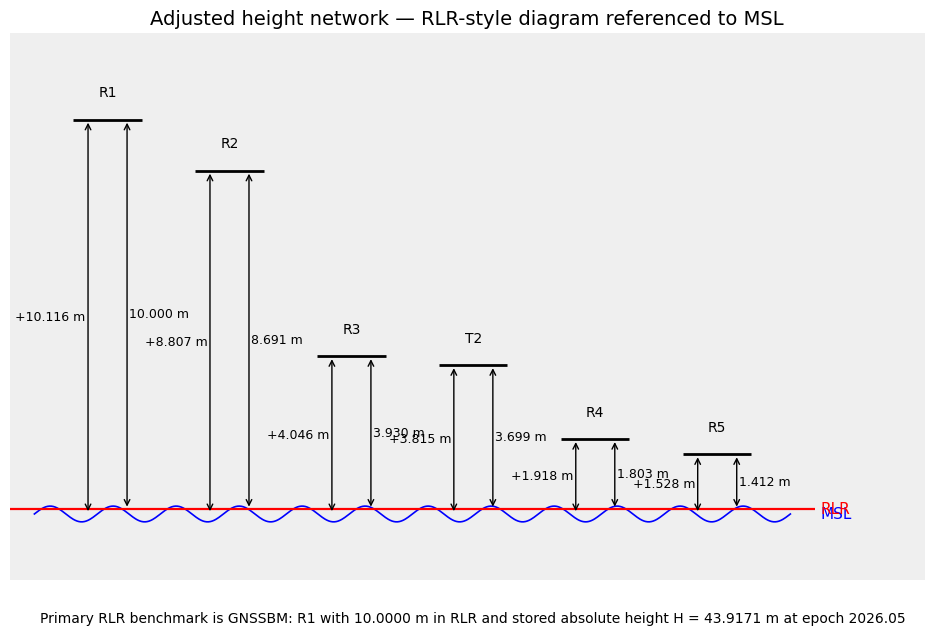

Tide-gauge reference benchmark: T2
Input height of 'T2' relative to MSL: 3.8150 m
Main GNSSBM benchmark: R1
Target local height assigned to GNSSBM 'R1': 10.0000 m
GNSS observation epoch at GNSSBM: 2026.05
Computed RLR level: 0.1159 m relative to MSL
Benchmarks plotted: R1, R2, R3, T2, R4, R5
Primary RLR benchmark is GNSSBM: R1 with 10.0000 m in RLR and stored absolute height H = 43.9171 m at epoch 2026.05


,benchmark,H_hat_m,sigma_H_m,H_above_MSL_m,H_above_RLR_m,is_fixed
0,R1,43.917095,0.000000,10.115852,10.000000,True
1,R2,42.608186,0.000768,8.806943,8.691091,False
2,R3,37.847298,0.001336,4.046055,3.930203,False
3,T2,37.616243,0.001542,3.815000,3.699148,False
4,R4,35.719708,0.001021,1.918465,1.802613,False
5,R5,35.328906,0.000912,1.527663,1.411811,False


In [ ]:
# === Optional Height Step — RLR-style diagram of adjusted height network referenced to MSL ===
# Requires:
# - lsq["heights"] or heights
#
# This cell:
# - retrieves the adjusted height network
# - lists available benchmarks
# - asks which benchmark is the tide-gauge reference point
# - asks for the height of that benchmark relative to MSL
# - asks which benchmark is the main GNSSBM
# - asks for the local-system height assigned to that GNSSBM
# - asks for the epoch of GNSS observations at the GNSSBM
# - asks which benchmarks should be displayed in the diagram
# - reduces all network points to MSL
# - defines the RLR graphical level so that the selected GNSSBM has exactly the user-given local height
# - plots an RLR-style diagram for the selected points
# - if notebook runtime variables b and H exist, prints the requested informational line under the figure

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Retrieve adjusted heights dataframe
# ------------------------------------------------------------
if "lsq" in globals() and isinstance(lsq, dict) and isinstance(lsq.get("heights", None), pd.DataFrame):
    heights_df = lsq["heights"].copy()
elif "heights" in globals() and isinstance(heights, pd.DataFrame):
    heights_df = heights.copy()
else:
    raise RuntimeError("Adjusted height network was not found. Run the LS adjustment cell first.")

required_cols = ["benchmark", "H_hat_m"]
for col in required_cols:
    if col not in heights_df.columns:
        raise RuntimeError(f"Column '{col}' was not found in the adjusted heights dataframe.")

heights_df = heights_df.copy()
heights_df["benchmark"] = heights_df["benchmark"].astype(str).str.strip()
heights_df["H_hat_m"] = heights_df["H_hat_m"].astype(float)

if "sigma_H_m" in heights_df.columns:
    heights_df["sigma_H_m"] = pd.to_numeric(heights_df["sigma_H_m"], errors="coerce")

if "is_fixed" in heights_df.columns:
    heights_df["is_fixed"] = heights_df["is_fixed"].fillna(False).astype(bool)

heights_df = heights_df.drop_duplicates(subset=["benchmark"]).reset_index(drop=True)

if heights_df.empty:
    raise RuntimeError("The adjusted heights dataframe is empty.")

# ------------------------------------------------------------
# 2) Show available benchmarks
# ------------------------------------------------------------
available_benchmarks = heights_df["benchmark"].sort_values().tolist()

print("Available benchmarks:")
print(", ".join(available_benchmarks))

# ------------------------------------------------------------
# 3) Ask user for tide-gauge benchmark and its height relative to MSL
# ------------------------------------------------------------
tg_benchmark = input(
    "\nEnter the benchmark that corresponds to the tide-gauge reference point: "
).strip()

if tg_benchmark not in available_benchmarks:
    raise RuntimeError(f"Benchmark '{tg_benchmark}' was not found in the adjusted height network.")

tg_height_above_msl_str = input(
    f"Enter the height of benchmark '{tg_benchmark}' relative to MSL, in meters: "
).strip()

try:
    tg_height_above_msl_m = float(tg_height_above_msl_str.replace(",", "."))
except Exception:
    raise RuntimeError("The height relative to MSL must be a valid numeric value in meters.")

# ------------------------------------------------------------
# 4) Ask user for main GNSSBM and its local-system height
# ------------------------------------------------------------
gnssbm_benchmark = input(
    "\nEnter the main GNSSBM benchmark: "
).strip()

if gnssbm_benchmark not in available_benchmarks:
    raise RuntimeError(f"Benchmark '{gnssbm_benchmark}' was not found in the adjusted height network.")

gnssbm_local_height_str = input(
    f"Enter the local height assigned to GNSSBM '{gnssbm_benchmark}', in meters: "
).strip()

try:
    gnssbm_local_height_m = float(gnssbm_local_height_str.replace(",", "."))
except Exception:
    raise RuntimeError("The GNSSBM local height must be a valid numeric value in meters.")

# ------------------------------------------------------------
# 5) Ask user for GNSS observation epoch at GNSSBM
# ------------------------------------------------------------
epoch_gnssbm = input(
    f"Enter the GNSS observation epoch for GNSSBM '{gnssbm_benchmark}': "
).strip()

if epoch_gnssbm == "":
    raise RuntimeError("The GNSS observation epoch must not be empty.")

# ------------------------------------------------------------
# 6) Ask user which benchmarks should be displayed in the diagram
# ------------------------------------------------------------
print("\nAvailable benchmarks for plotting:")
print(", ".join(available_benchmarks))

plot_benchmarks_input = input(
    "Enter benchmark names to plot, separated by commas, or type ALL: "
).strip()

if plot_benchmarks_input == "":
    raise RuntimeError("No benchmark selection was given for plotting.")

if plot_benchmarks_input.upper() == "ALL":
    selected_plot_benchmarks = available_benchmarks.copy()
else:
    selected_plot_benchmarks = [p.strip() for p in plot_benchmarks_input.split(",") if p.strip() != ""]
    invalid_plot_benchmarks = [p for p in selected_plot_benchmarks if p not in available_benchmarks]
    if invalid_plot_benchmarks:
        raise RuntimeError(
            "The following benchmark(s) were not found in the adjusted height network: "
            + ", ".join(invalid_plot_benchmarks)
        )

if len(selected_plot_benchmarks) == 0:
    raise RuntimeError("The list of selected benchmarks for plotting is empty.")

# ------------------------------------------------------------
# 7) Reduce all points to MSL
# ------------------------------------------------------------
H_tg_local = float(
    heights_df.loc[heights_df["benchmark"] == tg_benchmark, "H_hat_m"].iloc[0]
)

# Absolute height of each benchmark above MSL:
# H_MSL(point) = H_MSL(TG point) + [H_local(point) - H_local(TG point)]
heights_df["H_above_MSL_m"] = tg_height_above_msl_m + (heights_df["H_hat_m"] - H_tg_local)

# ------------------------------------------------------------
# 8) Define RLR level from the main GNSSBM condition
# ------------------------------------------------------------
H_gnssbm_above_MSL_m = float(
    heights_df.loc[heights_df["benchmark"] == gnssbm_benchmark, "H_above_MSL_m"].iloc[0]
)

# Enforce:
# H_above_RLR(GNSSBM) = gnssbm_local_height_m
# => H_above_MSL(GNSSBM) - RLR = gnssbm_local_height_m
# => RLR = H_above_MSL(GNSSBM) - gnssbm_local_height_m
rlr_y = H_gnssbm_above_MSL_m - gnssbm_local_height_m

heights_df["H_above_RLR_m"] = heights_df["H_above_MSL_m"] - rlr_y

# ------------------------------------------------------------
# 9) Detect runtime variables b and H from notebook
# ------------------------------------------------------------
runtime_info_text = None
if "b" in globals() and "H" in globals():
    try:
        runtime_b_value = str(globals()["b"]).strip()
        runtime_H_value = float(globals()["H"])
        runtime_info_text = (
            f"Primary RLR benchmark is GNSSBM: {runtime_b_value} "
            f"with {gnssbm_local_height_m:.4f} m in RLR and stored absolute height "
            f"H = {runtime_H_value:.4f} m at epoch {epoch_gnssbm}"
        )
    except Exception:
        runtime_info_text = None

# ------------------------------------------------------------
# 10) Keep only selected benchmarks for plotting
# ------------------------------------------------------------
plot_df = (
    heights_df[heights_df["benchmark"].isin(selected_plot_benchmarks)]
    .copy()
    .sort_values(["H_above_MSL_m", "benchmark"], ascending=[False, True])
    .reset_index(drop=True)
)

if plot_df.empty:
    raise RuntimeError("No benchmarks remained after plot selection.")

n_pts = len(plot_df)
x_pos = np.arange(n_pts, dtype=float)
plot_df["x"] = x_pos

# ------------------------------------------------------------
# 11) Plot RLR-style diagram
# ------------------------------------------------------------
msl_y = 0.0
min_y = float(min(plot_df["H_above_MSL_m"].min(), rlr_y, msl_y))
max_y = float(max(plot_df["H_above_MSL_m"].max(), rlr_y, msl_y))
span_y = max(max_y - min_y, 1.0)

fig_width = max(11, 1.55 * n_pts + 2.5)
fig, ax = plt.subplots(figsize=(fig_width, 7.6))
ax.set_facecolor("#efefef")

# MSL wavy line
wave_x = np.linspace(-0.6, n_pts - 0.4, 800)
wave_amp = 0.02 * span_y
wave_y = msl_y + wave_amp * np.sin(
    2 * np.pi * 12 * (wave_x - wave_x.min()) / (wave_x.max() - wave_x.min() + 1e-12)
)
ax.plot(wave_x, wave_y, color="blue", linewidth=1.2, zorder=1)

# RLR line
ax.hlines(rlr_y, -0.8, n_pts - 0.2, colors="red", linewidth=1.6, zorder=1)

# Benchmark levels, arrows and labels
seg_half = 0.28
label_dy = 0.05 * span_y
txt_fs = 10
val_fs = 9

for _, r in plot_df.iterrows():
    x = float(r["x"])
    y = float(r["H_above_MSL_m"])
    bm = str(r["benchmark"]).strip()

    # benchmark level
    ax.hlines(y, x - seg_half, x + seg_half, colors="black", linewidth=2.0, zorder=3)

    # benchmark name
    ax.text(
        x,
        y + label_dy,
        bm,
        ha="center",
        va="bottom",
        fontsize=txt_fs,
        color="black",
        zorder=4
    )

    # arrow from MSL to benchmark
    x_left = x - 0.16
    ax.annotate(
        "",
        xy=(x_left, y),
        xytext=(x_left, msl_y),
        arrowprops=dict(arrowstyle="<->", lw=1.0, color="black"),
        zorder=2
    )
    ax.text(
        x_left - 0.02,
        0.5 * (y + msl_y),
        f"{y:+.3f} m",
        ha="right",
        va="center",
        fontsize=val_fs,
        color="black",
        zorder=4
    )

    # arrow from RLR to benchmark
    x_right = x + 0.16
    ax.annotate(
        "",
        xy=(x_right, y),
        xytext=(x_right, rlr_y),
        arrowprops=dict(arrowstyle="<->", lw=1.0, color="black"),
        zorder=2
    )
    ax.text(
        x_right + 0.02,
        0.5 * (y + rlr_y),
        f"{float(r['H_above_RLR_m']):.3f} m",
        ha="left",
        va="center",
        fontsize=val_fs,
        color="black",
        zorder=4
    )

# Labels for MSL and RLR
ax.text(
    n_pts - 0.15,
    msl_y,
    "MSL",
    ha="left",
    va="center",
    fontsize=11,
    color="blue",
    zorder=4
)

ax.text(
    n_pts - 0.15,
    rlr_y,
    "RLR",
    ha="left",
    va="center",
    fontsize=11,
    color="red",
    zorder=4
)

# Title
ax.set_title("Adjusted height network — RLR-style diagram referenced to MSL", fontsize=14)

# Clean axes
ax.set_xlim(-0.8, n_pts - 0.2 + 0.9)
ax.set_ylim(rlr_y - 0.18 * span_y, max_y + 0.22 * span_y)
ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

# Informational text under figure, if runtime b and H exist
if runtime_info_text is not None:
    fig.subplots_adjust(bottom=0.16)
    fig.text(
        0.15,
        0.1,
        runtime_info_text,
        ha="left",
        va="bottom",
        fontsize=10,
        color="black"
    )
else:
    fig.subplots_adjust(bottom=0.10)

plt.show()

# ------------------------------------------------------------
# 12) Output reduced heights table
# ------------------------------------------------------------
cols_out = ["benchmark", "H_hat_m", "H_above_MSL_m", "H_above_RLR_m"]
if "sigma_H_m" in plot_df.columns:
    cols_out.insert(2, "sigma_H_m")
if "is_fixed" in plot_df.columns:
    cols_out.append("is_fixed")

rlr_results = plot_df[cols_out].copy().reset_index(drop=True)

print(f"Tide-gauge reference benchmark: {tg_benchmark}")
print(f"Input height of '{tg_benchmark}' relative to MSL: {tg_height_above_msl_m:.4f} m")
print(f"Main GNSSBM benchmark: {gnssbm_benchmark}")
print(f"Target local height assigned to GNSSBM '{gnssbm_benchmark}': {gnssbm_local_height_m:.4f} m")
print(f"GNSS observation epoch at GNSSBM: {epoch_gnssbm}")
print(f"Computed RLR level: {rlr_y:.4f} m relative to MSL")
print("Benchmarks plotted:", ", ".join(plot_df["benchmark"].tolist()))

if runtime_info_text is not None:
    print(runtime_info_text)
else:
    print("Notebook runtime variables 'b' and/or 'H' were not found or could not be interpreted.")

display(rlr_results)

## Optional extension: 2D horizontal network adjustment (N, E or lat, lon)

These cells extend the notebook from the vertical-only solution to an optional **2D horizontal adjustment**.

**Important model requirement:** a horizontal solution is possible only if the input workbook contains a horizontal observation, i.e. a **local horizontal direction** (`Hz`) or a **global azimuth/bearing** column.  
The existing vertical workflow alone (`from`, `to`, `V_gon`, `slope_m`, `HI`, `HT`) is **not sufficient** for unique planimetric coordinates.

**Observation model used here**
- Horizontal distance is computed as  
  `HD = slope * sin(Z)`  
  where `Z = V_gon * π / 200`
- Optional planimetric observations:
  - `hz_local`: local horizontal directions from each occupied station, with one unknown orientation parameter per setup station
  - `azimuth_global`: global azimuth/bearing observations, with no station orientation unknowns

**Datum requirements**
- `hz_local` mode: at least **2 fixed points** with known coordinates
- `azimuth_global` mode: at least **1 fixed point** with known coordinates

**Approximate coordinates**
- Because the 2D adjustment is nonlinear, approximate coordinates are required for **all** points before the solver cell is run.
- You may provide them either as:
  - `N_m`, `E_m`, or
  - `lat_deg`, `lon_deg`  
    In that case the solver converts them internally to a local EN frame using an azimuthal equidistant projection.


## Optional 2D Step 1 — Detect horizontal observations and compute horizontal distance

This cell starts the optional 2D extension of the notebook.

**Main role**
- detect horizontal-direction information in the workbook,
- parse the relevant angular field,
- compute horizontal distance from slope distance and zenith angle,
- build the planimetric observation dataframe `obs_xy`.

In [ ]:

# === Optional 2D Step 1 — Detect horizontal observations and compute horizontal distance ===
# Name: optional_xy_prepare_observations
# Description:
# - Detect local horizontal direction column (Hz) and/or global azimuth/bearing column
# - Parse the detected angle column
# - Compute horizontal distance HD = slope * sin(Z)
# - Merge these optional planimetric observations into a DataFrame `obs_xy`

import numpy as np
import pandas as pd

def _find_col(df, candidates):
    cols = set(df.columns)
    for c in candidates:
        if c in cols:
            return c
    return None

def _parse_float_local(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    s = str(x).strip()
    if s in ["", "-", "—", "–", "nan", "NaN", "None"]:
        return np.nan
    s = s.replace(",", ".")
    token = s.split()[0]
    try:
        return float(token)
    except Exception:
        import re
        m = re.search(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", s)
        return float(m.group(0)) if m else np.nan

def _angle_unit_from_name(colname):
    if colname is None:
        return None
    s = str(colname).lower()
    if ("deg" in s) or ("°" in s):
        return "deg"
    return "gon"

def _angle_to_rad(values, unit):
    values = np.asarray(values, dtype=float)
    if unit == "deg":
        return values * np.pi / 180.0
    if unit == "gon":
        return values * np.pi / 200.0
    raise ValueError(f"Unsupported angle unit: {unit}")

# Candidate columns
col_hz = _find_col(df_raw, [
    "Hz [gon]", "Hz(gon)", "Hz", "Horizontal Direction [gon]", "Horizontal Direction",
    "Direction [gon]", "Direction", "Hz [deg]", "Direction [deg]"
])

col_az = _find_col(df_raw, [
    "Azimuth [gon]", "Azimuth", "Bearing [gon]", "Bearing",
    "Azimuth [deg]", "Bearing [deg]"
])

unit_hz = _angle_unit_from_name(col_hz)
unit_az = _angle_unit_from_name(col_az)

# Build a merge key exactly like the vertical-comparison cell
tmp_raw = df_raw.copy()

col_from_raw = _find_col(df_raw, ["From Station", "From", "Station", "Station Name", "Setup Station"])
col_to_raw   = _find_col(df_raw, ["To", "Target", "To Station", "Point", "Sight To"])
col_face_raw = _find_col(df_raw, ["Face", "FACE"])
col_v_raw    = _find_col(df_raw, ["V [gon]", "V(gon)", "V", "Zenith [gon]", "Zenith", "Z [gon]"])
col_sd_raw   = _find_col(df_raw, ["Slope Dist. [m]", "Slope Dist [m]", "Slope Distance [m]", "Slope [m]", "SD [m]"])
col_ht_raw   = _find_col(df_raw, ["Target Height [m]", "Target Height", "HT [m]", "Prism Height [m]", "Reflector Height [m]"])

tmp_raw["_from"] = tmp_raw[col_from_raw].astype(str).str.strip()
tmp_raw["_to"]   = tmp_raw[col_to_raw].astype(str).str.strip()
tmp_raw["_face"] = tmp_raw[col_face_raw].astype(str).str.strip().str.upper()
tmp_raw["_V_gon"] = tmp_raw[col_v_raw].apply(_parse_float_local)
tmp_raw["_slope_m"] = tmp_raw[col_sd_raw].apply(_parse_float_local)
tmp_raw["_HI_m"] = tmp_raw[config["hi_col"]].apply(_parse_float_local)
tmp_raw["_HT_m"] = tmp_raw[col_ht_raw].apply(_parse_float_local)

raw_key_cols = ["_from","_to","_face","_V_gon","_slope_m","_HI_m","_HT_m"]
raw_cmp = tmp_raw[raw_key_cols].copy()

if col_hz is not None:
    raw_cmp["Hz_raw"] = tmp_raw[col_hz].apply(_parse_float_local)

if col_az is not None:
    raw_cmp["Az_raw"] = tmp_raw[col_az].apply(_parse_float_local)

obs_xy = obs.copy()
obs_xy["_from"] = obs_xy["from"]
obs_xy["_to"] = obs_xy["to"]
obs_xy["_face"] = obs_xy["face"]
obs_xy["_V_gon"] = obs_xy["V_gon"]
obs_xy["_slope_m"] = obs_xy["slope_m"]
obs_xy["_HI_m"] = obs_xy["HI_m"]
obs_xy["_HT_m"] = obs_xy["HT_m"]

obs_xy = obs_xy.merge(raw_cmp, on=raw_key_cols, how="left")

# Horizontal distance from zenith angle
if "Z_rad" not in obs_xy.columns:
    obs_xy["Z_rad"] = obs_xy["V_gon"].astype(float) * np.pi / 200.0
obs_xy["HD_C_m"] = obs_xy["slope_m"].astype(float) * np.sin(obs_xy["Z_rad"].astype(float))

# Stable observation id for 2D processing
obs_xy = obs_xy.reset_index(drop=True).copy()
obs_xy["obs_id_xy"] = np.arange(len(obs_xy), dtype=int)

xy_prepare = {
    "col_hz": col_hz,
    "unit_hz": unit_hz,
    "col_az": col_az,
    "unit_az": unit_az,
    "n_obs": int(len(obs_xy)),
    "n_hz_finite": int(np.isfinite(obs_xy["Hz_raw"]).sum()) if "Hz_raw" in obs_xy.columns else 0,
    "n_az_finite": int(np.isfinite(obs_xy["Az_raw"]).sum()) if "Az_raw" in obs_xy.columns else 0,
}

print("Horizontal-observation detection summary:")
print(xy_prepare)

if col_hz is None and col_az is None:
    print("\nWARNING: No horizontal direction / azimuth column was detected in df_raw.")
    print("A unique 2D coordinate adjustment is therefore not possible until such a column exists in the input workbook.")

print("\nAdded planimetric preparation DataFrame: obs_xy")
display(obs_xy.head(20))


Horizontal-observation detection summary:
{'col_hz': None, 'unit_hz': None, 'col_az': 'Azimuth [gon]', 'unit_az': 'gon', 'n_obs': 296, 'n_hz_finite': 0, 'n_az_finite': 296}

Added planimetric preparation DataFrame: obs_xy


,from,to,face,V_gon,slope_m,HI_m,HT_m,datetime,is_valid,Z_rad,...,_from,_to,_face,_V_gon,_slope_m,_HI_m,_HT_m,Az_raw,HD_C_m,obs_id_xy
0,R1,R2,I,108.0436,21.6415,1.51896,0.1,2026-01-19,True,1.697145,...,R1,R2,I,108.0436,21.6415,1.51896,0.1,81.6977,21.468988,0
1,R1,R2,I,108.0442,21.6415,1.51896,0.1,2026-01-19,True,1.697154,...,R1,R2,I,108.0442,21.6415,1.51896,0.1,81.6982,21.468962,1
2,R1,R2,I,108.0444,21.6408,1.51896,0.1,2026-01-19,True,1.697157,...,R1,R2,I,108.0444,21.6408,1.51896,0.1,81.6981,21.468259,2
3,R1,R2,I,108.0454,21.6420,1.51896,0.1,2026-01-19,True,1.697173,...,R1,R2,I,108.0454,21.6420,1.51896,0.1,81.6973,21.469407,3
4,R1,R2,I,108.0438,21.6422,1.51896,0.1,2026-01-19,True,1.697148,...,R1,R2,I,108.0438,21.6422,1.51896,0.1,81.6972,21.469673,4
5,R1,R2,I,108.0437,21.6422,1.51896,0.1,2026-01-19,True,1.697146,...,R1,R2,I,108.0437,21.6422,1.51896,0.1,81.6973,21.469678,5
6,R1,R2,I,108.0437,21.6422,1.51896,0.1,2026-01-19,True,1.697146,...,R1,R2,I,108.0437,21.6422,1.51896,0.1,81.6981,21.469678,6
7,R1,R2,I,108.0440,21.6420,1.51896,0.1,2026-01-19,True,1.697151,...,R1,R2,I,108.0440,21.6420,1.51896,0.1,81.6976,21.469467,7
8,R1,R2,I,108.0447,21.6421,1.51896,0.1,2026-01-19,True,1.697162,...,R1,R2,I,108.0447,21.6421,1.51896,0.1,81.6976,21.469536,8
9,R1,R2,I,108.0447,21.6421,1.51896,0.1,2026-01-19,True,1.697162,...,R1,R2,I,108.0447,21.6421,1.51896,0.1,81.6976,21.469536,9


## Optional 2D Step 1A — Input a priori instrument accuracies

This cell records the a priori instrument-accuracy parameters used in the horizontal stochastic model.

**Main role**
- ask for the distance constant term,
- ask for the distance proportional term,
- ask for the direction accuracy,
- convert all quantities to the internal units used later in the 2D adjustment.

In [ ]:
# --- A priori instrument accuracies for 2D adjustment ---
sigma_dist_const_mm = float(input("Enter distance accuracy constant term a [mm] (e.g. 0.3): ").strip().replace(",", "."))
sigma_dist_ppm      = float(input("Enter distance accuracy proportional term b [ppm] (e.g. 13): ").strip().replace(",", "."))
sigma_dir_arcsec    = float(input("Enter direction accuracy c [arcsec] (e.g. 0.5): ").strip().replace(",", "."))

# --- Unit conversions ---
sigma_dist_const_m = sigma_dist_const_mm / 1000.0
sigma_dir_gon = sigma_dir_arcsec * (10.0 / (9.0 * 3600.0))

print("\nA priori stochastic model parameters:")
print(f"Distance: ±({sigma_dist_const_mm:.6f} mm + {sigma_dist_ppm:.6f} ppm)")
print(f"Direction: ±{sigma_dir_arcsec:.6f} arcsec")
print("\nConverted internal units:")
print(f"sigma_dist_const_m = {sigma_dist_const_m:.12f} m")
print(f"sigma_dir_gon      = {sigma_dir_gon:.12f} gon")

Enter distance accuracy constant term a [mm] (e.g. 0.3): 0.3
Enter distance accuracy proportional term b [ppm] (e.g. 13): 13
Enter direction accuracy c [arcsec] (e.g. 0.5): 0.5

A priori stochastic model parameters:
Distance: ±(0.300000 mm + 13.000000 ppm)
Direction: ±0.500000 arcsec

Converted internal units:
sigma_dist_const_m = 0.000300000000 m
sigma_dir_gon      = 0.000154320988 gon


## Optional 2D Step 1B — Directed-edge internal precision and QC for horizontal observables

This cell evaluates repeatability and performs optional QC for the main horizontal observables.

**Main role**
- summarize precision for horizontal distance `HD_C_m`,
- summarize precision for opened direction `Hz_open_gon`,
- perform optional `k·σ` outlier flagging,
- optionally overwrite `obs_xy` with a cleaned dataset for later 2D processing.

In [ ]:
# === Optional 2D Step 1B — Directed-edge internal precision + QC (horizontal) ===
# Name: optional_xy_directed_edge_precision_and_qc
# Description:
# - Computes directed-edge internal precision for the PRIMARY horizontal observables:
#     * HD_C_m       (horizontal distance)
#     * Hz_open_gon  (opened local direction, as already given in the workbook)
# - Reports overall + per-face statistics for each directed edge (from -> to)
# - Optional QC per observable:
#     * mode="combined": per (from->to) using both faces together
#     * mode="per_face": per (from->to->face) using each face separately
# - Flags:
#     * |HD - mean(sample)| > k * std(sample)
#     * |wrap(Hz - mean(sample))| > k * std(sample)
# - Optionally drops flagged observations and overwrites obs_xy for the next 2D cells
# - Saves results in dict: qc_edge_xy
#
# Notes:
# - This cell performs INTERNAL QC on the raw horizontal observables.
# - It does NOT use ΔN / ΔE and does NOT depend on the network datum.
# - IMPORTANT:
#   In this workbook, the field 'Azimuth [gon]' is already an OPENED LOCAL DIRECTION
#   in a common direction system for both faces. Therefore NO ±200 gon face-II shift
#   is applied here.

import numpy as np
import pandas as pd

if "obs_xy" not in globals():
    raise RuntimeError("obs_xy was not found. Run Optional 2D Step 1 first.")

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _std_ddof1(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) <= 1:
        return 0.0
    return float(np.std(x, ddof=1))

def _se_from_std(std, n):
    return float(std / np.sqrt(n)) if n > 0 else np.nan

def _wrap_gon_0_400(g):
    g = np.asarray(g, dtype=float)
    return np.mod(g, 400.0)

def _wrap_gon_pm200(g):
    g = np.asarray(g, dtype=float)
    return (g + 200.0) % 400.0 - 200.0

def _circular_mean_gon(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan
    ang = vals * np.pi / 200.0
    s = np.mean(np.sin(ang))
    c = np.mean(np.cos(ang))
    if np.isclose(s, 0.0) and np.isclose(c, 0.0):
        ref = vals[0]
        unwrapped = ref + _wrap_gon_pm200(vals - ref)
        return float(_wrap_gon_0_400(np.mean(unwrapped)))
    return float(_wrap_gon_0_400(np.arctan2(s, c) * 200.0 / np.pi))

def _circular_std_ddof1_gon(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) <= 1:
        return 0.0
    mu = _circular_mean_gon(vals)
    res = _wrap_gon_pm200(vals - mu)
    return float(np.std(res, ddof=1))

# ------------------------------------------------------------
# Prepare working horizontal-observation table
# ------------------------------------------------------------
obs_xy_work = obs_xy.copy()

obs_xy_work["from"] = obs_xy_work["from"].astype(str).str.strip()
obs_xy_work["to"]   = obs_xy_work["to"].astype(str).str.strip()
obs_xy_work["face"] = obs_xy_work["face"].astype(str).str.strip().str.upper()

# Stable row id for dropping
if "obs_id_xy" not in obs_xy_work.columns:
    obs_xy_work = obs_xy_work.reset_index(drop=True)
    obs_xy_work["obs_id_xy"] = np.arange(len(obs_xy_work), dtype=int)

# Reclassify local direction field if needed
if ("Hz_raw" not in obs_xy_work.columns or obs_xy_work["Hz_raw"].isna().all()) and ("Az_raw" in obs_xy_work.columns):
    obs_xy_work["Hz_raw"] = obs_xy_work["Az_raw"]
    print("Reclassified 'Az_raw' as local direction field 'Hz_raw'.")

if "HD_C_m" not in obs_xy_work.columns:
    raise RuntimeError("HD_C_m was not found in obs_xy.")

# Use absolute horizontal distance magnitude
obs_xy_work["HD_C_m"] = pd.to_numeric(obs_xy_work["HD_C_m"], errors="coerce").abs()

# Build opened horizontal direction
# IMPORTANT:
# In this workbook, the direction field is already an opened local direction.
# Therefore face I and face II must remain in the SAME direction system.
# No ±200 gon transformation is applied here.
if "Hz_raw" in obs_xy_work.columns:
    obs_xy_work["Hz_raw"] = pd.to_numeric(obs_xy_work["Hz_raw"], errors="coerce")
else:
    obs_xy_work["Hz_raw"] = np.nan

obs_xy_work["Hz_open_gon"] = obs_xy_work["Hz_raw"].copy()

# Keep original copy before any QC drop
obs_xy_original = obs_xy_work.copy()

# ------------------------------------------------------------
# Table I equivalents for horizontal observables
# ------------------------------------------------------------
def _compute_table_hd(obs_df):
    rows = []
    for (f, t), g in obs_df.groupby(["from", "to"]):
        vals_all = pd.to_numeric(g["HD_C_m"], errors="coerce").dropna().values
        n_all = len(vals_all)
        mean_all = float(np.mean(vals_all)) if n_all > 0 else np.nan
        std_all = _std_ddof1(vals_all) if n_all > 0 else np.nan
        se_all = _se_from_std(std_all, n_all) if n_all > 0 else np.nan

        gI = pd.to_numeric(g.loc[g["face"] == "I", "HD_C_m"], errors="coerce").dropna().values
        gII = pd.to_numeric(g.loc[g["face"] == "II", "HD_C_m"], errors="coerce").dropna().values

        nI, nII = len(gI), len(gII)
        meanI = float(np.mean(gI)) if nI > 0 else np.nan
        meanII = float(np.mean(gII)) if nII > 0 else np.nan
        stdI = _std_ddof1(gI) if nI > 0 else np.nan
        stdII = _std_ddof1(gII) if nII > 0 else np.nan
        seI = _se_from_std(stdI, nI) if nI > 0 else np.nan
        seII = _se_from_std(stdII, nII) if nII > 0 else np.nan

        rows.append({
            "from": f, "to": t,
            "n_all": n_all, "mean_all_m": mean_all, "std_all_m": std_all, "se_all_m": se_all,
            "n_I": nI, "mean_I_m": meanI, "std_I_m": stdI, "se_I_m": seI,
            "n_II": nII, "mean_II_m": meanII, "std_II_m": stdII, "se_II_m": seII,
            "mean_I_minus_II_m": (meanI - meanII) if (np.isfinite(meanI) and np.isfinite(meanII)) else np.nan,
        })
    return pd.DataFrame(rows).sort_values(["from", "to"]).reset_index(drop=True)

def _compute_table_hz(obs_df):
    rows = []
    for (f, t), g in obs_df.groupby(["from", "to"]):
        vals_all = pd.to_numeric(g["Hz_open_gon"], errors="coerce").dropna().values
        n_all = len(vals_all)
        mean_all = _circular_mean_gon(vals_all) if n_all > 0 else np.nan
        std_all = _circular_std_ddof1_gon(vals_all) if n_all > 0 else np.nan
        se_all = _se_from_std(std_all, n_all) if n_all > 0 else np.nan

        gI = pd.to_numeric(g.loc[g["face"] == "I", "Hz_open_gon"], errors="coerce").dropna().values
        gII = pd.to_numeric(g.loc[g["face"] == "II", "Hz_open_gon"], errors="coerce").dropna().values

        nI, nII = len(gI), len(gII)
        meanI = _circular_mean_gon(gI) if nI > 0 else np.nan
        meanII = _circular_mean_gon(gII) if nII > 0 else np.nan
        stdI = _circular_std_ddof1_gon(gI) if nI > 0 else np.nan
        stdII = _circular_std_ddof1_gon(gII) if nII > 0 else np.nan
        seI = _se_from_std(stdI, nI) if nI > 0 else np.nan
        seII = _se_from_std(stdII, nII) if nII > 0 else np.nan

        rows.append({
            "from": f, "to": t,
            "n_all": n_all, "mean_all_gon": mean_all, "std_all_gon": std_all, "se_all_gon": se_all,
            "n_I": nI, "mean_I_gon": meanI, "std_I_gon": stdI, "se_I_gon": seI,
            "n_II": nII, "mean_II_gon": meanII, "std_II_gon": stdII, "se_II_gon": seII,
            "mean_I_minus_II_gon": _wrap_gon_pm200(meanI - meanII) if (np.isfinite(meanI) and np.isfinite(meanII)) else np.nan,
        })
    return pd.DataFrame(rows).sort_values(["from", "to"]).reset_index(drop=True)

edge_precision_xy_hd = _compute_table_hd(obs_xy_work)
edge_precision_xy_hz = _compute_table_hz(obs_xy_work)

print("Directed-edge internal precision (overall + per face) — HD_C_m:")
display(edge_precision_xy_hd)

print("\nDirected-edge internal precision (overall + per face) — Hz_open_gon:")
display(edge_precision_xy_hz)

# ------------------------------------------------------------
# QC helpers
# ------------------------------------------------------------
def _flag_outliers_linear(obs_df, value_col, group_cols, k_used, observable_name):
    flag_rows = []

    for _, g in obs_df.groupby(group_cols):
        vals = pd.to_numeric(g[value_col], errors="coerce").values.astype(float)
        finite = np.isfinite(vals)
        if finite.sum() == 0:
            continue

        g2 = g.loc[finite].copy()
        vals2 = vals[finite]

        mu = float(np.mean(vals2))
        sig = _std_ddof1(vals2)
        if sig == 0.0:
            is_out = np.zeros(len(g2), dtype=bool)
        else:
            is_out = np.abs(vals2 - mu) > k_used * sig

        if np.any(is_out):
            tmp = g2.loc[is_out, [
                "obs_id_xy", "from", "to", "face", "datetime",
                "V_gon", "slope_m", "HI_m", "HT_m", "HD_C_m", "Hz_raw", "Hz_open_gon"
            ]].copy()
            tmp["observable"] = observable_name
            tmp["sample_mean"] = mu
            tmp["sample_std"] = sig
            tmp["residual"] = tmp[value_col].astype(float) - mu
            tmp["k_used"] = k_used
            tmp["qc_mode"] = "combined" if group_cols == ["from", "to"] else "per_face"
            if "face" not in group_cols:
                tmp["sample_face"] = np.nan
            else:
                tmp["sample_face"] = tmp["face"]
            flag_rows.append(tmp)

    return pd.concat(flag_rows, ignore_index=True) if flag_rows else pd.DataFrame()

def _flag_outliers_circular_gon(obs_df, value_col, group_cols, k_used, observable_name):
    flag_rows = []

    for _, g in obs_df.groupby(group_cols):
        vals = pd.to_numeric(g[value_col], errors="coerce").values.astype(float)
        finite = np.isfinite(vals)
        if finite.sum() == 0:
            continue

        g2 = g.loc[finite].copy()
        vals2 = vals[finite]

        mu = _circular_mean_gon(vals2)
        sig = _circular_std_ddof1_gon(vals2)
        res = _wrap_gon_pm200(vals2 - mu)

        if sig == 0.0:
            is_out = np.zeros(len(g2), dtype=bool)
        else:
            is_out = np.abs(res) > k_used * sig

        if np.any(is_out):
            tmp = g2.loc[is_out, [
                "obs_id_xy", "from", "to", "face", "datetime",
                "V_gon", "slope_m", "HI_m", "HT_m", "HD_C_m", "Hz_raw", "Hz_open_gon"
            ]].copy()
            tmp["observable"] = observable_name
            tmp["sample_mean"] = mu
            tmp["sample_std"] = sig
            tmp["residual"] = _wrap_gon_pm200(tmp[value_col].astype(float) - mu)
            tmp["k_used"] = k_used
            tmp["qc_mode"] = "combined" if group_cols == ["from", "to"] else "per_face"
            if "face" not in group_cols:
                tmp["sample_face"] = np.nan
            else:
                tmp["sample_face"] = tmp["face"]
            flag_rows.append(tmp)

    return pd.concat(flag_rows, ignore_index=True) if flag_rows else pd.DataFrame()

# ------------------------------------------------------------
# Optional QC
# ------------------------------------------------------------
print("\n--- Directed-edge QC (optional) ---", flush=True)

apply_qc_hd = input("Apply directed-edge QC (k·σ) on HD_C_m? (y/n): ").strip().lower()
if apply_qc_hd not in ["y", "n"]:
    raise ValueError("Please answer with 'y' or 'n'.")

apply_qc_hz = input("Apply directed-edge QC (k·σ) on Hz_open_gon? (y/n): ").strip().lower()
if apply_qc_hz not in ["y", "n"]:
    raise ValueError("Please answer with 'y' or 'n'.")

k_used_edge_qc_hd = None
k_used_edge_qc_hz = None
qc_mode_edge_qc_hd = None
qc_mode_edge_qc_hz = None

flagged_parts = []

if apply_qc_hd == "y":
    qc_mode_edge_qc_hd = input(
        "QC sample for HD_C_m: 'combined' (faces I+II together) or 'per_face' (each face separately)? "
    ).strip().lower()
    if qc_mode_edge_qc_hd not in ["combined", "per_face"]:
        raise ValueError("Invalid choice. Use 'combined' or 'per_face'.")

    k_used_edge_qc_hd = float(
        input("Enter k for |HD - mean(sample)| > k*std(sample) (e.g., 3): ").strip().replace(",", ".")
    )

    group_cols_hd = ["from", "to"] if qc_mode_edge_qc_hd == "combined" else ["from", "to", "face"]
    flagged_hd = _flag_outliers_linear(
        obs_df=obs_xy_work,
        value_col="HD_C_m",
        group_cols=group_cols_hd,
        k_used=k_used_edge_qc_hd,
        observable_name="HD_C_m"
    )
    if len(flagged_hd) > 0:
        flagged_parts.append(flagged_hd)

if apply_qc_hz == "y":
    qc_mode_edge_qc_hz = input(
        "QC sample for Hz_open_gon: 'combined' (faces I+II together) or 'per_face' (each face separately)? "
    ).strip().lower()
    if qc_mode_edge_qc_hz not in ["combined", "per_face"]:
        raise ValueError("Invalid choice. Use 'combined' or 'per_face'.")

    k_used_edge_qc_hz = float(
        input("Enter k for |wrap(Hz - mean(sample))| > k*std(sample) (e.g., 3): ").strip().replace(",", ".")
    )

    group_cols_hz = ["from", "to"] if qc_mode_edge_qc_hz == "combined" else ["from", "to", "face"]
    flagged_hz = _flag_outliers_circular_gon(
        obs_df=obs_xy_work,
        value_col="Hz_open_gon",
        group_cols=group_cols_hz,
        k_used=k_used_edge_qc_hz,
        observable_name="Hz_open_gon"
    )
    if len(flagged_hz) > 0:
        flagged_parts.append(flagged_hz)

flagged_edge_xy_outliers = (
    pd.concat(flagged_parts, ignore_index=True)
    if flagged_parts else pd.DataFrame(
        columns=[
            "obs_id_xy", "from", "to", "face", "datetime",
            "V_gon", "slope_m", "HI_m", "HT_m", "HD_C_m", "Hz_raw", "Hz_open_gon",
            "observable", "sample_mean", "sample_std", "residual", "k_used", "qc_mode", "sample_face"
        ]
    )
)

# Summary per sample
if len(flagged_edge_xy_outliers) > 0:
    flagged_edge_xy_summary = (
        flagged_edge_xy_outliers
        .groupby(["observable", "qc_mode", "from", "to", "sample_face"], dropna=False)
        .size()
        .reset_index(name="n_flagged")
        .sort_values(["observable", "from", "to", "sample_face"], na_position="last")
        .reset_index(drop=True)
    )
else:
    flagged_edge_xy_summary = pd.DataFrame(
        columns=["observable", "qc_mode", "from", "to", "sample_face", "n_flagged"]
    )

print("\nFlagged outliers per sample:", flush=True)
display(flagged_edge_xy_summary)

if len(flagged_edge_xy_outliers) > 0:
    print("\nFlagged observations (first 50 rows):", flush=True)
    display(flagged_edge_xy_outliers.head(50))
else:
    print("\nNo observations flagged with the chosen settings.", flush=True)

drop_flagged = input("Drop flagged observations and recompute Table I? (y/n): ").strip().lower()
if drop_flagged not in ["y", "n"]:
    raise ValueError("Please answer with 'y' or 'n'.")

if drop_flagged == "y" and len(flagged_edge_xy_outliers) > 0:
    drop_ids = set(flagged_edge_xy_outliers["obs_id_xy"].astype(int).tolist())
    before = len(obs_xy_work)
    obs_xy_qc = obs_xy_work[~obs_xy_work["obs_id_xy"].isin(drop_ids)].copy()
    after = len(obs_xy_qc)
    print(f"\nDropped {before-after} rows. Remaining: {after}", flush=True)
else:
    obs_xy_qc = obs_xy_work.copy()
    print("\nNo rows dropped. Using original horizontal observations as obs_xy_qc.", flush=True)

# Recompute horizontal Table I equivalents after QC
edge_precision_xy_hd_clean = _compute_table_hd(obs_xy_qc)
edge_precision_xy_hz_clean = _compute_table_hz(obs_xy_qc)

print("\nDirected-edge internal precision (overall + per face) AFTER directed-edge QC — HD_C_m:")
display(edge_precision_xy_hd_clean)

print("\nDirected-edge internal precision (overall + per face) AFTER directed-edge QC — Hz_open_gon:")
display(edge_precision_xy_hz_clean)

# Overwrite obs_xy for the next 2D cells
obs_xy = obs_xy_qc.copy()

qc_edge_xy = {
    "obs_xy_original": obs_xy_original,
    "obs_xy_qc": obs_xy_qc,
    "obs_xy_active": obs_xy,

    "edge_precision_xy_hd": edge_precision_xy_hd,
    "edge_precision_xy_hz": edge_precision_xy_hz,

    "edge_precision_xy_hd_clean": edge_precision_xy_hd_clean,
    "edge_precision_xy_hz_clean": edge_precision_xy_hz_clean,

    "flagged_edge_xy_outliers": flagged_edge_xy_outliers,
    "flagged_edge_xy_summary": flagged_edge_xy_summary,

    "apply_qc_hd": apply_qc_hd,
    "apply_qc_hz": apply_qc_hz,
    "k_used_edge_qc_hd": k_used_edge_qc_hd,
    "k_used_edge_qc_hz": k_used_edge_qc_hz,
    "qc_mode_edge_qc_hd": qc_mode_edge_qc_hd,
    "qc_mode_edge_qc_hz": qc_mode_edge_qc_hz,
}

print("\nSaved directed-edge QC results in dict: qc_edge_xy")
print("Key output for next cells: obs_xy (updated), obs_xy_qc")

Reclassified 'Az_raw' as local direction field 'Hz_raw'.
Directed-edge internal precision (overall + per face) — HD_C_m:


,from,to,n_all,mean_all_m,std_all_m,se_all_m,n_I,mean_I_m,std_I_m,se_I_m,n_II,mean_II_m,std_II_m,se_II_m,mean_I_minus_II_m
0,R1,R2,31,21.469475,0.000450,0.000081,17,21.469448,0.000381,0.000092,14,21.469509,0.000534,0.000143,-0.000061
1,R1,R5,23,75.994365,0.000355,0.000074,13,75.994520,0.000383,0.000106,10,75.994164,0.000183,0.000058,0.000356
2,R4,F1,12,17.006076,0.000357,0.000103,6,17.005983,0.000342,0.000140,6,17.006168,0.000379,0.000155,-0.000185
3,R4,F2,12,17.326446,0.000190,0.000055,6,17.326377,0.000107,0.000044,6,17.326515,0.000238,0.000097,-0.000137
4,R4,R1,26,92.990520,0.000148,0.000029,13,92.990507,0.000154,0.000043,13,92.990532,0.000148,0.000041,-0.000025
5,R4,R5,31,21.338696,0.000149,0.000027,17,21.338768,0.000132,0.000032,14,21.338608,0.000120,0.000032,0.000160
6,R4,T1,22,17.261574,0.000273,0.000058,11,17.261410,0.000232,0.000070,11,17.261738,0.000208,0.000063,-0.000328
7,R4,T2,22,17.266229,0.000243,0.000052,11,17.266123,0.000243,0.000073,11,17.266335,0.000201,0.000061,-0.000212
8,R4,T3,22,17.276715,0.000186,0.000040,11,17.276633,0.000145,0.000044,11,17.276797,0.000192,0.000058,-0.000164
9,R5,R1,31,75.992696,0.000125,0.000022,15,75.992655,0.000130,0.000033,16,75.992733,0.000111,0.000028,-0.000078



Directed-edge internal precision (overall + per face) — Hz_open_gon:


,from,to,n_all,mean_all_gon,std_all_gon,se_all_gon,n_I,mean_I_gon,std_I_gon,se_I_gon,n_II,mean_II_gon,std_II_gon,se_II_gon,mean_I_minus_II_gon
0,R1,R2,31,81.697858,0.001536,0.000276,17,81.697629,0.000324,0.000078,14,81.698136,0.002272,0.000607,-0.000506
1,R1,R5,23,223.432004,0.000719,0.000150,13,223.432115,0.000749,0.000208,10,223.431860,0.000688,0.000218,0.000255
2,R4,F1,12,362.822725,0.000586,0.000169,6,362.822483,0.000708,0.000289,6,362.822967,0.000339,0.000138,-0.000483
3,R4,F2,12,373.420575,0.000761,0.000220,6,373.420383,0.000850,0.000347,6,373.420767,0.000680,0.000278,-0.000383
4,R4,R1,26,354.750350,0.000721,0.000141,13,354.750931,0.000444,0.000123,13,354.749769,0.000392,0.000109,0.001162
5,R4,R5,31,318.060529,0.000756,0.000136,17,318.060124,0.000750,0.000182,14,318.061021,0.000389,0.000104,-0.000898
6,R4,T1,22,373.463382,0.000839,0.000179,11,373.463482,0.001025,0.000309,11,373.463282,0.000635,0.000192,0.000200
7,R4,T2,22,373.596836,0.000824,0.000176,11,373.596800,0.000835,0.000252,11,373.596873,0.000851,0.000257,-0.000073
8,R4,T3,22,373.739250,0.000883,0.000188,11,373.738909,0.000942,0.000284,11,373.739591,0.000703,0.000212,-0.000682
9,R5,R1,31,79.838494,0.000855,0.000154,15,79.839180,0.000638,0.000165,16,79.837850,0.000412,0.000103,0.001330



--- Directed-edge QC (optional) ---
Apply directed-edge QC (k·σ) on HD_C_m? (y/n): y
Apply directed-edge QC (k·σ) on Hz_open_gon? (y/n): y
QC sample for HD_C_m: 'combined' (faces I+II together) or 'per_face' (each face separately)? per_face
Enter k for |HD - mean(sample)| > k*std(sample) (e.g., 3): 3
QC sample for Hz_open_gon: 'combined' (faces I+II together) or 'per_face' (each face separately)? per_face
Enter k for |wrap(Hz - mean(sample))| > k*std(sample) (e.g., 3): 3

Flagged outliers per sample:


...

Drop flagged observations and recompute Table I? (y/n): y

Dropped 2 rows. Remaining: 294

Directed-edge internal precision (overall + per face) AFTER directed-edge QC — HD_C_m:


,from,to,n_all,mean_all_m,std_all_m,se_all_m,n_I,mean_I_m,std_I_m,se_I_m,n_II,mean_II_m,std_II_m,se_II_m,mean_I_minus_II_m
0,R1,R2,29,21.469461,0.000262,0.000049,16,21.469522,0.000234,0.000059,13,21.469386,0.000283,0.000079,0.000136
1,R1,R5,23,75.994365,0.000355,0.000074,13,75.994520,0.000383,0.000106,10,75.994164,0.000183,0.000058,0.000356
2,R4,F1,12,17.006076,0.000357,0.000103,6,17.005983,0.000342,0.000140,6,17.006168,0.000379,0.000155,-0.000185
3,R4,F2,12,17.326446,0.000190,0.000055,6,17.326377,0.000107,0.000044,6,17.326515,0.000238,0.000097,-0.000137
4,R4,R1,26,92.990520,0.000148,0.000029,13,92.990507,0.000154,0.000043,13,92.990532,0.000148,0.000041,-0.000025
5,R4,R5,31,21.338696,0.000149,0.000027,17,21.338768,0.000132,0.000032,14,21.338608,0.000120,0.000032,0.000160
6,R4,T1,22,17.261574,0.000273,0.000058,11,17.261410,0.000232,0.000070,11,17.261738,0.000208,0.000063,-0.000328
7,R4,T2,22,17.266229,0.000243,0.000052,11,17.266123,0.000243,0.000073,11,17.266335,0.000201,0.000061,-0.000212
8,R4,T3,22,17.276715,0.000186,0.000040,11,17.276633,0.000145,0.000044,11,17.276797,0.000192,0.000058,-0.000164
9,R5,R1,31,75.992696,0.000125,0.000022,15,75.992655,0.000130,0.000033,16,75.992733,0.000111,0.000028,-0.000078



Directed-edge internal precision (overall + per face) AFTER directed-edge QC — Hz_open_gon:


,from,to,n_all,mean_all_gon,std_all_gon,se_all_gon,n_I,mean_I_gon,std_I_gon,se_I_gon,n_II,mean_II_gon,std_II_gon,se_II_gon,mean_I_minus_II_gon
0,R1,R2,29,81.698110,0.000648,0.000120,16,81.697600,0.000310,0.000077,13,81.698738,0.000290,0.000080,-0.001138
1,R1,R5,23,223.432004,0.000719,0.000150,13,223.432115,0.000749,0.000208,10,223.431860,0.000688,0.000218,0.000255
2,R4,F1,12,362.822725,0.000586,0.000169,6,362.822483,0.000708,0.000289,6,362.822967,0.000339,0.000138,-0.000483
3,R4,F2,12,373.420575,0.000761,0.000220,6,373.420383,0.000850,0.000347,6,373.420767,0.000680,0.000278,-0.000383
4,R4,R1,26,354.750350,0.000721,0.000141,13,354.750931,0.000444,0.000123,13,354.749769,0.000392,0.000109,0.001162
5,R4,R5,31,318.060529,0.000756,0.000136,17,318.060124,0.000750,0.000182,14,318.061021,0.000389,0.000104,-0.000898
6,R4,T1,22,373.463382,0.000839,0.000179,11,373.463482,0.001025,0.000309,11,373.463282,0.000635,0.000192,0.000200
7,R4,T2,22,373.596836,0.000824,0.000176,11,373.596800,0.000835,0.000252,11,373.596873,0.000851,0.000257,-0.000073
8,R4,T3,22,373.739250,0.000883,0.000188,11,373.738909,0.000942,0.000284,11,373.739591,0.000703,0.000212,-0.000682
9,R5,R1,31,79.838494,0.000855,0.000154,15,79.839180,0.000638,0.000165,16,79.837850,0.000412,0.000103,0.001330



Saved directed-edge QC results in dict: qc_edge_xy
Key output for next cells: obs_xy (updated), obs_xy_qc


## Optional 2D Step 2 — Approximate coordinates and datum anchoring

This cell constructs approximate 2D coordinates before the final adjustment.

**Main role**
- derive approximate coordinates from horizontal distances,
- define the horizontal datum using an anchor point and orientation information,
- refine the approximate coordinate set,
- prepare the final starting coordinates for the 2D model.

In [ ]:
# === Optional 2D Step 2 — Distance-consistent approximate coordinates + datum anchoring + refinement ===
# Name: optional_xy_distance_based_approx_coords
# Description:
# - Builds approximate 2D coordinates ONLY from horizontal distances
# - Does NOT use local directions for coordinate seeding
# - Applies user-defined datum anchoring:
#     1) anchor point
#     2) known N,E at anchor
#     3) orientation point
#     4) known azimuth anchor -> orientation point [gon]
# - Refines all other points from the anchored distance graph
# - Produces the FINAL refined coords_xy_input for the next 2D steps
#
# IMPORTANT:
# Each occupied station ('from') has its own unknown orientation.
# Therefore local directions are NOT used for coordinate seeding.

import numpy as np
import pandas as pd
import heapq

if "obs_xy" not in globals():
    raise RuntimeError("obs_xy was not found. Run Optional 2D Step 1 / QC first.")

if "network" not in globals():
    raise RuntimeError("network was not found. Run the network-coverage cell first.")

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _wrap_gon_0_400(g):
    g = np.asarray(g, dtype=float)
    return np.mod(g, 400.0)

def _gon_to_rad(g):
    return np.asarray(g, dtype=float) * np.pi / 200.0

def _rad_to_gon(r):
    return np.asarray(r, dtype=float) * 200.0 / np.pi

def _azimuth_from_dNE(dN, dE):
    # 0 gon = North, 100 gon = East
    return float(_wrap_gon_0_400(_rad_to_gon(np.arctan2(dE, dN))))

def _rotate_dNE(dN, dE, delta_gon):
    a = float(_gon_to_rad(delta_gon))
    dN_rot = dN * np.cos(a) - dE * np.sin(a)
    dE_rot = dN * np.sin(a) + dE * np.cos(a)
    return dN_rot, dE_rot

def _connected_components(nodes, adjacency):
    seen = set()
    comps = []
    for s in nodes:
        if s in seen:
            continue
        stack = [s]
        comp = []
        seen.add(s)
        while stack:
            u = stack.pop()
            comp.append(u)
            for v in adjacency.get(u, {}):
                if v not in seen:
                    seen.add(v)
                    stack.append(v)
        comps.append(sorted(comp))
    return comps

def _dijkstra_allpairs(component_nodes, adjacency):
    # all-pairs shortest-path distances within a connected component
    comp_set = set(component_nodes)
    D = pd.DataFrame(np.inf, index=component_nodes, columns=component_nodes, dtype=float)

    for src in component_nodes:
        dist = {src: 0.0}
        pq = [(0.0, src)]
        while pq:
            du, u = heapq.heappop(pq)
            if du > dist[u]:
                continue
            for v, w in adjacency.get(u, {}).items():
                if v not in comp_set:
                    continue
                nd = du + float(w)
                if (v not in dist) or (nd < dist[v]):
                    dist[v] = nd
                    heapq.heappush(pq, (nd, v))
        for tgt, d in dist.items():
            D.loc[src, tgt] = d

    return D.values.astype(float), component_nodes

def _classical_mds(D):
    # D: full finite distance matrix (meters)
    n = D.shape[0]
    if n == 1:
        return np.array([[0.0, 0.0]], dtype=float)

    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ (D ** 2) @ J

    eigvals, eigvecs = np.linalg.eigh(B)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    pos = eigvals > 1e-12
    eigvals_pos = eigvals[pos]
    eigvecs_pos = eigvecs[:, pos]

    if len(eigvals_pos) == 0:
        x = np.arange(n, dtype=float)
        y = np.zeros(n, dtype=float)
        return np.column_stack([x, y])

    if len(eigvals_pos) == 1:
        X1 = eigvecs_pos[:, 0] * np.sqrt(eigvals_pos[0])
        X2 = np.zeros(n, dtype=float)
        return np.column_stack([X1, X2])

    X = eigvecs_pos[:, :2] @ np.diag(np.sqrt(eigvals_pos[:2]))
    return X.astype(float)

def _safe_unit_vector(dN, dE):
    s = float(np.hypot(dN, dE))
    if s <= 1e-12:
        return 1.0, 0.0
    return dN / s, dE / s

def _solve_point_from_fixed_neighbors(start_xy, neighbors_fixed, max_iter=30, tol=1e-10):
    """
    Solve one point from distances to already fixed neighbors.
    neighbors_fixed: list of tuples (Nj, Ej, dij)
    """
    x = np.array(start_xy, dtype=float).reshape(2,)

    for _ in range(max_iter):
        A = []
        l = []

        for Nj, Ej, dij in neighbors_fixed:
            dN = x[0] - float(Nj)
            dE = x[1] - float(Ej)
            s = float(np.hypot(dN, dE))
            if s <= 1e-12:
                dN += 1e-6
                s = float(np.hypot(dN, dE))

            A.append([dN / s, dE / s])
            l.append(float(dij) - s)

        A = np.asarray(A, dtype=float)
        l = np.asarray(l, dtype=float).reshape(-1, 1)

        Nmat = A.T @ A
        try:
            dx = np.linalg.solve(Nmat, A.T @ l).reshape(2,)
        except np.linalg.LinAlgError:
            dx = np.linalg.pinv(Nmat) @ (A.T @ l)
            dx = dx.reshape(2,)

        x_new = x + dx
        if float(np.hypot(dx[0], dx[1])) < tol:
            x = x_new
            break
        x = x_new

    return float(x[0]), float(x[1])

# ------------------------------------------------------------
# Build undirected mean-distance graph
# ------------------------------------------------------------
obs_d = obs_xy.copy()
obs_d["from"] = obs_d["from"].astype(str).str.strip()
obs_d["to"]   = obs_d["to"].astype(str).str.strip()
obs_d["HD_C_m"] = pd.to_numeric(obs_d["HD_C_m"], errors="coerce").abs()

obs_d = obs_d[np.isfinite(obs_d["HD_C_m"]) & (obs_d["HD_C_m"] > 0)].copy()
if obs_d.empty:
    raise RuntimeError("No usable HD_C_m observations were found.")

nodes = [str(x).strip() for x in network["nodes"]]

# Undirected edge id
obs_d["p_min"] = obs_d[["from", "to"]].min(axis=1)
obs_d["p_max"] = obs_d[["from", "to"]].max(axis=1)

edge_mean = (
    obs_d.groupby(["p_min", "p_max"], as_index=False)
    .agg(
        n_obs=("HD_C_m", "size"),
        mean_HD_m=("HD_C_m", "mean"),
        std_HD_m=("HD_C_m", "std"),
    )
    .sort_values(["p_min", "p_max"])
    .reset_index(drop=True)
)

# Adjacency for component search / MDS
adj = {p: {} for p in nodes}
for _, r in edge_mean.iterrows():
    a = str(r["p_min"]).strip()
    b = str(r["p_max"]).strip()
    d = float(r["mean_HD_m"])
    adj[a][b] = d
    adj[b][a] = d

# Adjacency as neighbor lists for refinement
neighbors = {}
for _, r in edge_mean.iterrows():
    a = str(r["p_min"]).strip()
    b = str(r["p_max"]).strip()
    d = float(r["mean_HD_m"])
    neighbors.setdefault(a, []).append((b, d))
    neighbors.setdefault(b, []).append((a, d))

# ------------------------------------------------------------
# Build initial approximate coordinates by component using ONLY distances
# ------------------------------------------------------------
components = _connected_components(nodes, adj)

coords0 = {}
point_component = {}
component_summaries = []

for icomp, comp_nodes in enumerate(components, start=1):
    for p in comp_nodes:
        point_component[p] = icomp

    if len(comp_nodes) == 1:
        p = comp_nodes[0]
        coords0[p] = (float((icomp - 1) * 1000.0), 0.0)
        component_summaries.append({
            "component_id": icomp,
            "n_points": 1,
            "status": "isolated point",
        })
        continue

    D, labels = _dijkstra_allpairs(comp_nodes, adj)

    if not np.isfinite(D).all():
        raise RuntimeError(f"Component {icomp} is not fully connected in shortest-path computation.")

    X = _classical_mds(D)  # columns interpreted as provisional [N_like, E_like]

    offset_N = float((icomp - 1) * 1000.0)
    offset_E = 0.0

    for j, p in enumerate(labels):
        coords0[p] = (float(X[j, 0] + offset_N), float(X[j, 1] + offset_E))

    component_summaries.append({
        "component_id": icomp,
        "n_points": len(comp_nodes),
        "status": "distance-MDS",
    })

component_summary_df = pd.DataFrame(component_summaries)

# ------------------------------------------------------------
# User-defined datum anchoring
# ------------------------------------------------------------
print("Available points in the network:")
print(", ".join(nodes))

while True:
    xy_anchor_point = input("\n1) Enter anchor point name: ").strip()
    if xy_anchor_point in nodes:
        break
    print("Invalid point name. Choose one of the listed network points.")

while True:
    try:
        xy_anchor_N = float(input(f"2) Enter known N of anchor point '{xy_anchor_point}' [m]: ").strip().replace(",", "."))
        break
    except Exception:
        print("Invalid numeric value for N.")

while True:
    try:
        xy_anchor_E = float(input(f"   Enter known E of anchor point '{xy_anchor_point}' [m]: ").strip().replace(",", "."))
        break
    except Exception:
        print("Invalid numeric value for E.")

while True:
    xy_orient_point = input(f"3) Enter orientation point name (different from '{xy_anchor_point}'): ").strip()
    if xy_orient_point not in nodes:
        print("Invalid point name. Choose one of the listed network points.")
        continue
    if xy_orient_point == xy_anchor_point:
        print("Orientation point must be different from the anchor point.")
        continue
    if point_component.get(xy_orient_point) != point_component.get(xy_anchor_point):
        print("Orientation point must be in the same connected component as the anchor point.")
        continue
    break

while True:
    try:
        xy_known_az_gon = float(
            input(f"4) Enter known azimuth from '{xy_anchor_point}' to '{xy_orient_point}' [gon]: ").strip().replace(",", ".")
        )
        xy_known_az_gon = float(_wrap_gon_0_400(xy_known_az_gon))
        break
    except Exception:
        print("Invalid numeric value for azimuth.")

# ------------------------------------------------------------
# Rigid transform to user-defined datum
# ------------------------------------------------------------
NA0, EA0 = coords0[xy_anchor_point]
NB0, EB0 = coords0[xy_orient_point]

dN0 = NB0 - NA0
dE0 = EB0 - EA0
dist0 = float(np.hypot(dN0, dE0))

if dist0 <= 1e-10:
    raise RuntimeError(
        f"The approximate coordinates of '{xy_anchor_point}' and '{xy_orient_point}' are numerically identical. "
        "Choose another orientation point."
    )

az0_gon = _azimuth_from_dNE(dN0, dE0)
delta_gon = float(_wrap_gon_0_400(xy_known_az_gon - az0_gon))

coords_xy_input_rows = []
for p in nodes:
    N0, E0 = coords0[p]
    dN = N0 - NA0
    dE = E0 - EA0
    dN_rot, dE_rot = _rotate_dNE(dN, dE, delta_gon)

    coords_xy_input_rows.append({
        "benchmark": p,
        "N_m": float(xy_anchor_N + dN_rot),
        "E_m": float(xy_anchor_E + dE_rot),
        "lat_deg": np.nan,
        "lon_deg": np.nan,
        "is_fixed_xy": bool(p == xy_anchor_point),
        "component_id": point_component[p],
    })

coords_xy_input = pd.DataFrame(coords_xy_input_rows)

# ------------------------------------------------------------
# Refinement from anchored distance graph
# Keep anchor point and orientation point fixed
# ------------------------------------------------------------
coords_ref = coords_xy_input.copy()
coords_ref["benchmark"] = coords_ref["benchmark"].astype(str).str.strip()

coord_dict = {
    str(r["benchmark"]).strip(): [float(r["N_m"]), float(r["E_m"])]
    for _, r in coords_ref.iterrows()
}

anchor = str(xy_anchor_point).strip()
orient = str(xy_orient_point).strip()

if anchor not in coord_dict or orient not in coord_dict:
    raise RuntimeError("Anchor or orientation point not found in coords_xy_input.")

fixed_points = {anchor, orient}
placed_points = set(fixed_points)

all_points = list(coord_dict.keys())

# Stage 1: solve points having >= 2 already placed neighbors
changed = True
guard = 0
while changed and guard < 20 * max(1, len(all_points)):
    changed = False
    guard += 1

    for p in all_points:
        if p in placed_points:
            continue

        nb_fixed = []
        for q, dij in neighbors.get(p, []):
            if q in placed_points:
                Nq, Eq = coord_dict[q]
                nb_fixed.append((Nq, Eq, dij))

        if len(nb_fixed) >= 2:
            start_xy = coord_dict[p]
            Np, Ep = _solve_point_from_fixed_neighbors(start_xy, nb_fixed)
            coord_dict[p] = [Np, Ep]
            placed_points.add(p)
            changed = True

# Stage 2: for remaining points with exactly 1 placed neighbor,
# keep current bearing but force exact observed radius
changed = True
guard2 = 0
while changed and guard2 < 20 * max(1, len(all_points)):
    changed = False
    guard2 += 1

    for p in all_points:
        if p in placed_points:
            continue

        placed_nb = [(q, dij) for (q, dij) in neighbors.get(p, []) if q in placed_points]
        if len(placed_nb) >= 1:
            q, dij = placed_nb[0]
            Nq, Eq = coord_dict[q]

            N0p, E0p = coord_dict[p]
            uN, uE = _safe_unit_vector(N0p - Nq, E0p - Eq)

            Np = float(Nq + dij * uN)
            Ep = float(Eq + dij * uE)

            coord_dict[p] = [Np, Ep]
            placed_points.add(p)
            changed = True

unplaced = sorted([p for p in all_points if p not in placed_points])

# Build final refined coords_xy_input
coords_xy_input_refined = coords_ref.copy()
coords_xy_input_refined["N_m"] = coords_xy_input_refined["benchmark"].map(lambda p: coord_dict[str(p).strip()][0])
coords_xy_input_refined["E_m"] = coords_xy_input_refined["benchmark"].map(lambda p: coord_dict[str(p).strip()][1])

coords_xy_input = coords_xy_input_refined.copy()

# ------------------------------------------------------------
# Final distance-consistency check on refined approximate coordinates
# ------------------------------------------------------------
coord_lookup = coords_xy_input.set_index("benchmark")[["N_m", "E_m"]]

check_rows = []
for _, r in edge_mean.iterrows():
    a = str(r["p_min"]).strip()
    b = str(r["p_max"]).strip()
    Na, Ea = coord_lookup.loc[a, "N_m"], coord_lookup.loc[a, "E_m"]
    Nb, Eb = coord_lookup.loc[b, "N_m"], coord_lookup.loc[b, "E_m"]

    d_calc = float(np.hypot(Nb - Na, Eb - Ea))
    d_mean = float(r["mean_HD_m"])
    check_rows.append({
        "p_min": a,
        "p_max": b,
        "n_obs": int(r["n_obs"]),
        "mean_HD_m": d_mean,
        "calc_HD_m": d_calc,
        "residual_m": d_calc - d_mean,
    })

approx_distance_check = pd.DataFrame(check_rows).sort_values(["p_min", "p_max"]).reset_index(drop=True)

if len(approx_distance_check) > 0:
    mad_res = float(np.median(np.abs(approx_distance_check["residual_m"].values)))
    max_res = float(np.max(np.abs(approx_distance_check["residual_m"].values)))
else:
    mad_res = np.nan
    max_res = np.nan

# ------------------------------------------------------------
# Save datum metadata for next cells
# ------------------------------------------------------------
xy_datum_definition = {
    "mode": "distance_based_approx_coords_plus_anchor_azimuth_refined",
    "anchor_point": xy_anchor_point,
    "anchor_N_m": xy_anchor_N,
    "anchor_E_m": xy_anchor_E,
    "orientation_point": xy_orient_point,
    "known_azimuth_gon": xy_known_az_gon,
    "initial_component_azimuth_gon": az0_gon,
    "applied_rotation_gon": delta_gon,
}

print("\nComponent summary:")
display(component_summary_df)

print("\nDatum definition summary:")
print(xy_datum_definition)

print("\nGenerated refined approximate coordinates:")
display(coords_xy_input[["benchmark", "N_m", "E_m", "lat_deg", "lon_deg", "is_fixed_xy", "component_id"]])

print("\nApproximate-coordinate distance check:")
display(approx_distance_check)

print(f"\nMedian |distance residual| = {mad_res:.6f} m")
print(f"Maximum |distance residual| = {max_res:.6f} m")

if unplaced:
    print("\nPoints left unchanged because they could not be refined from the anchored distance graph:")
    print(", ".join(unplaced))
else:
    print("\nAll points were refined or confirmed from the anchored distance graph.")

Available points in the network:
F1, F2, R1, R2, R3, R4, R5, T1, T2, T3

1) Enter anchor point name: R1
2) Enter known N of anchor point 'R1' [m]: 1000
   Enter known E of anchor point 'R1' [m]: 1000
3) Enter orientation point name (different from 'R1'): R5
4) Enter known azimuth from 'R1' to 'R5' [gon]: 100

Component summary:


,component_id,n_points,status
0,1,10,distance-MDS



Datum definition summary:
{'mode': 'distance_based_approx_coords_plus_anchor_azimuth_refined', 'anchor_point': 'R1', 'anchor_N_m': 1000.0, 'anchor_E_m': 1000.0, 'orientation_point': 'R5', 'known_azimuth_gon': 100.0, 'initial_component_azimuth_gon': 216.66613620451443, 'applied_rotation_gon': 283.33386379548557}

Generated refined approximate coordinates:


,benchmark,N_m,E_m,lat_deg,lon_deg,is_fixed_xy,component_id
0,F1,1024.492543,1105.772665,NaN,NaN,False,1
1,F2,1024.678154,1106.033811,NaN,NaN,False,1
2,R1,1000.000000,1000.000000,NaN,NaN,True,1
3,R2,982.607843,987.412283,NaN,NaN,False,1
4,R3,985.848301,1084.320676,NaN,NaN,False,1
5,R4,1014.788490,1091.807066,NaN,NaN,False,1
6,R5,1000.000000,1076.422901,NaN,NaN,False,1
7,T1,1024.640178,1105.981204,NaN,NaN,False,1
8,T2,1024.642896,1105.984984,NaN,NaN,False,1
9,T3,1024.649023,1105.993495,NaN,NaN,False,1



Approximate-coordinate distance check:


,p_min,p_max,n_obs,mean_HD_m,calc_HD_m,residual_m
0,F1,R4,12,17.006076,17.006076,9.237056e-14
1,F2,R4,12,17.326446,17.326446,7.105427e-15
2,R1,R2,29,21.469461,21.469461,1.065814e-14
3,R1,R4,26,92.990520,92.990520,4.263256e-14
4,R1,R5,54,75.993407,76.422901,4.294947e-01
5,R2,R5,10,90.693866,90.693866,2.842171e-14
6,R3,R5,28,16.206339,16.206339,2.842171e-14
7,R4,R5,57,21.339446,21.339446,5.684342e-14
8,R4,T1,22,17.261574,17.261574,1.030287e-13
9,R4,T2,22,17.266229,17.266229,1.421085e-14



Median |distance residual| = 0.000000 m
Maximum |distance residual| = 0.429495 m

All points were refined or confirmed from the anchored distance graph.


## Optional 2D Step 2A — Build stochastic model for horizontal observations

This cell assigns uncertainties and weights to the horizontal observations.

**Main role**
- combine internal precision estimates with instrument specifications,
- compute stochastic-model quantities for distance and direction observations,
- build the weighted observation dataset `obs_xy_sto` for the later linearized model.

In [ ]:
# === Optional 2D Step 2A — Build stochastic model per observation (HD / Hz) ===
# Requires:
# - obs_xy
# - edge_precision_xy_hd_clean
# - edge_precision_xy_hz_clean
# - sigma_dist_const_m
# - sigma_dist_ppm
# - sigma_dir_gon

import numpy as np
import pandas as pd

required_vars = [
    "obs_xy",
    "edge_precision_xy_hd_clean",
    "edge_precision_xy_hz_clean",
    "sigma_dist_const_m",
    "sigma_dist_ppm",
    "sigma_dir_gon",
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}")

obs_xy_sto = obs_xy.copy()

obs_xy_sto["from"] = obs_xy_sto["from"].astype(str).str.strip()
obs_xy_sto["to"]   = obs_xy_sto["to"].astype(str).str.strip()
obs_xy_sto["face"] = obs_xy_sto["face"].astype(str).str.strip().str.upper()

# Ensure usable observables
obs_xy_sto["HD_C_m"] = pd.to_numeric(obs_xy_sto["HD_C_m"], errors="coerce").abs()

if "Hz_open_gon" not in obs_xy_sto.columns:
    if "Hz_raw" in obs_xy_sto.columns:
        obs_xy_sto["Hz_open_gon"] = pd.to_numeric(obs_xy_sto["Hz_raw"], errors="coerce")
    elif "Az_raw" in obs_xy_sto.columns:
        obs_xy_sto["Hz_open_gon"] = pd.to_numeric(obs_xy_sto["Az_raw"], errors="coerce")
    else:
        obs_xy_sto["Hz_open_gon"] = np.nan
else:
    obs_xy_sto["Hz_open_gon"] = pd.to_numeric(obs_xy_sto["Hz_open_gon"], errors="coerce")

# ------------------------------------------------------------
# Empirical weight model, same logic as in the height adjustment
# ------------------------------------------------------------
def _build_empirical_face_weights(df_clean, family="HD"):
    df = df_clean.copy()

    if family == "HD":
        diff_col = "mean_I_minus_II_m"
        stdI_col = "std_I_m"
        stdII_col = "std_II_m"
    elif family == "Hz":
        diff_col = "mean_I_minus_II_gon"
        stdI_col = "std_I_gon"
        stdII_col = "std_II_gon"
    else:
        raise ValueError("family must be 'HD' or 'Hz'")

    df["abs_face_diff"] = pd.to_numeric(df[diff_col], errors="coerce").abs()

    finite_diffs = df["abs_face_diff"][np.isfinite(df["abs_face_diff"])]
    if len(finite_diffs) == 0:
        delta_min = 1.0
    else:
        delta_min = float(finite_diffs.min())
        if delta_min < 1e-12:
            delta_min = 1e-12

    # A per directed edge
    df["A_edge"] = np.sqrt(df["abs_face_diff"] / delta_min)
    df.loc[~np.isfinite(df["A_edge"]) | (df["A_edge"] <= 0), "A_edge"] = 1.0

    rows = []
    for _, r in df.iterrows():
        f = str(r["from"]).strip()
        t = str(r["to"]).strip()
        A = float(r["A_edge"])

        for face_label, std_col in [("I", stdI_col), ("II", stdII_col)]:
            std_face = pd.to_numeric(pd.Series([r[std_col]]), errors="coerce").iloc[0]

            if not np.isfinite(std_face) or std_face <= 0:
                B_face = 1e-6
            else:
                B_face = np.sqrt(float(std_face))
                if B_face < 1e-6:
                    B_face = 1e-6

            W_face = np.sqrt(1.0 / (A * B_face))

            rows.append({
                "from": f,
                "to": t,
                "face": face_label,
                "A_edge": A,
                "std_face": std_face,
                "B_face": B_face,
                "W_raw": W_face,
            })

    wdf = pd.DataFrame(rows)

    max_w = float(wdf["W_raw"].max()) if len(wdf) > 0 else 1.0
    if not np.isfinite(max_w) or max_w <= 0:
        max_w = 1.0

    wdf["W_norm"] = wdf["W_raw"] / max_w
    wdf["P_norm"] = wdf["W_norm"] ** 2

    return wdf, delta_min

# Build family-specific empirical weights
w_hd_df, delta_min_hd = _build_empirical_face_weights(edge_precision_xy_hd_clean, family="HD")
w_hz_df, delta_min_hz = _build_empirical_face_weights(edge_precision_xy_hz_clean, family="Hz")

# Join to observations
obs_xy_sto = obs_xy_sto.merge(
    w_hd_df[["from", "to", "face", "W_norm", "P_norm"]].rename(
        columns={"W_norm": "W_HD_int", "P_norm": "P_HD_int"}
    ),
    on=["from", "to", "face"],
    how="left"
)

obs_xy_sto = obs_xy_sto.merge(
    w_hz_df[["from", "to", "face", "W_norm", "P_norm"]].rename(
        columns={"W_norm": "W_Hz_int", "P_norm": "P_Hz_int"}
    ),
    on=["from", "to", "face"],
    how="left"
)

# Fallback where a face-specific empirical weight is missing
obs_xy_sto["W_HD_int"] = pd.to_numeric(obs_xy_sto["W_HD_int"], errors="coerce").fillna(1.0)
obs_xy_sto["P_HD_int"] = pd.to_numeric(obs_xy_sto["P_HD_int"], errors="coerce").fillna(1.0)

obs_xy_sto["W_Hz_int"] = pd.to_numeric(obs_xy_sto["W_Hz_int"], errors="coerce").fillna(1.0)
obs_xy_sto["P_Hz_int"] = pd.to_numeric(obs_xy_sto["P_Hz_int"], errors="coerce").fillna(1.0)

# ------------------------------------------------------------
# A priori sigmas from instrument specs
# ------------------------------------------------------------
# Distance: sigma_HD_i = sqrt( a^2 + (b*1e-6*HD_i)^2 )
obs_xy_sto["sigma_HD_apr_m"] = np.sqrt(
    sigma_dist_const_m**2 +
    (float(sigma_dist_ppm) * 1e-6 * obs_xy_sto["HD_C_m"].astype(float))**2
)

# Direction: constant angular sigma
obs_xy_sto["sigma_Hz_apr_gon"] = float(sigma_dir_gon)

# ------------------------------------------------------------
# Final sigmas / variances / weights per observation
# Option 2:
#   sigma_final = sigma_apr / W_int
#   P = 1 / sigma_final^2
# ------------------------------------------------------------
obs_xy_sto["sigma_HD_final_m"] = obs_xy_sto["sigma_HD_apr_m"] / obs_xy_sto["W_HD_int"]
obs_xy_sto["sigma_Hz_final_gon"] = obs_xy_sto["sigma_Hz_apr_gon"] / obs_xy_sto["W_Hz_int"]

obs_xy_sto["var_HD_final_m2"] = obs_xy_sto["sigma_HD_final_m"]**2
obs_xy_sto["var_Hz_final_gon2"] = obs_xy_sto["sigma_Hz_final_gon"]**2

obs_xy_sto["P_HD_final"] = 1.0 / obs_xy_sto["var_HD_final_m2"]
obs_xy_sto["P_Hz_final"] = 1.0 / obs_xy_sto["var_Hz_final_gon2"]

# Save outputs
stochastic_model_xy = {
    "delta_min_hd": delta_min_hd,
    "delta_min_hz": delta_min_hz,
    "w_hd_df": w_hd_df,
    "w_hz_df": w_hz_df,
    "obs_xy_sto": obs_xy_sto,
    "sigma_dist_const_m": sigma_dist_const_m,
    "sigma_dist_ppm": sigma_dist_ppm,
    "sigma_dir_gon": sigma_dir_gon,
}

print("Stochastic model for 2D adjustment built successfully.\n")

print("Empirical weights per directed edge / face — HD:")
display(w_hd_df)

print("\nEmpirical weights per directed edge / face — Hz:")
display(w_hz_df)

print("\nObservation-level stochastic model (first 20 rows):")
display(
    obs_xy_sto[
        [
            "from", "to", "face",
            "HD_C_m", "Hz_open_gon",
            "W_HD_int", "W_Hz_int",
            "sigma_HD_apr_m", "sigma_Hz_apr_gon",
            "sigma_HD_final_m", "sigma_Hz_final_gon",
            "P_HD_final", "P_Hz_final"
        ]
    ].head(20)
)

Stochastic model for 2D adjustment built successfully.

Empirical weights per directed edge / face — HD:


,from,to,face,A_edge,std_face,B_face,W_raw,W_norm,P_norm
0,R1,R2,I,2.338048,0.000234,0.015305,5.286343,0.582760,0.339609
1,R1,R2,II,2.338048,0.000283,0.016837,5.040066,0.555610,0.308703
2,R1,R5,I,3.780679,0.000383,0.019569,3.676439,0.405286,0.164257
3,R1,R5,II,3.780679,0.000183,0.013539,4.419997,0.487255,0.237417
4,R4,F1,I,2.727537,0.000342,0.018496,4.452256,0.490811,0.240895
5,R4,F1,II,2.727537,0.000379,0.019460,4.340559,0.478498,0.228960
6,R4,F2,I,2.347838,0.000107,0.010350,6.414934,0.707174,0.500095
7,R4,F2,II,2.347838,0.000238,0.015417,5.256102,0.579426,0.335734
8,R4,R1,I,1.000000,0.000154,0.012411,8.976464,0.989554,0.979217
9,R4,R1,II,1.000000,0.000148,0.012153,9.071223,1.000000,1.000000



Empirical weights per directed edge / face — Hz:


,from,to,face,A_edge,std_face,B_face,W_raw,W_norm,P_norm
0,R1,R2,I,3.956494,0.000310,0.017602,3.789316,0.644233,0.415036
1,R1,R2,II,3.956494,0.000290,0.017036,3.851775,0.654851,0.428830
2,R1,R5,I,1.873910,0.000749,0.027373,4.415355,0.750667,0.563501
3,R1,R5,II,1.873910,0.000688,0.026236,4.510024,0.766762,0.587924
4,R4,F1,I,2.577951,0.000708,0.026614,3.817779,0.649072,0.421294
5,R4,F1,II,2.577951,0.000339,0.018402,4.591272,0.780576,0.609298
6,R4,F2,I,2.295830,0.000850,0.029146,3.865789,0.657234,0.431957
7,R4,F2,II,2.295830,0.000680,0.026081,4.086690,0.694790,0.482733
8,R4,R1,I,3.996393,0.000444,0.021076,3.445664,0.585807,0.343170
9,R4,R1,II,3.996393,0.000392,0.019809,3.554143,0.604250,0.365118



Observation-level stochastic model (first 20 rows):


,from,to,face,HD_C_m,Hz_open_gon,W_HD_int,W_Hz_int,sigma_HD_apr_m,sigma_Hz_apr_gon,sigma_HD_final_m,sigma_Hz_final_gon,P_HD_final,P_Hz_final
0,R1,R2,I,21.468988,81.6977,0.58276,0.644233,0.00041,0.000154,0.000703,0.000240,2.022745e+06,1.742752e+07
1,R1,R2,I,21.468962,81.6982,0.58276,0.644233,0.00041,0.000154,0.000703,0.000240,2.022747e+06,1.742752e+07
2,R1,R2,I,21.469407,81.6973,0.58276,0.644233,0.00041,0.000154,0.000703,0.000240,2.022708e+06,1.742752e+07
3,R1,R2,I,21.469673,81.6972,0.58276,0.644233,0.00041,0.000154,0.000703,0.000240,2.022685e+06,1.742752e+07
4,R1,R2,I,21.469678,81.6973,0.58276,0.644233,0.00041,0.000154,0.000703,0.000240,2.022685e+06,1.742752e+07
5,R1,R2,I,21.469678,81.6981,0.58276,0.644233,0.00041,0.000154,0.000703,0.000240,2.022685e+06,1.742752e+07
6,R1,R2,I,21.469467,81.6976,0.58276,0.644233,0.00041,0.000154,0.000703,0.000240,2.022703e+06,1.742752e+07
7,R1,R2,I,21.469536,81.6976,0.58276,0.644233,0.00041,0.000154,0.000703,0.000240,2.022697e+06,1.742752e+07
8,R1,R2,I,21.469536,81.6976,0.58276,0.644233,0.00041,0.000154,0.000703,0.000240,2.022697e+06,1.742752e+07
9,R1,R2,I,21.469557,81.6977,0.58276,0.644233,0.00041,0.000154,0.000703,0.000240,2.022695e+06,1.742752e+07


## Optional 2D Step 2B-pre — Joint refinement of approximate coordinates and station orientations

This cell performs a preliminary refinement to reduce large initial direction misclosures.

**Main role**
- keep the user-defined datum fixed,
- jointly refine non-fixed point coordinates,
- jointly refine one orientation parameter per occupied station,
- improve the initial state before building the final linearized observation model.

In [ ]:
# === Optional 2D Step 2B-pre — Joint refinement of approximate coordinates and station orientations ===
# Requires:
# - obs_xy_sto
# - coords_xy_input
# - xy_datum_definition
#
# Goal:
# - keep datum fixed:
#     * anchor point fixed
#     * orientation point fixed
# - jointly refine:
#     * coordinates of all other points
#     * one orientation parameter per occupied station
# - reduce initial Hz misclosures before building the final linearized model

import numpy as np
import pandas as pd

required_vars = ["obs_xy_sto", "coords_xy_input", "xy_datum_definition"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}")

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _gon_to_rad(g):
    return np.asarray(g, dtype=float) * np.pi / 200.0

def _rad_to_gon(r):
    return np.asarray(r, dtype=float) * 200.0 / np.pi

def _wrap_rad_pm_pi(x):
    x = np.asarray(x, dtype=float)
    return (x + np.pi) % (2.0 * np.pi) - np.pi

def _wrap_gon_pm200(g):
    g = np.asarray(g, dtype=float)
    return (g + 200.0) % 400.0 - 200.0

def _circular_mean_rad(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return 0.0
    s = np.mean(np.sin(vals))
    c = np.mean(np.cos(vals))
    return float(np.arctan2(s, c))

# ------------------------------------------------------------
# Prepare observations / coordinates
# ------------------------------------------------------------
obs_ref = obs_xy_sto.copy()
obs_ref["from"] = obs_ref["from"].astype(str).str.strip()
obs_ref["to"]   = obs_ref["to"].astype(str).str.strip()
obs_ref["face"] = obs_ref["face"].astype(str).str.strip().str.upper()
obs_ref["HD_C_m"] = pd.to_numeric(obs_ref["HD_C_m"], errors="coerce").abs()
obs_ref["Hz_open_gon"] = pd.to_numeric(obs_ref["Hz_open_gon"], errors="coerce")

if "sigma_Hz_final_gon" not in obs_ref.columns:
    raise RuntimeError("sigma_Hz_final_gon was not found in obs_xy_sto.")
obs_ref["sigma_Hz_final_rad"] = _gon_to_rad(pd.to_numeric(obs_ref["sigma_Hz_final_gon"], errors="coerce"))

coords_ref = coords_xy_input.copy()
coords_ref["benchmark"] = coords_ref["benchmark"].astype(str).str.strip()

coord_dict = {
    str(r["benchmark"]).strip(): [float(r["N_m"]), float(r["E_m"])]
    for _, r in coords_ref.iterrows()
}

anchor = str(xy_datum_definition["anchor_point"]).strip()
orient_pt = str(xy_datum_definition["orientation_point"]).strip()

if anchor not in coord_dict or orient_pt not in coord_dict:
    raise RuntimeError("Anchor point or orientation point not found in coords_xy_input.")

fixed_points = {anchor, orient_pt}
all_points = list(coord_dict.keys())
free_points = [p for p in all_points if p not in fixed_points]

stations_orient = sorted(
    obs_ref.loc[obs_ref["Hz_open_gon"].notna(), "from"].astype(str).unique().tolist()
)

# ------------------------------------------------------------
# Unknown indexing:
# - free point coordinates
# - station orientation parameters
# ------------------------------------------------------------
idx = {}
k = 0
for p in free_points:
    idx[(p, "N")] = k
    idx[(p, "E")] = k + 1
    k += 2

for st in stations_orient:
    idx[(st, "ORI")] = k
    k += 1

n_unknowns = k
if n_unknowns == 0:
    raise RuntimeError("No unknowns were assembled for the refinement step.")

# ------------------------------------------------------------
# Initial orientation estimates from current coordinates
# ------------------------------------------------------------
ori_dict = {}
for st in stations_orient:
    g = obs_ref[(obs_ref["from"] == st) & obs_ref["Hz_open_gon"].notna()].copy()
    samples = []

    for _, r in g.iterrows():
        f = str(r["from"]).strip()
        t = str(r["to"]).strip()
        if f not in coord_dict or t not in coord_dict:
            continue

        Nf, Ef = coord_dict[f]
        Nt, Et = coord_dict[t]

        dN = Nt - Nf
        dE = Et - Ef
        s2 = dN*dN + dE*dE
        if s2 <= 1e-12:
            continue

        az_rad = float(np.arctan2(dE, dN))
        hz_rad = float(_gon_to_rad(r["Hz_open_gon"]))
        samples.append(_wrap_rad_pm_pi(az_rad - hz_rad))

    ori_dict[st] = _circular_mean_rad(np.array(samples, dtype=float)) if len(samples) else 0.0

# ------------------------------------------------------------
# Iterative joint refinement
# ------------------------------------------------------------
max_iter = 12
coord_tol_m = 1e-4
ori_tol_gon = 1e-4
damping = 0.8

iter_rows = []

for it in range(1, max_iter + 1):
    A_rows = []
    l_rows = []
    p_rows = []

    meta_rows = []

    for _, r in obs_ref.iterrows():
        f = str(r["from"]).strip()
        t = str(r["to"]).strip()

        if f not in coord_dict or t not in coord_dict:
            continue

        Nf, Ef = coord_dict[f]
        Nt, Et = coord_dict[t]

        dN = Nt - Nf
        dE = Et - Ef
        s2 = dN*dN + dE*dE
        s = float(np.sqrt(s2))

        if s <= 1e-12:
            continue

        # ------------------------------------
        # HD observation
        # ------------------------------------
        hd_obs = pd.to_numeric(r["HD_C_m"], errors="coerce")
        p_hd = pd.to_numeric(r.get("P_HD_final", np.nan), errors="coerce")

        if np.isfinite(hd_obs) and np.isfinite(p_hd) and p_hd > 0:
            a = np.zeros(n_unknowns, dtype=float)

            if f in free_points:
                a[idx[(f, "N")]] = -dN / s
                a[idx[(f, "E")]] = -dE / s

            if t in free_points:
                a[idx[(t, "N")]] = +dN / s
                a[idx[(t, "E")]] = +dE / s

            if np.any(np.abs(a) > 0):
                l = float(hd_obs - s)

                A_rows.append(a)
                l_rows.append(l)
                p_rows.append(float(p_hd))
                meta_rows.append({
                    "obs_family": "HD",
                    "from": f,
                    "to": t,
                    "face": r["face"],
                    "obs_value": float(hd_obs),
                    "calc_value": float(s),
                    "misclosure": l,
                })

        # ------------------------------------
        # Hz observation
        # Model: Hz_obs = azimuth - orientation_station + v
        # ------------------------------------
        hz_obs_gon = pd.to_numeric(r["Hz_open_gon"], errors="coerce")
        sig_hz_rad = pd.to_numeric(r["sigma_Hz_final_rad"], errors="coerce")

        if np.isfinite(hz_obs_gon) and np.isfinite(sig_hz_rad) and sig_hz_rad > 0 and (f in stations_orient):
            a = np.zeros(n_unknowns, dtype=float)

            if f in free_points:
                a[idx[(f, "N")]] += +dE / s2
                a[idx[(f, "E")]] += -dN / s2

            if t in free_points:
                a[idx[(t, "N")]] += -dE / s2
                a[idx[(t, "E")]] += +dN / s2

            a[idx[(f, "ORI")]] = -1.0

            hz_obs_rad = float(_gon_to_rad(hz_obs_gon))
            az_rad = float(np.arctan2(dE, dN))
            calc_rad = float(_wrap_rad_pm_pi(az_rad - ori_dict[f]))
            l = float(_wrap_rad_pm_pi(hz_obs_rad - calc_rad))

            if np.any(np.abs(a) > 0):
                A_rows.append(a)
                l_rows.append(l)
                p_rows.append(float(1.0 / (sig_hz_rad ** 2)))
                meta_rows.append({
                    "obs_family": "Hz",
                    "from": f,
                    "to": t,
                    "face": r["face"],
                    "obs_value": float(hz_obs_rad),
                    "calc_value": calc_rad,
                    "misclosure": l,
                })

    if len(A_rows) == 0:
        raise RuntimeError("No valid observation equations were assembled in the refinement step.")

    A = np.vstack(A_rows)
    l = np.asarray(l_rows, dtype=float).reshape(-1, 1)
    P = np.diag(np.asarray(p_rows, dtype=float))

    Nmat = A.T @ P @ A
    umat = A.T @ P @ l

    # Mild regularization for numerical robustness
    lam = 1e-10 * max(1.0, float(np.trace(Nmat)) / max(1, Nmat.shape[0]))
    Nreg = Nmat + lam * np.eye(Nmat.shape[0])

    try:
        dx = np.linalg.solve(Nreg, umat).reshape(-1,)
    except np.linalg.LinAlgError:
        dx = (np.linalg.pinv(Nreg) @ umat).reshape(-1,)

    dx *= float(damping)

    # Apply updates
    max_coord_corr = 0.0
    max_ori_corr_gon = 0.0

    for p in free_points:
        dNp = dx[idx[(p, "N")]]
        dEp = dx[idx[(p, "E")]]

        coord_dict[p][0] += float(dNp)
        coord_dict[p][1] += float(dEp)

        corr_norm = float(np.hypot(dNp, dEp))
        if corr_norm > max_coord_corr:
            max_coord_corr = corr_norm

    for st in stations_orient:
        dori = dx[idx[(st, "ORI")]]
        ori_dict[st] = float(_wrap_rad_pm_pi(ori_dict[st] + dori))

        corr_gon = float(abs(_rad_to_gon(dori)))
        if corr_gon > max_ori_corr_gon:
            max_ori_corr_gon = corr_gon

    iter_rows.append({
        "iter": it,
        "n_eq": int(A.shape[0]),
        "n_unk": int(A.shape[1]),
        "max_coord_corr_m": max_coord_corr,
        "max_ori_corr_gon": max_ori_corr_gon,
    })

    if (max_coord_corr < coord_tol_m) and (max_ori_corr_gon < ori_tol_gon):
        break

iter_report_xy_refine = pd.DataFrame(iter_rows)

# ------------------------------------------------------------
# Build refined coords_xy_input
# ------------------------------------------------------------
coords_xy_input_refined2 = coords_ref.copy()
coords_xy_input_refined2["N_m"] = coords_xy_input_refined2["benchmark"].map(lambda p: coord_dict[str(p).strip()][0])
coords_xy_input_refined2["E_m"] = coords_xy_input_refined2["benchmark"].map(lambda p: coord_dict[str(p).strip()][1])

coords_xy_input = coords_xy_input_refined2.copy()

# ------------------------------------------------------------
# Final orientation table
# ------------------------------------------------------------
ori_refined_df = pd.DataFrame({
    "station": stations_orient,
    "orientation_rad": [ori_dict[s] for s in stations_orient],
    "orientation_gon": [float(_rad_to_gon(ori_dict[s])) for s in stations_orient],
})

# ------------------------------------------------------------
# Misclosure check after refinement
# ------------------------------------------------------------
meta_check_rows = []

for _, r in obs_ref.iterrows():
    f = str(r["from"]).strip()
    t = str(r["to"]).strip()

    if f not in coord_dict or t not in coord_dict:
        continue

    Nf, Ef = coord_dict[f]
    Nt, Et = coord_dict[t]

    dN = Nt - Nf
    dE = Et - Ef
    s = float(np.hypot(dN, dE))
    s2 = dN*dN + dE*dE
    if s <= 1e-12:
        continue

    hd_obs = pd.to_numeric(r["HD_C_m"], errors="coerce")
    if np.isfinite(hd_obs):
        meta_check_rows.append({
            "obs_family": "HD",
            "from": f,
            "to": t,
            "face": r["face"],
            "obs_value": float(hd_obs),
            "calc_value": float(s),
            "misclosure_native": float(hd_obs - s),
        })

    hz_obs_gon = pd.to_numeric(r["Hz_open_gon"], errors="coerce")
    if np.isfinite(hz_obs_gon) and (f in ori_dict):
        hz_obs_rad = float(_gon_to_rad(hz_obs_gon))
        az_rad = float(np.arctan2(dE, dN))
        calc_rad = float(_wrap_rad_pm_pi(az_rad - ori_dict[f]))
        mis_rad = float(_wrap_rad_pm_pi(hz_obs_rad - calc_rad))

        meta_check_rows.append({
            "obs_family": "Hz",
            "from": f,
            "to": t,
            "face": r["face"],
            "obs_value": float(hz_obs_gon),
            "calc_value": float(_rad_to_gon(calc_rad)),
            "misclosure_native": float(_rad_to_gon(mis_rad)),
        })

meta_check_xy_refined = pd.DataFrame(meta_check_rows)

summary_rows = []
for fam in ["HD", "Hz"]:
    g = meta_check_xy_refined[meta_check_xy_refined["obs_family"] == fam].copy()
    if len(g) == 0:
        continue
    vals = g["misclosure_native"].astype(float).values
    summary_rows.append({
        "obs_family": fam,
        "unit": "m" if fam == "HD" else "gon",
        "median_abs_misclosure": float(np.median(np.abs(vals))),
        "max_abs_misclosure": float(np.max(np.abs(vals))),
    })

misclosure_summary_xy_refined = pd.DataFrame(summary_rows)

xy_joint_refinement = {
    "coords_xy_input_refined2": coords_xy_input.copy(),
    "ori_refined_df": ori_refined_df,
    "iter_report_xy_refine": iter_report_xy_refine,
    "meta_check_xy_refined": meta_check_xy_refined,
    "misclosure_summary_xy_refined": misclosure_summary_xy_refined,
}

print("Joint refinement of approximate coordinates and station orientations completed.\n")

print("Iteration report:")
display(iter_report_xy_refine)

print("\nRefined station orientations:")
display(ori_refined_df)

print("\nMisclosure summary after joint refinement:")
display(misclosure_summary_xy_refined)

print("\nObservation metadata after joint refinement (first 20 rows):")
display(meta_check_xy_refined.head(20))

Joint refinement of approximate coordinates and station orientations completed.

Iteration report:


,iter,n_eq,n_unk,max_coord_corr_m,max_ori_corr_gon
0,1,534,19,40.388486,88.982828
1,2,534,19,71.592828,16.891265
2,3,534,19,58.703824,3.978333
3,4,534,19,27.031762,0.855462
4,5,534,19,7.623515,0.172074
5,6,534,19,1.627835,0.034457
6,7,534,19,0.324608,0.006893
7,8,534,19,0.064901,0.001379
8,9,534,19,0.012979,0.000276
9,10,534,19,0.002596,0.000055



Refined station orientations:


,station,orientation_rad,orientation_gon
0,R1,-1.93883,-123.429723
1,R4,-1.01318,-64.501014
2,R5,-2.82490,-179.838738



Misclosure summary after joint refinement:


,obs_family,unit,median_abs_misclosure,max_abs_misclosure
0,HD,m,0.012937,0.445350
1,Hz,gon,0.001506,0.038489



Observation metadata after joint refinement (first 20 rows):


,obs_family,from,to,face,obs_value,calc_value,misclosure_native
0,HD,R1,R2,I,21.468988,21.503869,-0.034881
1,Hz,R1,R2,I,81.697700,81.700584,-0.002884
2,HD,R1,R2,I,21.468962,21.503869,-0.034907
3,Hz,R1,R2,I,81.698200,81.700584,-0.002384
4,HD,R1,R2,I,21.469407,21.503869,-0.034462
5,Hz,R1,R2,I,81.697300,81.700584,-0.003284
6,HD,R1,R2,I,21.469673,21.503869,-0.034195
7,Hz,R1,R2,I,81.697200,81.700584,-0.003384
8,HD,R1,R2,I,21.469678,21.503869,-0.034191
9,Hz,R1,R2,I,81.697300,81.700584,-0.003284


## Optional 2D Step 2B — Build linearized 2D observation model

This cell forms the matrices and vectors of the 2D least-squares problem.

**Main role**
- construct the design matrix,
- construct the misclosure vector,
- construct the weight matrix,
- assemble model metadata required by the final constrained adjustment.

In [ ]:
# === Optional 2D Step 2B — Build linearized 2D observation model (A, l, P) ===
# Requires:
# - obs_xy_sto
# - coords_xy_input
#
# Output:
# - A_xy      : design matrix
# - l_xy      : misclosure vector
# - P_xy      : diagonal weight matrix
# - x0_xy     : initial unknown vector
# - xy_model  : metadata dict for the next adjustment step

import numpy as np
import pandas as pd

required_vars = ["obs_xy_sto", "coords_xy_input"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}")

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _gon_to_rad(g):
    return np.asarray(g, dtype=float) * np.pi / 200.0

def _rad_to_gon(r):
    return np.asarray(r, dtype=float) * 200.0 / np.pi

def _wrap_rad_pm_pi(x):
    x = np.asarray(x, dtype=float)
    return (x + np.pi) % (2.0 * np.pi) - np.pi

def _wrap_gon_0_400(g):
    g = np.asarray(g, dtype=float)
    return np.mod(g, 400.0)

def _wrap_gon_pm200(g):
    g = np.asarray(g, dtype=float)
    return (g + 200.0) % 400.0 - 200.0

def _circular_mean_rad(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan
    s = np.mean(np.sin(vals))
    c = np.mean(np.cos(vals))
    return float(np.arctan2(s, c))

# ------------------------------------------------------------
# Prepare coordinates / observations
# ------------------------------------------------------------
coords0_df = coords_xy_input.copy()
coords0_df["benchmark"] = coords0_df["benchmark"].astype(str).str.strip()

obs_lin = obs_xy_sto.copy()
obs_lin["from"] = obs_lin["from"].astype(str).str.strip()
obs_lin["to"]   = obs_lin["to"].astype(str).str.strip()
obs_lin["face"] = obs_lin["face"].astype(str).str.strip().str.upper()

# Ensure required columns
for col in ["HD_C_m", "Hz_open_gon", "sigma_HD_final_m", "sigma_Hz_final_gon"]:
    if col not in obs_lin.columns:
        raise RuntimeError(f"Required column '{col}' not found in obs_xy_sto.")

# Convert Hz sigma to radians because the direction equations below are built in radians
obs_lin["sigma_Hz_final_rad"] = _gon_to_rad(pd.to_numeric(obs_lin["sigma_Hz_final_gon"], errors="coerce"))
obs_lin["P_Hz_final_rad"] = 1.0 / (obs_lin["sigma_Hz_final_rad"] ** 2)

# Coordinate lookup
coord_lookup = (
    coords0_df[["benchmark", "N_m", "E_m"]]
    .drop_duplicates(subset=["benchmark"])
    .set_index("benchmark")
)

# Use all points present in coords_xy_input
point_names = list(coord_lookup.index.astype(str))
n_points = len(point_names)
if n_points == 0:
    raise RuntimeError("No points found in coords_xy_input.")

# Occupied stations for direction observations
stations_orient = sorted(
    obs_lin.loc[obs_lin["Hz_open_gon"].notna(), "from"].astype(str).unique().tolist()
)
n_orient = len(stations_orient)

# Unknown indexing
coord_idx = {}
k = 0
for p in point_names:
    coord_idx[(p, "N")] = k
    coord_idx[(p, "E")] = k + 1
    k += 2

ori_idx = {}
for st in stations_orient:
    ori_idx[st] = k
    k += 1

n_unknowns = k

# ------------------------------------------------------------
# Initial vector x0: coordinates + orientation parameters
# ------------------------------------------------------------
x0_xy = np.zeros(n_unknowns, dtype=float)

for p in point_names:
    x0_xy[coord_idx[(p, "N")]] = float(coord_lookup.loc[p, "N_m"])
    x0_xy[coord_idx[(p, "E")]] = float(coord_lookup.loc[p, "E_m"])

# Initial orientation estimate per occupied station:
#   orientation = azimuth(current coords) - observed local direction
ori_init_rows = []

for st in stations_orient:
    g = obs_lin[(obs_lin["from"] == st) & obs_lin["Hz_open_gon"].notna()].copy()
    samples = []

    for _, r in g.iterrows():
        f = str(r["from"]).strip()
        t = str(r["to"]).strip()

        if (f not in coord_lookup.index) or (t not in coord_lookup.index):
            continue

        Nf = float(coord_lookup.loc[f, "N_m"])
        Ef = float(coord_lookup.loc[f, "E_m"])
        Nt = float(coord_lookup.loc[t, "N_m"])
        Et = float(coord_lookup.loc[t, "E_m"])

        dN = Nt - Nf
        dE = Et - Ef
        s2 = dN*dN + dE*dE
        if s2 <= 0:
            continue

        az_rad = float(np.arctan2(dE, dN))
        hz_obs_rad = float(_gon_to_rad(pd.to_numeric(r["Hz_open_gon"], errors="coerce")))
        ori_sample_rad = _wrap_rad_pm_pi(az_rad - hz_obs_rad)
        samples.append(ori_sample_rad)

    if len(samples) == 0:
        ori0 = 0.0
    else:
        ori0 = _circular_mean_rad(np.array(samples, dtype=float))

    x0_xy[ori_idx[st]] = ori0
    ori_init_rows.append({
        "station": st,
        "orientation_0_rad": ori0,
        "orientation_0_gon": float(_rad_to_gon(ori0))
    })

ori_init_df = pd.DataFrame(ori_init_rows)

# ------------------------------------------------------------
# Assemble A, l, P
# ------------------------------------------------------------
A_rows = []
l_rows = []
p_rows = []
meta_rows = []

skipped_rows = []

for rowno, r in obs_lin.reset_index(drop=True).iterrows():
    f = str(r["from"]).strip()
    t = str(r["to"]).strip()

    if (f not in coord_lookup.index) or (t not in coord_lookup.index):
        skipped_rows.append((rowno, "missing coordinates", f, t))
        continue

    Nf = float(coord_lookup.loc[f, "N_m"])
    Ef = float(coord_lookup.loc[f, "E_m"])
    Nt = float(coord_lookup.loc[t, "N_m"])
    Et = float(coord_lookup.loc[t, "E_m"])

    dN = Nt - Nf
    dE = Et - Ef
    s2 = dN*dN + dE*dE
    s = np.sqrt(s2)

    if s <= 0:
        skipped_rows.append((rowno, "zero distance in current approximations", f, t))
        continue

    # -------------------------
    # Distance observation
    # -------------------------
    hd_obs = pd.to_numeric(r["HD_C_m"], errors="coerce")
    p_hd   = pd.to_numeric(r["P_HD_final"], errors="coerce")

    if np.isfinite(hd_obs) and np.isfinite(p_hd) and p_hd > 0:
        a = np.zeros(n_unknowns, dtype=float)

        # partial derivatives of distance s wrt coordinates
        a[coord_idx[(f, "N")]] = -dN / s
        a[coord_idx[(f, "E")]] = -dE / s
        a[coord_idx[(t, "N")]] = +dN / s
        a[coord_idx[(t, "E")]] = +dE / s

        l = float(hd_obs - s)

        A_rows.append(a)
        l_rows.append(l)
        p_rows.append(float(p_hd))
        meta_rows.append({
            "obs_family": "HD",
            "obs_row": rowno,
            "from": f,
            "to": t,
            "face": r["face"],
            "obs_value": float(hd_obs),
            "calc_value": float(s),
            "misclosure": l,
            "weight": float(p_hd),
        })

    # -------------------------
    # Direction observation
    # Model: Hz_obs = azimuth(N,E) - orientation_station + v
    # -------------------------
    hz_obs_gon = pd.to_numeric(r["Hz_open_gon"], errors="coerce")
    p_hz_rad   = pd.to_numeric(r["P_Hz_final_rad"], errors="coerce")

    if np.isfinite(hz_obs_gon) and np.isfinite(p_hz_rad) and p_hz_rad > 0:
        if f not in ori_idx:
            skipped_rows.append((rowno, "missing orientation index", f, t))
            continue

        a = np.zeros(n_unknowns, dtype=float)

        # azimuth partials (radians)
        a[coord_idx[(f, "N")]] = +dE / s2
        a[coord_idx[(f, "E")]] = -dN / s2
        a[coord_idx[(t, "N")]] = -dE / s2
        a[coord_idx[(t, "E")]] = +dN / s2
        a[ori_idx[f]] = -1.0

        hz_obs_rad = float(_gon_to_rad(hz_obs_gon))
        az_rad = float(np.arctan2(dE, dN))
        ori0_rad = float(x0_xy[ori_idx[f]])

        calc_rad = _wrap_rad_pm_pi(az_rad - ori0_rad)
        l = float(_wrap_rad_pm_pi(hz_obs_rad - calc_rad))

        A_rows.append(a)
        l_rows.append(l)
        p_rows.append(float(p_hz_rad))
        meta_rows.append({
            "obs_family": "Hz",
            "obs_row": rowno,
            "from": f,
            "to": t,
            "face": r["face"],
            "obs_value": float(hz_obs_rad),
            "calc_value": float(calc_rad),
            "misclosure": l,
            "weight": float(p_hz_rad),
        })

if len(A_rows) == 0:
    raise RuntimeError("No valid 2D observation equations could be assembled.")

A_xy = np.vstack(A_rows)
l_xy = np.asarray(l_rows, dtype=float).reshape(-1, 1)
P_xy = np.diag(np.asarray(p_rows, dtype=float))
meta_xy = pd.DataFrame(meta_rows)

# Save metadata dict for the next step
xy_model = {
    "point_names": point_names,
    "stations_orient": stations_orient,
    "coord_idx": coord_idx,
    "ori_idx": ori_idx,
    "n_points": n_points,
    "n_orient": n_orient,
    "n_unknowns": n_unknowns,
    "x0_xy": x0_xy,
    "A_xy": A_xy,
    "l_xy": l_xy,
    "P_xy": P_xy,
    "meta_xy": meta_xy,
    "ori_init_df": ori_init_df,
    "coords0_df": coords0_df.copy(),
    "obs_lin": obs_lin.copy(),
    "skipped_rows": skipped_rows,
}

print("Linearized 2D observation model built successfully.\n")
print(f"Points: {n_points}")
print(f"Orientation unknowns: {n_orient}")
print(f"Total unknowns: {n_unknowns}")
print(f"Observation equations: {A_xy.shape[0]}")
print(f"A_xy shape: {A_xy.shape}")
print(f"l_xy shape: {l_xy.shape}")
print(f"P_xy shape: {P_xy.shape}")

print("\nInitial orientation estimates:")
display(ori_init_df)

print("\nObservation-equation metadata (first 20 rows):")
display(meta_xy.head(20))

if len(skipped_rows) > 0:
    print("\nSkipped rows (first 20):")
    display(pd.DataFrame(skipped_rows, columns=["obs_row", "reason", "from", "to"]).head(20))
else:
    print("\nNo rows were skipped during assembly.")

Linearized 2D observation model built successfully.

Points: 10
Orientation unknowns: 3
Total unknowns: 23
Observation equations: 588
A_xy shape: (588, 23)
l_xy shape: (588, 1)
P_xy shape: (588, 588)

Initial orientation estimates:


,station,orientation_0_rad,orientation_0_gon
0,R1,-1.938824,-123.429353
1,R4,-1.013179,-64.501006
2,R5,-2.824912,-179.839454



Observation-equation metadata (first 20 rows):


,obs_family,obs_row,from,to,face,obs_value,calc_value,misclosure,weight
0,HD,0,R1,R2,I,21.468988,21.503869,-0.034881,2.022745e+06
1,Hz,0,R1,R2,I,1.283304,1.283344,-0.000039,7.063107e+10
2,HD,1,R1,R2,I,21.468962,21.503869,-0.034907,2.022747e+06
3,Hz,1,R1,R2,I,1.283312,1.283344,-0.000032,7.063107e+10
4,HD,2,R1,R2,I,21.469407,21.503869,-0.034462,2.022708e+06
5,Hz,2,R1,R2,I,1.283298,1.283344,-0.000046,7.063107e+10
6,HD,3,R1,R2,I,21.469673,21.503869,-0.034195,2.022685e+06
7,Hz,3,R1,R2,I,1.283297,1.283344,-0.000047,7.063107e+10
8,HD,4,R1,R2,I,21.469678,21.503869,-0.034191,2.022685e+06
9,Hz,4,R1,R2,I,1.283298,1.283344,-0.000046,7.063107e+10



No rows were skipped during assembly.


## Optional 2D Step 3 — Constrained 2D adjustment

This is the main 2D adjustment cell.

**Main role**
- impose the horizontal datum,
- solve for adjusted coordinates and station orientations,
- compute residuals and posterior statistics,
- generate the final adjusted 2D network products.

In [ ]:
# === Optional 2D Step 3 — Constrained 2D adjustment (fixed anchor point + fixed azimuth constraint) ===
# Requires:
# - obs_xy_sto
# - coords_xy_input
# - xy_datum_definition
# - optional: ori_refined_df (from Step 2B-pre)
#
# Datum imposed through:
# - fixed anchor point coordinates
# - exact azimuth constraint: Az(anchor -> orientation_point) = known_azimuth_gon
#
# Unknowns:
# - N, E of all NON-anchor points
# - one orientation parameter per occupied station
#
# Outputs:
# - final coordinates
# - final station orientations
# - residuals
# - posterior variance factor
# - covariance matrix of unknowns under exact constraint

import numpy as np
import pandas as pd

required_vars = ["obs_xy_sto", "coords_xy_input", "xy_datum_definition"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}")

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _gon_to_rad(g):
    return np.asarray(g, dtype=float) * np.pi / 200.0

def _rad_to_gon(r):
    return np.asarray(r, dtype=float) * 200.0 / np.pi

def _wrap_rad_pm_pi(x):
    x = np.asarray(x, dtype=float)
    return (x + np.pi) % (2.0 * np.pi) - np.pi

def _circular_mean_rad(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return 0.0
    s = np.mean(np.sin(vals))
    c = np.mean(np.cos(vals))
    return float(np.arctan2(s, c))

# ------------------------------------------------------------
# Prepare observations / coordinates
# ------------------------------------------------------------
obs_adj = obs_xy_sto.copy()
obs_adj["from"] = obs_adj["from"].astype(str).str.strip()
obs_adj["to"]   = obs_adj["to"].astype(str).str.strip()
obs_adj["face"] = obs_adj["face"].astype(str).str.strip().str.upper()
obs_adj["HD_C_m"] = pd.to_numeric(obs_adj["HD_C_m"], errors="coerce").abs()
obs_adj["Hz_open_gon"] = pd.to_numeric(obs_adj["Hz_open_gon"], errors="coerce")
obs_adj["P_HD_final"] = pd.to_numeric(obs_adj["P_HD_final"], errors="coerce")
obs_adj["sigma_Hz_final_gon"] = pd.to_numeric(obs_adj["sigma_Hz_final_gon"], errors="coerce")
obs_adj["sigma_Hz_final_rad"] = _gon_to_rad(obs_adj["sigma_Hz_final_gon"])
obs_adj["P_Hz_final_rad"] = 1.0 / (obs_adj["sigma_Hz_final_rad"] ** 2)

coords_adj = coords_xy_input.copy()
coords_adj["benchmark"] = coords_adj["benchmark"].astype(str).str.strip()

coord_dict = {
    str(r["benchmark"]).strip(): [float(r["N_m"]), float(r["E_m"])]
    for _, r in coords_adj.iterrows()
}

anchor = str(xy_datum_definition["anchor_point"]).strip()
orient_pt = str(xy_datum_definition["orientation_point"]).strip()
known_az_gon = float(xy_datum_definition["known_azimuth_gon"])
known_az_rad = float(_gon_to_rad(known_az_gon))

if anchor not in coord_dict:
    raise RuntimeError(f"Anchor point '{anchor}' not found in coords_xy_input.")
if orient_pt not in coord_dict:
    raise RuntimeError(f"Orientation point '{orient_pt}' not found in coords_xy_input.")
if anchor == orient_pt:
    raise RuntimeError("Anchor point and orientation point must be different.")

fixed_points = {anchor}
all_points = list(coords_adj["benchmark"].astype(str))
free_points = [p for p in all_points if p not in fixed_points]

stations_orient = sorted(
    obs_adj.loc[obs_adj["Hz_open_gon"].notna(), "from"].astype(str).unique().tolist()
)

# ------------------------------------------------------------
# Initial station orientations
# Prefer refined values if already available
# ------------------------------------------------------------
ori_dict = {}

if "ori_refined_df" in globals() and isinstance(ori_refined_df, pd.DataFrame) and ("station" in ori_refined_df.columns):
    ori_map = {
        str(r["station"]).strip(): float(r["orientation_rad"])
        for _, r in ori_refined_df.iterrows()
        if pd.notna(r.get("orientation_rad", np.nan))
    }
else:
    ori_map = {}

for st in stations_orient:
    if st in ori_map:
        ori_dict[st] = float(ori_map[st])
        continue

    g = obs_adj[(obs_adj["from"] == st) & obs_adj["Hz_open_gon"].notna()].copy()
    samples = []

    for _, r in g.iterrows():
        f = str(r["from"]).strip()
        t = str(r["to"]).strip()

        if f not in coord_dict or t not in coord_dict:
            continue

        Nf, Ef = coord_dict[f]
        Nt, Et = coord_dict[t]

        dN = Nt - Nf
        dE = Et - Ef
        s2 = dN*dN + dE*dE
        if s2 <= 1e-12:
            continue

        az_rad = float(np.arctan2(dE, dN))
        hz_rad = float(_gon_to_rad(r["Hz_open_gon"]))
        samples.append(_wrap_rad_pm_pi(az_rad - hz_rad))

    ori_dict[st] = _circular_mean_rad(np.array(samples, dtype=float)) if len(samples) else 0.0

# ------------------------------------------------------------
# Unknown indexing
# - free point coordinates (all except anchor)
# - station orientations
# ------------------------------------------------------------
unk_idx = {}
unk_labels = []
k = 0

for p in free_points:
    unk_idx[(p, "N")] = k
    unk_labels.append(f"N_{p}")
    k += 1

    unk_idx[(p, "E")] = k
    unk_labels.append(f"E_{p}")
    k += 1

for st in stations_orient:
    unk_idx[(st, "ORI")] = k
    unk_labels.append(f"ORI_{st}")
    k += 1

n_unknowns = k
if n_unknowns == 0:
    raise RuntimeError("No unknowns assembled for constrained 2D adjustment.")

# ------------------------------------------------------------
# Build reduced system
# ------------------------------------------------------------
def _build_reduced_system(coord_dict_in, ori_dict_in):
    A_rows = []
    l_rows = []
    p_rows = []
    meta_rows = []

    for rowno, r in obs_adj.reset_index(drop=True).iterrows():
        f = str(r["from"]).strip()
        t = str(r["to"]).strip()

        if f not in coord_dict_in or t not in coord_dict_in:
            continue

        Nf, Ef = coord_dict_in[f]
        Nt, Et = coord_dict_in[t]

        dN = Nt - Nf
        dE = Et - Ef
        s2 = dN*dN + dE*dE
        s = float(np.sqrt(s2))

        if s <= 1e-12:
            continue

        # -------------------------
        # HD observation
        # -------------------------
        hd_obs = pd.to_numeric(r["HD_C_m"], errors="coerce")
        p_hd = pd.to_numeric(r["P_HD_final"], errors="coerce")

        if np.isfinite(hd_obs) and np.isfinite(p_hd) and p_hd > 0:
            a = np.zeros(n_unknowns, dtype=float)

            if f in free_points:
                a[unk_idx[(f, "N")]] = -dN / s
                a[unk_idx[(f, "E")]] = -dE / s

            if t in free_points:
                a[unk_idx[(t, "N")]] = +dN / s
                a[unk_idx[(t, "E")]] = +dE / s

            if np.any(np.abs(a) > 0):
                l = float(hd_obs - s)

                A_rows.append(a)
                l_rows.append(l)
                p_rows.append(float(p_hd))
                meta_rows.append({
                    "obs_family": "HD",
                    "obs_row": rowno,
                    "from": f,
                    "to": t,
                    "face": r["face"],
                    "obs_value_native": float(hd_obs),
                    "calc_value_native": float(s),
                    "misclosure_native": float(hd_obs - s),
                    "misclosure_internal": l,
                    "weight": float(p_hd),
                })

        # -------------------------
        # Hz observation
        # Model: Hz_obs = azimuth - orientation_station + v
        # -------------------------
        hz_obs_gon = pd.to_numeric(r["Hz_open_gon"], errors="coerce")
        p_hz_rad = pd.to_numeric(r["P_Hz_final_rad"], errors="coerce")

        if np.isfinite(hz_obs_gon) and np.isfinite(p_hz_rad) and p_hz_rad > 0 and (f in stations_orient):
            a = np.zeros(n_unknowns, dtype=float)

            if f in free_points:
                a[unk_idx[(f, "N")]] += +dE / s2
                a[unk_idx[(f, "E")]] += -dN / s2

            if t in free_points:
                a[unk_idx[(t, "N")]] += -dE / s2
                a[unk_idx[(t, "E")]] += +dN / s2

            a[unk_idx[(f, "ORI")]] = -1.0

            hz_obs_rad = float(_gon_to_rad(hz_obs_gon))
            az_rad = float(np.arctan2(dE, dN))
            calc_rad = float(_wrap_rad_pm_pi(az_rad - ori_dict_in[f]))
            l = float(_wrap_rad_pm_pi(hz_obs_rad - calc_rad))

            if np.any(np.abs(a) > 0):
                A_rows.append(a)
                l_rows.append(l)
                p_rows.append(float(p_hz_rad))
                meta_rows.append({
                    "obs_family": "Hz",
                    "obs_row": rowno,
                    "from": f,
                    "to": t,
                    "face": r["face"],
                    "obs_value_native": float(hz_obs_gon),
                    "calc_value_native": float(_rad_to_gon(calc_rad)),
                    "misclosure_native": float(_rad_to_gon(l)),
                    "misclosure_internal": l,
                    "weight": float(p_hz_rad),
                })

    if len(A_rows) == 0:
        raise RuntimeError("No valid equations assembled for constrained adjustment.")

    A = np.vstack(A_rows)
    l = np.asarray(l_rows, dtype=float).reshape(-1, 1)
    P = np.diag(np.asarray(p_rows, dtype=float))
    meta = pd.DataFrame(meta_rows)

    return A, l, P, meta

# ------------------------------------------------------------
# Build exact azimuth constraint
# Constraint:
#   Az(anchor -> orient_pt) = known_az_rad
# Linearized exact constraint:
#   C dx = c
# where c = wrap(known - calc)
# ------------------------------------------------------------
def _build_constraint(coord_dict_in):
    Na, Ea = coord_dict_in[anchor]
    No, Eo = coord_dict_in[orient_pt]

    dN = No - Na
    dE = Eo - Ea
    s2 = dN*dN + dE*dE
    s = float(np.sqrt(s2))

    if s <= 1e-12:
        raise RuntimeError("Anchor point and orientation point are numerically coincident.")

    calc_az_rad = float(np.arctan2(dE, dN))
    c = float(_wrap_rad_pm_pi(known_az_rad - calc_az_rad))

    C = np.zeros((1, n_unknowns), dtype=float)

    # Anchor is fixed -> no derivatives wrt anchor coords.
    # Orientation point is free -> derivatives wrt its coordinates:
    if orient_pt in free_points:
        C[0, unk_idx[(orient_pt, "N")]] = -dE / s2
        C[0, unk_idx[(orient_pt, "E")]] = +dN / s2
    else:
        raise RuntimeError("Orientation point must not be fixed in the anchor+azimuth datum.")

    return C, np.array([[c]], dtype=float), calc_az_rad

# ------------------------------------------------------------
# Iterative constrained adjustment with exact constraint
# ------------------------------------------------------------
max_iter = 15
coord_tol_m = 1e-5
ori_tol_gon = 1e-5

iter_rows = []
dx_last = None
A_last = None
l_last = None
P_last = None
meta_last = None
N_last = None
u_last = None
C_last = None
c_last = None
calc_az_last = None

for it in range(1, max_iter + 1):
    A, l, P, meta = _build_reduced_system(coord_dict, ori_dict)
    C, cvec, calc_az_rad = _build_constraint(coord_dict)

    N = A.T @ P @ A
    u = A.T @ P @ l

    m_con = C.shape[0]
    KKT = np.block([
        [N,      C.T],
        [C, np.zeros((m_con, m_con), dtype=float)]
    ])
    rhs = np.vstack([u, cvec])

    # mild numerical stabilization only on the N block
    lam = 1e-12 * max(1.0, float(np.trace(N)) / max(1, N.shape[0]))
    KKT_reg = KKT.copy()
    KKT_reg[:N.shape[0], :N.shape[1]] += lam * np.eye(N.shape[0])

    try:
        sol = np.linalg.solve(KKT_reg, rhs).reshape(-1,)
    except np.linalg.LinAlgError:
        sol = (np.linalg.pinv(KKT_reg) @ rhs).reshape(-1,)

    dx = sol[:n_unknowns]

    max_coord_corr = 0.0
    max_ori_corr_gon = 0.0

    # update free coordinates
    for p in free_points:
        dNp = float(dx[unk_idx[(p, "N")]])
        dEp = float(dx[unk_idx[(p, "E")]])

        coord_dict[p][0] += dNp
        coord_dict[p][1] += dEp

        corr_norm = float(np.hypot(dNp, dEp))
        if corr_norm > max_coord_corr:
            max_coord_corr = corr_norm

    # update station orientations
    for st in stations_orient:
        dori = float(dx[unk_idx[(st, "ORI")]])
        ori_dict[st] = float(_wrap_rad_pm_pi(ori_dict[st] + dori))

        corr_gon = float(abs(_rad_to_gon(dori)))
        if corr_gon > max_ori_corr_gon:
            max_ori_corr_gon = corr_gon

    constraint_misclosure_gon = float(_rad_to_gon(cvec[0, 0]))

    iter_rows.append({
        "iter": it,
        "n_eq": int(A.shape[0]),
        "n_unk": int(A.shape[1]),
        "n_constraints": int(m_con),
        "max_coord_corr_m": max_coord_corr,
        "max_ori_corr_gon": max_ori_corr_gon,
        "constraint_misclosure_gon_before_update": constraint_misclosure_gon,
    })

    dx_last = dx.copy()
    A_last = A.copy()
    l_last = l.copy()
    P_last = P.copy()
    meta_last = meta.copy()
    N_last = N.copy()
    u_last = u.copy()
    C_last = C.copy()
    c_last = cvec.copy()
    calc_az_last = calc_az_rad

    if (max_coord_corr < coord_tol_m) and (max_ori_corr_gon < ori_tol_gon):
        break

iter_report_xy_adjustment = pd.DataFrame(iter_rows)

# ------------------------------------------------------------
# Final exact residuals / posterior variance factor
# ------------------------------------------------------------
res_rows = []
v_internal = []
p_diag = []

for rowno, r in obs_adj.reset_index(drop=True).iterrows():
    f = str(r["from"]).strip()
    t = str(r["to"]).strip()

    if f not in coord_dict or t not in coord_dict:
        continue

    Nf, Ef = coord_dict[f]
    Nt, Et = coord_dict[t]

    dN = Nt - Nf
    dE = Et - Ef
    s = float(np.hypot(dN, dE))
    s2 = dN*dN + dE*dE
    if s <= 1e-12:
        continue

    # HD
    hd_obs = pd.to_numeric(r["HD_C_m"], errors="coerce")
    p_hd = pd.to_numeric(r["P_HD_final"], errors="coerce")
    if np.isfinite(hd_obs) and np.isfinite(p_hd) and p_hd > 0:
        v_hd = float(s - hd_obs)

        participates = (f in free_points) or (t in free_points)
        if participates:
            v_internal.append(v_hd)
            p_diag.append(float(p_hd))

        res_rows.append({
            "obs_family": "HD",
            "obs_row": rowno,
            "from": f,
            "to": t,
            "face": r["face"],
            "obs_value": float(hd_obs),
            "calc_value": float(s),
            "residual_native": v_hd,
            "unit": "m",
            "weight": float(p_hd),
            "participates_in_solution": bool(participates),
        })

    # Hz
    hz_obs_gon = pd.to_numeric(r["Hz_open_gon"], errors="coerce")
    p_hz_rad = pd.to_numeric(r["P_Hz_final_rad"], errors="coerce")
    if np.isfinite(hz_obs_gon) and np.isfinite(p_hz_rad) and p_hz_rad > 0 and (f in ori_dict):
        hz_obs_rad = float(_gon_to_rad(hz_obs_gon))
        az_rad = float(np.arctan2(dE, dN))
        calc_rad = float(_wrap_rad_pm_pi(az_rad - ori_dict[f]))
        v_hz_rad = float(_wrap_rad_pm_pi(calc_rad - hz_obs_rad))
        v_hz_gon = float(_rad_to_gon(v_hz_rad))

        participates = True
        v_internal.append(v_hz_rad)
        p_diag.append(float(p_hz_rad))

        res_rows.append({
            "obs_family": "Hz",
            "obs_row": rowno,
            "from": f,
            "to": t,
            "face": r["face"],
            "obs_value": float(hz_obs_gon),
            "calc_value": float(_rad_to_gon(calc_rad)),
            "residual_native": v_hz_gon,
            "unit": "gon",
            "weight": float(p_hz_rad),
            "participates_in_solution": bool(participates),
        })

residuals_xy = pd.DataFrame(res_rows)

# Final exact azimuth-constraint check
Na, Ea = coord_dict[anchor]
No, Eo = coord_dict[orient_pt]
final_constraint_az_rad = float(np.arctan2(Eo - Ea, No - Na))
final_constraint_resid_rad = float(_wrap_rad_pm_pi(final_constraint_az_rad - known_az_rad))
final_constraint_resid_gon = float(_rad_to_gon(final_constraint_resid_rad))

constraint_summary_xy = pd.DataFrame([{
    "anchor_point": anchor,
    "orientation_point": orient_pt,
    "known_azimuth_gon": known_az_gon,
    "final_azimuth_gon": float(_rad_to_gon(final_constraint_az_rad)),
    "constraint_residual_gon": final_constraint_resid_gon,
}])

v_internal = np.asarray(v_internal, dtype=float).reshape(-1, 1)
p_diag = np.asarray(p_diag, dtype=float)

n_eq = int(len(v_internal))
n_con = int(C_last.shape[0])
n_unk = int(n_unknowns)
dof = int(n_eq - n_unk + n_con)

if dof > 0:
    sigma0_sq_post = float((v_internal.T @ (np.diag(p_diag) @ v_internal))[0, 0] / dof)
    sigma0_post = float(np.sqrt(sigma0_sq_post))
else:
    sigma0_sq_post = np.nan
    sigma0_post = np.nan

# ------------------------------------------------------------
# Covariance matrix of unknowns under exact constraints
# Qxx_c = inv(N) - inv(N) C^T (C inv(N) C^T)^-1 C inv(N)
# ------------------------------------------------------------
try:
    N_inv = np.linalg.inv(N_last)
except np.linalg.LinAlgError:
    N_inv = np.linalg.pinv(N_last)

mid = C_last @ N_inv @ C_last.T
try:
    mid_inv = np.linalg.inv(mid)
except np.linalg.LinAlgError:
    mid_inv = np.linalg.pinv(mid)

Qxx_c = N_inv - N_inv @ C_last.T @ mid_inv @ C_last @ N_inv
Cxx_c = sigma0_sq_post * Qxx_c if np.isfinite(sigma0_sq_post) else np.full_like(Qxx_c, np.nan)

Qxx_df = pd.DataFrame(Qxx_c, index=unk_labels, columns=unk_labels)
Cxx_df = pd.DataFrame(Cxx_c, index=unk_labels, columns=unk_labels)

# ------------------------------------------------------------
# Final coordinates / orientations
# ------------------------------------------------------------
coords_xy_final = coords_adj.copy()
coords_xy_final["N_m"] = coords_xy_final["benchmark"].map(lambda p: coord_dict[str(p).strip()][0])
coords_xy_final["E_m"] = coords_xy_final["benchmark"].map(lambda p: coord_dict[str(p).strip()][1])
coords_xy_final["is_fixed_xy"] = coords_xy_final["benchmark"].map(lambda p: str(p).strip() == anchor)

orientations_xy_final = pd.DataFrame({
    "station": stations_orient,
    "orientation_rad": [ori_dict[s] for s in stations_orient],
    "orientation_gon": [float(_rad_to_gon(ori_dict[s])) for s in stations_orient],
})

# ------------------------------------------------------------
# Residual summaries
# ------------------------------------------------------------
residual_summary_xy = []
for fam in ["HD", "Hz"]:
    g = residuals_xy[(residuals_xy["obs_family"] == fam) & (residuals_xy["participates_in_solution"])].copy()
    if len(g) == 0:
        continue
    vals = g["residual_native"].astype(float).values
    residual_summary_xy.append({
        "obs_family": fam,
        "unit": "m" if fam == "HD" else "gon",
        "n": int(len(g)),
        "mean_residual": float(np.mean(vals)),
        "std_residual": float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0,
        "median_abs_residual": float(np.median(np.abs(vals))),
        "max_abs_residual": float(np.max(np.abs(vals))),
    })

residual_summary_xy = pd.DataFrame(residual_summary_xy)

variance_summary_xy = pd.DataFrame([{
    "n_equations": n_eq,
    "n_constraints": n_con,
    "n_unknowns": n_unk,
    "degrees_of_freedom": dof,
    "sigma0_sq_post": sigma0_sq_post,
    "sigma0_post": sigma0_post,
}])

# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------
adjustment_results_xy = {
    "coords_xy_final": coords_xy_final,
    "orientations_xy_final": orientations_xy_final,
    "residuals_xy": residuals_xy,
    "residual_summary_xy": residual_summary_xy,
    "variance_summary_xy": variance_summary_xy,
    "constraint_summary_xy": constraint_summary_xy,
    "iter_report_xy_adjustment": iter_report_xy_adjustment,
    "Qxx_df": Qxx_df,
    "Cxx_df": Cxx_df,
    "unknown_labels": unk_labels,
    "fixed_points": [anchor],
    "anchor_point": anchor,
    "orientation_point": orient_pt,
    "known_azimuth_gon": known_az_gon,
}

print("Constrained 2D adjustment completed.\n")

print("Iteration report:")
display(iter_report_xy_adjustment)

print("\nVariance-factor summary:")
display(variance_summary_xy)

print("\nAzimuth-constraint summary:")
display(constraint_summary_xy)

print("\nFinal coordinates:")
display(coords_xy_final.sort_values("benchmark").reset_index(drop=True))

print("\nFinal station orientations:")
display(orientations_xy_final)

print("\nResidual summary:")
display(residual_summary_xy)

print("\nResiduals (first 30 rows):")
display(residuals_xy.head(30))

print("\nCovariance matrix of unknowns saved in: adjustment_results_xy['Cxx_df']")
print("Normal-equation constrained cofactor matrix saved in: adjustment_results_xy['Qxx_df']")

Constrained 2D adjustment completed.

Iteration report:


,iter,n_eq,n_unk,n_constraints,max_coord_corr_m,max_ori_corr_gon,constraint_misclosure_gon_before_update
0,1,588,21,1,4.295988e-01,2.951805e-02,0.0
1,2,588,21,1,1.547922e-04,1.279090e-04,0.0
2,3,588,21,1,2.926421e-09,3.557318e-10,0.0



Variance-factor summary:


,n_equations,n_constraints,n_unknowns,degrees_of_freedom,sigma0_sq_post,sigma0_post
0,588,1,21,568,5.917054,2.432499



Azimuth-constraint summary:


...


Residual summary:


,obs_family,unit,n,mean_residual,std_residual,median_abs_residual,max_abs_residual
0,HD,m,294,-0.000071,0.000766,0.000627,0.002486
1,Hz,gon,294,-0.000009,0.000758,0.000484,0.002176



Residuals (first 30 rows):


,obs_family,obs_row,from,to,face,obs_value,calc_value,residual_native,unit,weight,participates_in_solution
0,HD,0,R1,R2,I,21.468988,21.468499,-0.000489,m,2.022745e+06,True
1,Hz,0,R1,R2,I,81.697700,81.698074,0.000374,gon,7.063107e+10,True
2,HD,1,R1,R2,I,21.468962,21.468499,-0.000463,m,2.022747e+06,True
3,Hz,1,R1,R2,I,81.698200,81.698074,-0.000126,gon,7.063107e+10,True
4,HD,2,R1,R2,I,21.469407,21.468499,-0.000907,m,2.022708e+06,True
5,Hz,2,R1,R2,I,81.697300,81.698074,0.000774,gon,7.063107e+10,True
6,HD,3,R1,R2,I,21.469673,21.468499,-0.001174,m,2.022685e+06,True
7,Hz,3,R1,R2,I,81.697200,81.698074,0.000874,gon,7.063107e+10,True
8,HD,4,R1,R2,I,21.469678,21.468499,-0.001179,m,2.022685e+06,True
9,Hz,4,R1,R2,I,81.697300,81.698074,0.000774,gon,7.063107e+10,True



Covariance matrix of unknowns saved in: adjustment_results_xy['Cxx_df']
Normal-equation constrained cofactor matrix saved in: adjustment_results_xy['Qxx_df']


## Optional 2D Step 4 — Point precision and error ellipses

This cell derives precision measures for each adjusted 2D point.

**Main role**
- extract coordinate covariance information,
- compute `sigma_N`, `sigma_E`, and `cov_NE`,
- derive correlation coefficients,
- compute the 1-sigma standard error ellipse parameters.

In [ ]:
# === Optional 2D Step 4 — Point precision and error ellipses from Cxx ===
# Requires:
# - adjustment_results_xy['Cxx_df']
# - adjustment_results_xy['coords_xy_final']
#
# Computes, for each point:
# - sigma_N, sigma_E
# - cov_NE
# - correlation rho_NE
# - 1-sigma standard error ellipse:
#     * semi-major axis a_1sigma
#     * semi-minor axis b_1sigma
#     * ellipse azimuth from North, clockwise [gon]

import numpy as np
import pandas as pd

if "adjustment_results_xy" not in globals():
    raise RuntimeError("adjustment_results_xy was not found. Run Optional 2D Step 3 first.")

if "Cxx_df" not in adjustment_results_xy or "coords_xy_final" not in adjustment_results_xy:
    raise RuntimeError("adjustment_results_xy does not contain 'Cxx_df' and/or 'coords_xy_final'.")

Cxx_df = adjustment_results_xy["Cxx_df"].copy()
coords_xy_final = adjustment_results_xy["coords_xy_final"].copy()

coords_xy_final["benchmark"] = coords_xy_final["benchmark"].astype(str).str.strip()

def _rad_to_gon(r):
    return np.asarray(r, dtype=float) * 200.0 / np.pi

def _wrap_gon_0_400(g):
    g = np.asarray(g, dtype=float)
    return np.mod(g, 400.0)

rows = []

for _, r in coords_xy_final.iterrows():
    p = str(r["benchmark"]).strip()
    label_N = f"N_{p}"
    label_E = f"E_{p}"

    is_fixed = bool(r.get("is_fixed_xy", False))

    if is_fixed:
        varN = 0.0
        varE = 0.0
        covNE = 0.0
        sigmaN = 0.0
        sigmaE = 0.0
        rhoNE = np.nan
        a_1sigma = 0.0
        b_1sigma = 0.0
        az_gon = np.nan
        az_deg = np.nan

    elif (label_N in Cxx_df.index) and (label_E in Cxx_df.index):
        varN = float(Cxx_df.loc[label_N, label_N])
        varE = float(Cxx_df.loc[label_E, label_E])
        covNE = float(Cxx_df.loc[label_N, label_E])

        # Numerical guard
        varN = max(varN, 0.0)
        varE = max(varE, 0.0)

        sigmaN = float(np.sqrt(varN))
        sigmaE = float(np.sqrt(varE))

        if sigmaN > 0.0 and sigmaE > 0.0:
            rhoNE = float(covNE / (sigmaN * sigmaE))
        else:
            rhoNE = np.nan

        Sigma = np.array([[varN, covNE],
                          [covNE, varE]], dtype=float)

        eigvals, eigvecs = np.linalg.eigh(Sigma)
        idx = np.argsort(eigvals)[::-1]
        eigvals = eigvals[idx]
        eigvecs = eigvecs[:, idx]

        lam1 = max(float(eigvals[0]), 0.0)
        lam2 = max(float(eigvals[1]), 0.0)

        a_1sigma = float(np.sqrt(lam1))
        b_1sigma = float(np.sqrt(lam2))

        # Major-axis eigenvector expressed in [N, E]
        v_major = eigvecs[:, 0]
        az_rad = float(np.arctan2(v_major[1], v_major[0]))   # from North clockwise
        az_gon = float(_wrap_gon_0_400(_rad_to_gon(az_rad)))
        az_deg = float(az_gon * 0.9)

    else:
        varN = np.nan
        varE = np.nan
        covNE = np.nan
        sigmaN = np.nan
        sigmaE = np.nan
        rhoNE = np.nan
        a_1sigma = np.nan
        b_1sigma = np.nan
        az_gon = np.nan
        az_deg = np.nan

    rows.append({
        "benchmark": p,
        "N_m": float(r["N_m"]),
        "E_m": float(r["E_m"]),
        "is_fixed_xy": is_fixed,
        "var_N_m2": varN,
        "var_E_m2": varE,
        "cov_NE_m2": covNE,
        "sigma_N_m": sigmaN,
        "sigma_E_m": sigmaE,
        "rho_NE": rhoNE,
        "ellipse_a_1sigma_m": a_1sigma,
        "ellipse_b_1sigma_m": b_1sigma,
        "ellipse_azimuth_gon": az_gon,
        "ellipse_azimuth_deg": az_deg,
    })

point_precision_xy = pd.DataFrame(rows).sort_values("benchmark").reset_index(drop=True)

error_ellipses_xy = {
    "point_precision_xy": point_precision_xy,
    "Cxx_df": Cxx_df,
}

print("Point precision and 1-sigma error ellipses computed.\n")
display(point_precision_xy)

Point precision and 1-sigma error ellipses computed.



,benchmark,N_m,E_m,is_fixed_xy,var_N_m2,var_E_m2,cov_NE_m2,sigma_N_m,sigma_E_m,rho_NE,ellipse_a_1sigma_m,ellipse_b_1sigma_m,ellipse_azimuth_gon,ellipse_azimuth_deg
0,F1,1013.773786,1074.895956,False,1.386282e-08,4.333066e-07,1.849362e-08,0.000118,0.000658,0.238615,0.000659,0.000114,97.200332,87.480299
1,F2,1016.641614,1074.738136,False,1.627374e-08,3.060704e-07,-1.199812e-08,0.000128,0.000553,-0.170004,0.000554,0.000126,102.629724,92.366752
2,R1,1000.000000,1000.000000,True,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,NaN,0.000000,0.000000,NaN,NaN
3,R2,1017.018279,986.912807,False,4.566025e-08,2.916856e-08,-3.388614e-08,0.000214,0.000171,-0.928529,0.000269,0.000050,157.598073,141.838266
4,R3,1014.009324,1067.845812,False,3.423729e-08,1.449885e-07,-1.915286e-08,0.000185,0.000381,-0.271842,0.000385,0.000176,110.599480,99.539532
5,R4,1014.229961,1091.895909,False,1.468081e-08,1.422392e-07,9.194342e-09,0.000121,0.000377,0.201204,0.000378,0.000118,95.442674,85.898407
6,R5,1000.000000,1075.993457,False,0.000000e+00,1.326146e-07,0.000000e+00,0.000000,0.000364,NaN,0.000364,0.000000,100.000000,90.000000
7,T1,1016.644075,1074.803977,False,1.554186e-08,3.067364e-07,-1.243402e-08,0.000125,0.000554,-0.180085,0.000554,0.000123,102.711790,92.440611
8,T2,1016.680563,1074.804467,False,1.472386e-08,2.748071e-07,-8.247193e-09,0.000121,0.000524,-0.129653,0.000524,0.000120,102.016010,91.814409
9,T3,1016.720307,1074.799627,False,1.511133e-08,2.435384e-07,-3.853175e-09,0.000123,0.000493,-0.063516,0.000494,0.000123,101.073462,90.966116


## Optional 2D Step 5 — Plot adjusted 2D network with error ellipses

This cell visualizes the full adjusted 2D network.

**Main role**
- plot all adjusted points,
- plot network edges,
- label the benchmarks,
- draw scaled 1-sigma error ellipses for visual interpretation.

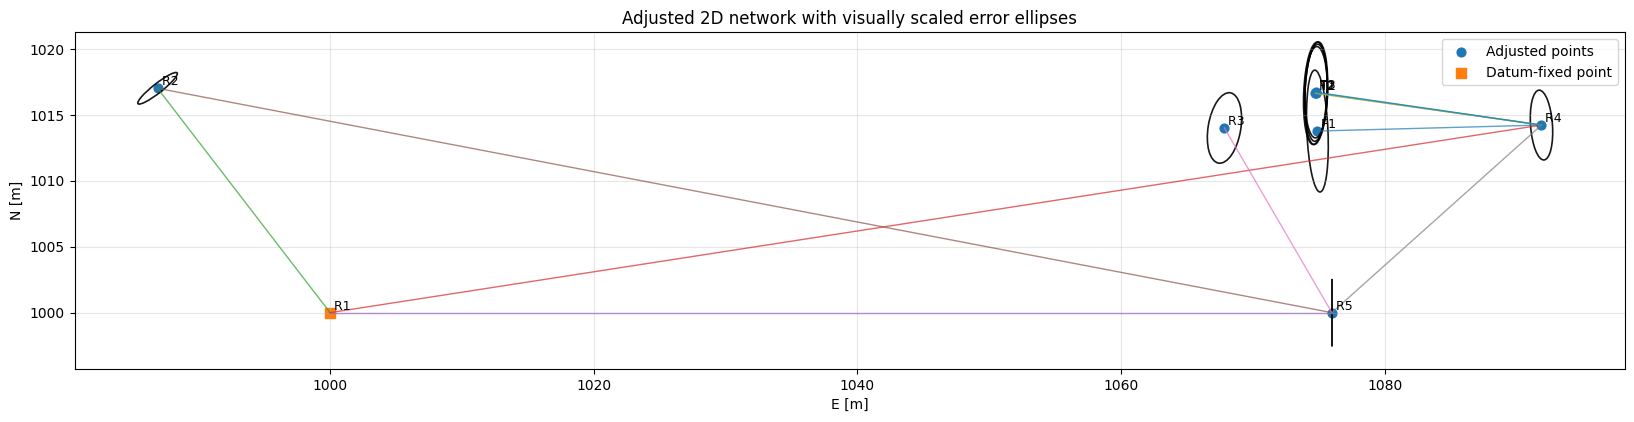

Ellipse sigma level: 1.000
Visual ellipse scale factor: 7020.976x


In [ ]:
# === Optional 2D Step 5 — Plot adjusted 2D network with error ellipses ===
# Requires:
# - adjustment_results_xy["coords_xy_final"]
# - point_precision_xy
# - obs_xy (for network edges)
#
# Plots:
# - adjusted 2D network
# - point labels
# - 1-sigma error ellipses, visually scaled for readability

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

if "adjustment_results_xy" not in globals():
    raise RuntimeError("adjustment_results_xy was not found. Run Optional 2D Step 3 first.")

if "point_precision_xy" not in globals():
    raise RuntimeError("point_precision_xy was not found. Run Optional 2D Step 4 first.")

if "obs_xy" not in globals():
    raise RuntimeError("obs_xy was not found.")

coords_xy_final = adjustment_results_xy["coords_xy_final"].copy()
coords_xy_final["benchmark"] = coords_xy_final["benchmark"].astype(str).str.strip()

pp = point_precision_xy.copy()
pp["benchmark"] = pp["benchmark"].astype(str).str.strip()

obs_plot = obs_xy.copy()
obs_plot["from"] = obs_plot["from"].astype(str).str.strip()
obs_plot["to"]   = obs_plot["to"].astype(str).str.strip()

# ------------------------------------------------------------
# User plot settings
# ------------------------------------------------------------
ellipse_sigma_level = 1.0          # 1.0 -> 1σ ellipses
ellipse_target_fraction = 0.2     # target median visible major axis as fraction of median edge length
label_fontsize = 9
point_size_fixed = 55
point_size_free = 40
show_edge_labels = False

# ------------------------------------------------------------
# Build coordinate lookup
# ------------------------------------------------------------
coord_lookup = (
    coords_xy_final[["benchmark", "N_m", "E_m", "is_fixed_xy"]]
    .drop_duplicates(subset=["benchmark"])
    .set_index("benchmark")
)

# ------------------------------------------------------------
# Build unique undirected edges from observations
# ------------------------------------------------------------
obs_plot["p_min"] = obs_plot[["from", "to"]].min(axis=1)
obs_plot["p_max"] = obs_plot[["from", "to"]].max(axis=1)

edges_df = (
    obs_plot.groupby(["p_min", "p_max"], as_index=False)
    .size()
    .rename(columns={"size": "n_obs"})
    .sort_values(["p_min", "p_max"])
    .reset_index(drop=True)
)

# Keep only edges whose endpoints exist in final coordinates
edges_df = edges_df[
    edges_df["p_min"].isin(coord_lookup.index) &
    edges_df["p_max"].isin(coord_lookup.index)
].copy()

# ------------------------------------------------------------
# Auto-scale ellipses for visibility
# ------------------------------------------------------------
edge_lengths = []
for _, r in edges_df.iterrows():
    a = str(r["p_min"]).strip()
    b = str(r["p_max"]).strip()
    Na, Ea = float(coord_lookup.loc[a, "N_m"]), float(coord_lookup.loc[a, "E_m"])
    Nb, Eb = float(coord_lookup.loc[b, "N_m"]), float(coord_lookup.loc[b, "E_m"])
    edge_lengths.append(float(np.hypot(Nb - Na, Eb - Ea)))

edge_lengths = np.asarray(edge_lengths, dtype=float)
edge_lengths = edge_lengths[np.isfinite(edge_lengths) & (edge_lengths > 0)]

median_edge_length = float(np.median(edge_lengths)) if len(edge_lengths) else 1.0

ellipse_a_vals = pd.to_numeric(pp["ellipse_a_1sigma_m"], errors="coerce").values.astype(float)
ellipse_a_vals = ellipse_a_vals[np.isfinite(ellipse_a_vals) & (ellipse_a_vals > 0)]

if len(ellipse_a_vals) == 0:
    ellipse_plot_scale = 1.0
else:
    median_a = float(np.median(ellipse_a_vals))
    if median_a <= 0:
        ellipse_plot_scale = 1.0
    else:
        ellipse_plot_scale = (ellipse_target_fraction * median_edge_length) / (ellipse_sigma_level * median_a)

# Clamp to a sane range
ellipse_plot_scale = float(np.clip(ellipse_plot_scale, 1.0, 1e6))

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(20, 20))

# Draw edges
for _, r in edges_df.iterrows():
    a = str(r["p_min"]).strip()
    b = str(r["p_max"]).strip()

    Na, Ea = float(coord_lookup.loc[a, "N_m"]), float(coord_lookup.loc[a, "E_m"])
    Nb, Eb = float(coord_lookup.loc[b, "N_m"]), float(coord_lookup.loc[b, "E_m"])

    ax.plot([Ea, Eb], [Na, Nb], linewidth=1.0, alpha=0.7)

    if show_edge_labels:
        Em = 0.5 * (Ea + Eb)
        Nm = 0.5 * (Na + Nb)
        ax.text(Em, Nm, f"{a}-{b}", fontsize=7, ha="center", va="center")

# Draw points
fixed_mask = coords_xy_final["is_fixed_xy"].fillna(False).astype(bool)
free_mask = ~fixed_mask

ax.scatter(
    coords_xy_final.loc[free_mask, "E_m"],
    coords_xy_final.loc[free_mask, "N_m"],
    s=point_size_free,
    label="Adjusted points"
)

ax.scatter(
    coords_xy_final.loc[fixed_mask, "E_m"],
    coords_xy_final.loc[fixed_mask, "N_m"],
    s=point_size_fixed,
    marker="s",
    label="Datum-fixed point"
)

# Point labels
for _, r in coords_xy_final.iterrows():
    p = str(r["benchmark"]).strip()
    Np = float(r["N_m"])
    Ep = float(r["E_m"])
    ax.text(Ep, Np, f" {p}", fontsize=label_fontsize, ha="left", va="bottom")

# Draw error ellipses
for _, r in pp.iterrows():
    p = str(r["benchmark"]).strip()

    if p not in coord_lookup.index:
        continue

    if bool(coord_lookup.loc[p, "is_fixed_xy"]):
        continue

    a = pd.to_numeric(pd.Series([r["ellipse_a_1sigma_m"]]), errors="coerce").iloc[0]
    b = pd.to_numeric(pd.Series([r["ellipse_b_1sigma_m"]]), errors="coerce").iloc[0]
    az_deg = pd.to_numeric(pd.Series([r["ellipse_azimuth_deg"]]), errors="coerce").iloc[0]

    if not np.isfinite(a) or not np.isfinite(b) or not np.isfinite(az_deg):
        continue
    if a <= 0 or b < 0:
        continue

    Np = float(coord_lookup.loc[p, "N_m"])
    Ep = float(coord_lookup.loc[p, "E_m"])

    # Matplotlib Ellipse angle is counterclockwise from +x axis (East).
    # Our azimuth is clockwise from North.
    theta_plot_deg = 90.0 - float(az_deg)

    ell = Ellipse(
        xy=(Ep, Np),
        width=2.0 * ellipse_sigma_level * b * ellipse_plot_scale,
        height=2.0 * ellipse_sigma_level * a * ellipse_plot_scale,
        angle=theta_plot_deg,
        fill=False,
        linewidth=1.2,
        alpha=0.9
    )
    ax.add_patch(ell)

# Cosmetics
ax.set_xlabel("E [m]")
ax.set_ylabel("N [m]")
ax.set_title("Adjusted 2D network with visually scaled error ellipses")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")

# Expand limits slightly
all_E = coords_xy_final["E_m"].astype(float).values
all_N = coords_xy_final["N_m"].astype(float).values

if len(all_E) and len(all_N):
    Emin, Emax = np.min(all_E), np.max(all_E)
    Nmin, Nmax = np.min(all_N), np.max(all_N)

    span_E = max(Emax - Emin, 1.0)
    span_N = max(Nmax - Nmin, 1.0)
    pad_E = 0.06 * span_E
    pad_N = 0.25 * span_N

    ax.set_xlim(Emin - pad_E, Emax + pad_E)
    ax.set_ylim(Nmin - pad_N, Nmax + pad_N)

plt.show()

print(f"Ellipse sigma level: {ellipse_sigma_level:.3f}")
print(f"Visual ellipse scale factor: {ellipse_plot_scale:.3f}x")

## Optional 2D Step 5A — Focused local plot with error ellipses

This cell creates a focused 2D plot for a selected local cluster of points.

**Main role**
- isolate the selected benchmarks,
- plot only the local subgroup,
- display their error ellipses with a scale suitable for the local extent.

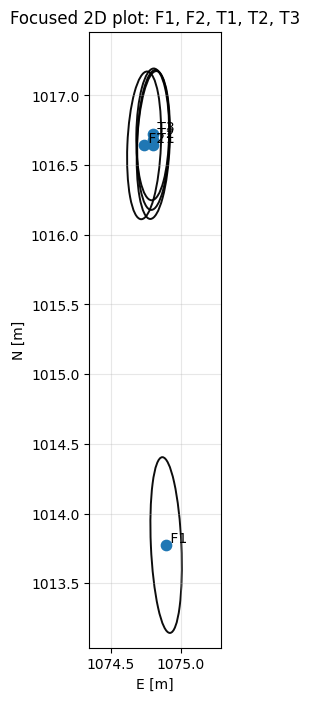

Focused ellipse sigma level: 1.000
Focused visual ellipse scale factor: 957.899x


In [ ]:
# === Optional 2D Step 5A — Focused plot on F1, F2, T1, T2, T3 with error ellipses ===
# Requires:
# - adjustment_results_xy["coords_xy_final"]
# - point_precision_xy
#
# Plots:
# - focused 2D view for selected points
# - 1-sigma error ellipses with independent visual scaling for this local cluster

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

if "adjustment_results_xy" not in globals():
    raise RuntimeError("adjustment_results_xy was not found. Run Optional 2D Step 3 first.")

if "point_precision_xy" not in globals():
    raise RuntimeError("point_precision_xy was not found. Run Optional 2D Step 4 first.")

coords_xy_final = adjustment_results_xy["coords_xy_final"].copy()
coords_xy_final["benchmark"] = coords_xy_final["benchmark"].astype(str).str.strip()

pp = point_precision_xy.copy()
pp["benchmark"] = pp["benchmark"].astype(str).str.strip()

# ------------------------------------------------------------
# User settings
# ------------------------------------------------------------
focus_points = ["F1", "F2", "T1", "T2", "T3"]
ellipse_sigma_level = 1.0
ellipse_target_fraction = 0.18   # larger local visibility than the full-network plot
label_fontsize = 10
point_size = 55

# ------------------------------------------------------------
# Filter to focus points
# ------------------------------------------------------------
focus_df = coords_xy_final[coords_xy_final["benchmark"].isin(focus_points)].copy()
if focus_df.empty:
    raise RuntimeError("None of the requested focus points were found in coords_xy_final.")

pp_focus = pp[pp["benchmark"].isin(focus_points)].copy()

coord_lookup = (
    focus_df[["benchmark", "N_m", "E_m", "is_fixed_xy"]]
    .drop_duplicates(subset=["benchmark"])
    .set_index("benchmark")
)

# ------------------------------------------------------------
# Local ellipse scaling
# ------------------------------------------------------------
# use local spread of focused points as the scale reference
all_E = focus_df["E_m"].astype(float).values
all_N = focus_df["N_m"].astype(float).values

span_E = max(float(np.max(all_E) - np.min(all_E)), 1e-6)
span_N = max(float(np.max(all_N) - np.min(all_N)), 1e-6)
local_span = max(span_E, span_N)

ellipse_a_vals = pd.to_numeric(pp_focus["ellipse_a_1sigma_m"], errors="coerce").values.astype(float)
ellipse_a_vals = ellipse_a_vals[np.isfinite(ellipse_a_vals) & (ellipse_a_vals > 0)]

if len(ellipse_a_vals) == 0:
    ellipse_plot_scale = 1.0
else:
    median_a = float(np.median(ellipse_a_vals))
    if median_a <= 0:
        ellipse_plot_scale = 1.0
    else:
        ellipse_plot_scale = (ellipse_target_fraction * local_span) / (ellipse_sigma_level * median_a)

ellipse_plot_scale = float(np.clip(ellipse_plot_scale, 1.0, 1e7))

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    focus_df["E_m"].astype(float),
    focus_df["N_m"].astype(float),
    s=point_size,
)

for _, r in focus_df.iterrows():
    p = str(r["benchmark"]).strip()
    Np = float(r["N_m"])
    Ep = float(r["E_m"])
    ax.text(Ep, Np, f" {p}", fontsize=label_fontsize, ha="left", va="bottom")

# Draw ellipses
for _, r in pp_focus.iterrows():
    p = str(r["benchmark"]).strip()
    if p not in coord_lookup.index:
        continue

    a = pd.to_numeric(pd.Series([r["ellipse_a_1sigma_m"]]), errors="coerce").iloc[0]
    b = pd.to_numeric(pd.Series([r["ellipse_b_1sigma_m"]]), errors="coerce").iloc[0]
    az_deg = pd.to_numeric(pd.Series([r["ellipse_azimuth_deg"]]), errors="coerce").iloc[0]

    if not np.isfinite(a) or not np.isfinite(b) or not np.isfinite(az_deg):
        continue
    if a <= 0 or b < 0:
        continue

    Np = float(coord_lookup.loc[p, "N_m"])
    Ep = float(coord_lookup.loc[p, "E_m"])

    theta_plot_deg = 90.0 - float(az_deg)

    ell = Ellipse(
        xy=(Ep, Np),
        width=2.0 * ellipse_sigma_level * b * ellipse_plot_scale,
        height=2.0 * ellipse_sigma_level * a * ellipse_plot_scale,
        angle=theta_plot_deg,
        fill=False,
        linewidth=1.4,
        alpha=0.95
    )
    ax.add_patch(ell)

ax.set_xlabel("E [m]")
ax.set_ylabel("N [m]")
ax.set_title("Focused 2D plot: F1, F2, T1, T2, T3")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.3)

# tight local limits with small padding
Emin, Emax = float(np.min(all_E)), float(np.max(all_E))
Nmin, Nmax = float(np.min(all_N)), float(np.max(all_N))

pad_E = max(2.5 * (Emax - Emin), 0.02)
pad_N = max(0.25 * (Nmax - Nmin), 0.02)

ax.set_xlim(Emin - pad_E, Emax + pad_E)
ax.set_ylim(Nmin - pad_N, Nmax + pad_N)

plt.show()

print(f"Focused ellipse sigma level: {ellipse_sigma_level:.3f}")
print(f"Focused visual ellipse scale factor: {ellipse_plot_scale:.3f}x")

## Optional 2D Step 6 — Georeference the local adjusted network

This cell links the adjusted local 2D network to a real projected coordinate reference system.

**Main role**
- accept control points in projected or geographic form,
- define a working metric CRS,
- estimate the transformation from the local system to the working CRS,
- compute georeferenced coordinates for the adjusted points.

In [ ]:
# === Optional 2D Step 6 — Georeference local adjusted network to a real metric CRS ===
# Requires:
# - adjustment_results_xy["coords_xy_final"]
# - xy_datum_definition
#
# What this cell does:
# - source = local independent system (coords_xy_final)
# - controls can be given either as:
#     1) projected coordinates in a metric working CRS
#     2) lon/lat in EPSG:4326
# - internal working CRS = user-selected METRIC projected CRS
# - transform type:
#     * rigid_2d      = shift + rotation
#     * similarity_2d = shift + rotation + scale
#
# Control points used:
# - anchor point       = xy_datum_definition["anchor_point"]
# - orientation point  = xy_datum_definition["orientation_point"]
#
# Outputs:
# - coords_xy_georef in the working projected CRS
# - lon/lat in EPSG:4326
# - georeferencing summary and control-point check

import numpy as np
import pandas as pd
from pyproj import CRS, Transformer

if "adjustment_results_xy" not in globals():
    raise RuntimeError("adjustment_results_xy was not found. Run Optional 2D Step 3 first.")

if "xy_datum_definition" not in globals():
    raise RuntimeError("xy_datum_definition was not found. Run Optional 2D Step 2 first.")

if "coords_xy_final" not in adjustment_results_xy:
    raise RuntimeError("adjustment_results_xy does not contain 'coords_xy_final'.")

coords_xy_final = adjustment_results_xy["coords_xy_final"].copy()
coords_xy_final["benchmark"] = coords_xy_final["benchmark"].astype(str).str.strip()

anchor = str(xy_datum_definition["anchor_point"]).strip()
orient_pt = str(xy_datum_definition["orientation_point"]).strip()

if anchor not in coords_xy_final["benchmark"].values:
    raise RuntimeError(f"Anchor point '{anchor}' not found in coords_xy_final.")
if orient_pt not in coords_xy_final["benchmark"].values:
    raise RuntimeError(f"Orientation point '{orient_pt}' not found in coords_xy_final.")
if anchor == orient_pt:
    raise RuntimeError("Anchor point and orientation point must be different.")

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _gon_to_rad(g):
    return np.asarray(g, dtype=float) * np.pi / 200.0

def _rad_to_gon(r):
    return np.asarray(r, dtype=float) * 200.0 / np.pi

def _wrap_gon_0_400(g):
    g = np.asarray(g, dtype=float)
    return np.mod(g, 400.0)

def _azimuth_from_dNE(dN, dE):
    # 0 gon = North, 100 gon = East
    return float(_wrap_gon_0_400(_rad_to_gon(np.arctan2(dE, dN))))

def _rotate_dNE(dN, dE, delta_gon):
    # positive rotation in the local N/E frame
    a = float(_gon_to_rad(delta_gon))
    dN_rot = dN * np.cos(a) - dE * np.sin(a)
    dE_rot = dN * np.sin(a) + dE * np.cos(a)
    return dN_rot, dE_rot

# ------------------------------------------------------------
# Input section
# ------------------------------------------------------------
print("Working CRS for georeferencing (must be a METRIC projected CRS).")
print("Examples: 2100 for EGSA87, 32634 for UTM zone 34N, 32635 for UTM zone 35N")
working_epsg = int(input("Enter working projected EPSG: ").strip())

working_crs = CRS.from_epsg(working_epsg)
if not working_crs.is_projected:
    raise ValueError(f"EPSG:{working_epsg} is not projected. Use a metric projected CRS.")

print("\nControl-coordinate input mode:")
print("  1 -> coordinates already given in the working projected CRS")
print("  2 -> lon/lat given in EPSG:4326, transformed internally to the working projected CRS")
input_mode = input("Choose input mode [1/2]: ").strip()
if input_mode not in ["1", "2"]:
    raise ValueError("Input mode must be '1' or '2'.")

print("\nTransform type:")
print("  1 -> rigid_2d      (shift + rotation)")
print("  2 -> similarity_2d (shift + rotation + scale)")
transform_mode = input("Choose transform type [1/2]: ").strip()
if transform_mode not in ["1", "2"]:
    raise ValueError("Transform type must be '1' or '2'.")

transform_type = "rigid_2d" if transform_mode == "1" else "similarity_2d"

print(f"\nAnchor point: {anchor}")
print(f"Orientation point: {orient_pt}")

if input_mode == "1":
    anchor_E_proj = float(input(f"Enter real/projected E/X of '{anchor}' in EPSG:{working_epsg}: ").strip().replace(",", "."))
    anchor_N_proj = float(input(f"Enter real/projected N/Y of '{anchor}' in EPSG:{working_epsg}: ").strip().replace(",", "."))
    orient_E_proj = float(input(f"Enter real or approximate E/X of '{orient_pt}' in EPSG:{working_epsg}: ").strip().replace(",", "."))
    orient_N_proj = float(input(f"Enter real or approximate N/Y of '{orient_pt}' in EPSG:{working_epsg}: ").strip().replace(",", "."))

else:
    anchor_lon = float(input(f"Enter longitude of '{anchor}' [deg, EPSG:4326]: ").strip().replace(",", "."))
    anchor_lat = float(input(f"Enter latitude  of '{anchor}' [deg, EPSG:4326]: ").strip().replace(",", "."))
    orient_lon = float(input(f"Enter longitude of '{orient_pt}' [deg, EPSG:4326]: ").strip().replace(",", "."))
    orient_lat = float(input(f"Enter latitude  of '{orient_pt}' [deg, EPSG:4326]: ").strip().replace(",", "."))

    tr_4326_to_work = Transformer.from_crs(CRS.from_epsg(4326), working_crs, always_xy=True)
    anchor_E_proj, anchor_N_proj = tr_4326_to_work.transform(anchor_lon, anchor_lat)
    orient_E_proj, orient_N_proj = tr_4326_to_work.transform(orient_lon, orient_lat)

# ------------------------------------------------------------
# Local control geometry
# ------------------------------------------------------------
coord_lookup = coords_xy_final.set_index("benchmark")[["N_m", "E_m"]]

anchor_N_local = float(coord_lookup.loc[anchor, "N_m"])
anchor_E_local = float(coord_lookup.loc[anchor, "E_m"])
orient_N_local = float(coord_lookup.loc[orient_pt, "N_m"])
orient_E_local = float(coord_lookup.loc[orient_pt, "E_m"])

dN_local = orient_N_local - anchor_N_local
dE_local = orient_E_local - anchor_E_local
len_local = float(np.hypot(dN_local, dE_local))

dN_proj = float(orient_N_proj - anchor_N_proj)
dE_proj = float(orient_E_proj - anchor_E_proj)
len_proj = float(np.hypot(dN_proj, dE_proj))

if len_local <= 1e-12:
    raise RuntimeError("Local anchor-orientation geometry is degenerate.")
if len_proj <= 1e-12:
    raise RuntimeError("Projected anchor-orientation geometry is degenerate.")

az_local_gon = _azimuth_from_dNE(dN_local, dE_local)
az_proj_gon = _azimuth_from_dNE(dN_proj, dE_proj)
delta_gon = float(_wrap_gon_0_400(az_proj_gon - az_local_gon))

if transform_type == "rigid_2d":
    scale_factor = 1.0
else:
    scale_factor = float(len_proj / len_local)

# ------------------------------------------------------------
# Transform all points: local -> working projected CRS
# ------------------------------------------------------------
rows = []
for _, r in coords_xy_final.iterrows():
    p = str(r["benchmark"]).strip()

    Nloc = float(r["N_m"])
    Eloc = float(r["E_m"])

    dN = Nloc - anchor_N_local
    dE = Eloc - anchor_E_local

    dN_rot, dE_rot = _rotate_dNE(dN, dE, delta_gon)

    dN_fin = scale_factor * dN_rot
    dE_fin = scale_factor * dE_rot

    N_proj = float(anchor_N_proj + dN_fin)
    E_proj = float(anchor_E_proj + dE_fin)

    rows.append({
        "benchmark": p,
        "N_local_m": Nloc,
        "E_local_m": Eloc,
        "N_geo": N_proj,
        "E_geo": E_proj,
        "is_fixed_xy": bool(r.get("is_fixed_xy", False)),
        "component_id": r.get("component_id", np.nan),
    })

coords_xy_georef = pd.DataFrame(rows)

# ------------------------------------------------------------
# lon/lat output in EPSG:4326
# ------------------------------------------------------------
tr_work_to_4326 = Transformer.from_crs(working_crs, CRS.from_epsg(4326), always_xy=True)
lon_vals, lat_vals = tr_work_to_4326.transform(
    coords_xy_georef["E_geo"].astype(float).values,
    coords_xy_georef["N_geo"].astype(float).values
)
coords_xy_georef["lon_deg"] = lon_vals
coords_xy_georef["lat_deg"] = lat_vals

# ------------------------------------------------------------
# Control-point check
# ------------------------------------------------------------
geo_lookup = coords_xy_georef.set_index("benchmark")[["N_geo", "E_geo"]]

anchor_N_chk = float(geo_lookup.loc[anchor, "N_geo"])
anchor_E_chk = float(geo_lookup.loc[anchor, "E_geo"])
orient_N_chk = float(geo_lookup.loc[orient_pt, "N_geo"])
orient_E_chk = float(geo_lookup.loc[orient_pt, "E_geo"])

anchor_offset_m = float(np.hypot(anchor_N_chk - anchor_N_proj, anchor_E_chk - anchor_E_proj))
orient_offset_m = float(np.hypot(orient_N_chk - orient_N_proj, orient_E_chk - orient_E_proj))

check_df = pd.DataFrame([
    {
        "point": anchor,
        "given_E_proj": float(anchor_E_proj),
        "given_N_proj": float(anchor_N_proj),
        "transformed_E_proj": float(anchor_E_chk),
        "transformed_N_proj": float(anchor_N_chk),
        "offset_m": anchor_offset_m,
    },
    {
        "point": orient_pt,
        "given_E_proj": float(orient_E_proj),
        "given_N_proj": float(orient_N_proj),
        "transformed_E_proj": float(orient_E_chk),
        "transformed_N_proj": float(orient_N_chk),
        "offset_m": orient_offset_m,
    },
])

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
georef_definition_xy = {
    "working_epsg": int(working_epsg),
    "input_mode": input_mode,
    "transform_type": transform_type,
    "anchor_point": anchor,
    "orientation_point": orient_pt,
    "anchor_proj_E": float(anchor_E_proj),
    "anchor_proj_N": float(anchor_N_proj),
    "orientation_proj_E": float(orient_E_proj),
    "orientation_proj_N": float(orient_N_proj),
    "local_azimuth_gon": float(az_local_gon),
    "projected_azimuth_gon": float(az_proj_gon),
    "applied_rotation_gon": float(delta_gon),
    "scale_factor": float(scale_factor),
    "anchor_offset_m": float(anchor_offset_m),
    "orientation_offset_m": float(orient_offset_m),
}

georef_results_xy = {
    "coords_xy_georef": coords_xy_georef,
    "georef_definition_xy": georef_definition_xy,
    "control_check_xy": check_df,
}

print("\nGeoreference definition summary:")
print(georef_definition_xy)

print("\nControl-point check:")
display(check_df)

print("\nGeoreferenced network coordinates:")

coords_xy_georef_display = coords_xy_georef.sort_values("benchmark").reset_index(drop=True).copy()

display(
    coords_xy_georef_display.style.format({
        "N_local_m": "{:.6f}",
        "E_local_m": "{:.6f}",
        "N_geo": "{:.6f}",
        "E_geo": "{:.6f}",
        "lon_deg": "{:.8f}",
        "lat_deg": "{:.8f}",
    })
)

print("\nSaved georeferenced results in dict: georef_results_xy")

Working CRS for georeferencing (must be a METRIC projected CRS).
Examples: 2100 for EGSA87, 32634 for UTM zone 34N, 32635 for UTM zone 35N
Enter working projected EPSG: 32635 

Control-coordinate input mode:
  1 -> coordinates already given in the working projected CRS
  2 -> lon/lat given in EPSG:4326, transformed internally to the working projected CRS
Choose input mode [1/2]: 2

Transform type:
  1 -> rigid_2d      (shift + rotation)
  2 -> similarity_2d (shift + rotation + scale)
Choose transform type [1/2]: 1

Anchor point: R1
Orientation point: R5
Enter longitude of 'R1' [deg, EPSG:4326]: 26.3401850972222
Enter latitude  of 'R1' [deg, EPSG:4326]: 36.573769675
Enter longitude of 'R5' [deg, EPSG:4326]: 26.3407949166667
Enter latitude  of 'R5' [deg, EPSG:4326]: 36.5732932444445

Georeference definition summary:
{'working_epsg': 32635, 'input_mode': '2', 'transform_type': 'rigid_2d', 'anchor_point': 'R1', 'orientation_point': 'R5', 'anchor_proj_E': 440965.8211836971, 'anchor_proj_N':

,point,given_E_proj,given_N_proj,transformed_E_proj,transformed_N_proj,offset_m
0,R1,440965.821184,4.047794e+06,440965.821184,4.047794e+06,0.000000
1,R5,441020.020610,4.047740e+06,441020.042639,4.047740e+06,0.030875



Georeferenced network coordinates:


,benchmark,N_local_m,E_local_m,N_geo,E_geo,is_fixed_xy,component_id,lon_deg,lat_deg
0,F1,1013.773786,1074.895956,4047750.852731,441028.910222,False,1,26.34089346,36.57338912
1,F2,1016.641614,1074.738136,4047753.009509,441030.806972,False,1,26.34091449,36.57340868
2,R1,1000.000000,1000.000000,4047793.501231,440965.821184,True,1,26.34018510,36.57376967
3,R2,1017.018279,986.912807,4047814.813390,440968.407368,False,1,26.34021237,36.57396195
4,R3,1014.009324,1067.845812,4047755.960497,441024.044964,False,1,26.34083869,36.57343486
5,R4,1014.229961,1091.895909,4047739.267135,441041.359338,False,1,26.34103348,36.57328545
6,R5,1000.000000,1075.993457,4047740.256144,441020.042639,False,1,26.34079516,36.57329305
7,T1,1016.644075,1074.803977,4047752.965132,441030.855674,False,1,26.34091504,36.57340828
8,T2,1016.680563,1074.804467,4047752.990823,441030.881589,False,1,26.34091533,36.57340852
9,T3,1016.720307,1074.799627,4047753.022572,441030.905983,False,1,26.34091560,36.57340880



Saved georeferenced results in dict: georef_results_xy


## Optional 2D Step 7 — Plot selected georeferenced points on satellite imagery

This final cell produces a map of selected georeferenced points over high-resolution satellite imagery.

**Main role**
- read the georeferenced point dataframe,
- ask the user to upload a text file containing the Google Map Tiles API key,
- request a valid Google tiles session,
- ask which benchmarks should be plotted,
- display only the selected points over satellite tiles.

Upload ONE .txt file that contains only the Google Map Tiles API key.


Saving Google_Maps_API_key.txt to Google_Maps_API_key (2).txt

Available benchmarks:
F1, F2, R1, R2, R3, R4, R5, T1, T2, T3

Enter benchmark names separated by commas, or type ALL: R1,R2,R3,R4,R5,T2


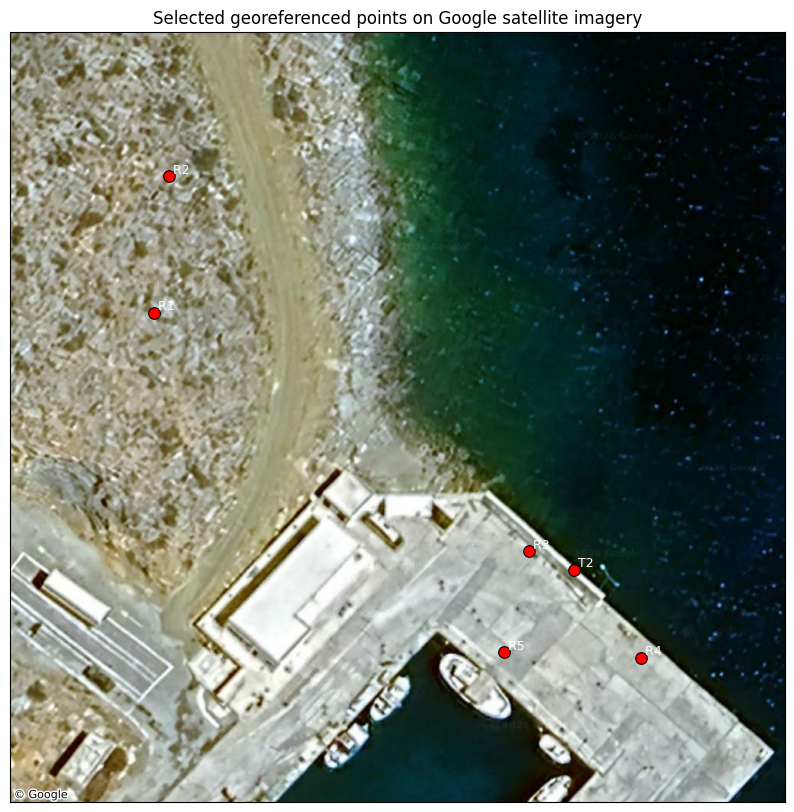

Working projected CRS EPSG: 32635
Selected benchmarks: R1, R2, R3, R4, R5, T2
Google session token acquired successfully.


In [ ]:
# === Optional 2D Step 7 — Plot selected georeferenced points on Google satellite tiles ===
# Requires:
# - georef_results_xy["coords_xy_georef"]
# - georef_results_xy["georef_definition_xy"]
#
# This cell:
# - asks the user to upload a .txt file containing the Google Map Tiles API key
# - requests a Google Map Tiles API session token
# - asks which benchmark points to plot
# - plots ONLY the selected points
# - uses Google satellite imagery as background

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyproj import CRS, Transformer
import requests

try:
    import contextily as ctx
except ImportError:
    raise ImportError(
        "The package 'contextily' is not installed.\n"
        "Run in a previous cell:\n"
        "!pip install contextily"
    )

try:
    from google.colab import files
except ImportError:
    raise ImportError("This cell is intended for Google Colab.")

if "georef_results_xy" not in globals():
    raise RuntimeError("georef_results_xy was not found. Run Optional 2D Step 6 first.")

if "coords_xy_georef" not in georef_results_xy or "georef_definition_xy" not in georef_results_xy:
    raise RuntimeError("georef_results_xy does not contain 'coords_xy_georef' and/or 'georef_definition_xy'.")

coords_xy_georef = georef_results_xy["coords_xy_georef"].copy()
georef_definition_xy = georef_results_xy["georef_definition_xy"]

coords_xy_georef["benchmark"] = coords_xy_georef["benchmark"].astype(str).str.strip()

required_cols = ["benchmark", "E_geo", "N_geo"]
for col in required_cols:
    if col not in coords_xy_georef.columns:
        raise RuntimeError(f"Column '{col}' not found in coords_xy_georef.")

working_epsg = int(georef_definition_xy["working_epsg"])

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
margin_frac = 0.10
min_window_m = 300.0

point_size = 70
label_fontsize = 9
draw_labels = True

google_zoom = 20   # fixed zoom level for local high-resolution view

# ------------------------------------------------------------
# Ask user to upload .txt file containing the API key
# ------------------------------------------------------------
print("Upload ONE .txt file that contains only the Google Map Tiles API key.")
uploaded = files.upload()

if len(uploaded) != 1:
    raise RuntimeError("You must upload exactly one .txt file.")

uploaded_name = next(iter(uploaded.keys()))
if not uploaded_name.lower().endswith(".txt"):
    raise RuntimeError("The uploaded file must be a .txt file.")

api_key = uploaded[uploaded_name].decode("utf-8").strip()

if api_key == "":
    raise RuntimeError("The uploaded .txt file is empty.")

# ------------------------------------------------------------
# Request Google Map Tiles session token
# ------------------------------------------------------------
session_url = "https://tile.googleapis.com/v1/createSession"
session_params = {"key": api_key}
session_body = {
    "mapType": "satellite",
    "language": "en-US",
    "region": "GR"
}

resp = requests.post(
    session_url,
    params=session_params,
    json=session_body,
    headers={"Content-Type": "application/json"},
    timeout=30
)

if resp.status_code != 200:
    raise RuntimeError(
        f"Google createSession failed.\n"
        f"HTTP {resp.status_code}\n"
        f"Response: {resp.text}"
    )

session_data = resp.json()

if "session" not in session_data:
    raise RuntimeError(f"Session token not found in response: {session_data}")

google_session_token = session_data["session"]

# ------------------------------------------------------------
# Transform georeferenced projected coordinates:
# working CRS -> lon/lat -> Web Mercator (EPSG:3857)
# ------------------------------------------------------------
tr_work_to_4326 = Transformer.from_crs(
    CRS.from_epsg(working_epsg),
    CRS.from_epsg(4326),
    always_xy=True
)

lon_vals, lat_vals = tr_work_to_4326.transform(
    coords_xy_georef["E_geo"].astype(float).values,
    coords_xy_georef["N_geo"].astype(float).values
)

coords_plot = coords_xy_georef.copy()
coords_plot["lon_deg"] = lon_vals
coords_plot["lat_deg"] = lat_vals

tr_4326_to_3857 = Transformer.from_crs(
    CRS.from_epsg(4326),
    CRS.from_epsg(3857),
    always_xy=True
)

x_3857, y_3857 = tr_4326_to_3857.transform(
    coords_plot["lon_deg"].astype(float).values,
    coords_plot["lat_deg"].astype(float).values
)

coords_plot["x_3857"] = x_3857
coords_plot["y_3857"] = y_3857

# ------------------------------------------------------------
# Ask user which points to plot
# ------------------------------------------------------------
available_points = coords_plot["benchmark"].drop_duplicates().sort_values().tolist()

print("\nAvailable benchmarks:")
print(", ".join(available_points))

user_input = input(
    "\nEnter benchmark names separated by commas, or type ALL: "
).strip()

if user_input == "":
    raise RuntimeError("No input was given.")

if user_input.upper() == "ALL":
    selected_points = available_points
else:
    selected_points = [p.strip() for p in user_input.split(",") if p.strip() != ""]
    invalid_points = [p for p in selected_points if p not in available_points]
    if invalid_points:
        raise RuntimeError(
            "The following benchmark(s) were not found: " + ", ".join(invalid_points)
        )

coords_sel = (
    coords_plot[coords_plot["benchmark"].isin(selected_points)]
    .drop_duplicates(subset=["benchmark"])
    .copy()
)

if coords_sel.empty:
    raise RuntimeError("No valid points selected for plotting.")

# ------------------------------------------------------------
# Map extent from selected points only
# ------------------------------------------------------------
x_min = float(coords_sel["x_3857"].min())
x_max = float(coords_sel["x_3857"].max())
y_min = float(coords_sel["y_3857"].min())
y_max = float(coords_sel["y_3857"].max())

span_x = max(x_max - x_min, 1e-6)
span_y = max(y_max - y_min, 1e-6)

pad_x = margin_frac * span_x
pad_y = margin_frac * span_y

xmin = x_min - pad_x
xmax = x_max + pad_x
ymin = y_min - pad_y
ymax = y_max + pad_y

if (xmax - xmin) < min_window_m:
    cx = 0.5 * (xmin + xmax)
    xmin = cx - 0.25 * min_window_m
    xmax = cx + 0.25 * min_window_m

if (ymax - ymin) < min_window_m:
    cy = 0.5 * (ymin + ymax)
    ymin = cy - 0.25 * min_window_m
    ymax = cy + 0.25 * min_window_m

# ------------------------------------------------------------
# Google tile URL template
# ------------------------------------------------------------
google_tile_url = (
    f"https://tile.googleapis.com/v1/2dtiles/{{z}}/{{x}}/{{y}}"
    f"?session={google_session_token}&key={api_key}"
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(
    coords_sel["x_3857"],
    coords_sel["y_3857"],
    s=point_size,
    c="red",
    edgecolors="black",
    linewidths=0.8,
    zorder=5
)

if draw_labels:
    for _, r in coords_sel.iterrows():
        ax.text(
            float(r["x_3857"]),
            float(r["y_3857"]),
            f" {str(r['benchmark']).strip()}",
            fontsize=label_fontsize,
            ha="left",
            va="bottom",
            color="white",
            zorder=6
        )

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ctx.add_basemap(
    ax,
    source=google_tile_url,
    crs="EPSG:3857",
    attribution="© Google",
    zoom=google_zoom
)

ax.set_title("Selected georeferenced points on Google satellite imagery")
ax.set_xticks([])
ax.set_yticks([])

plt.show()

print(f"Working projected CRS EPSG: {working_epsg}")
print("Selected benchmarks:", ", ".join(coords_sel["benchmark"].tolist()))
print("Google session token acquired successfully.")

R1,R2,R3,R4,R5,T2